# Orbital Data Center: Levelized Cost of Compute (LCOC) Model — v3

**Project:** Feasibility study of whether passive radiative cooling and falling launch costs can make an Orbital Data Center (ODC) cost-competitive with a Terrestrial Data Center (TDC) for AI training workloads.

**Method:** First-principles sizing of PV array and radiator → mass and cost budget → LCOC via Nøland et al. (2024) Eq. 1.

**Model structure (v3, locked initial values):**
- **One** baseline ODC scenario in 2026 — all initial parameter values are now fixed at the spreadsheet values (no high/low scenarios on starting values).
- **One** terrestrial DC scenario for comparison (Nøland et al. baseline).
- **Uncertainty enters only through the learning rate** — three scenarios (Optimistic / Baseline / Pessimistic) that govern how fast each cost component declines (or how fast efficiencies grow). This produces the shaded uncertainty bands on time-series plots.

**Notebook outline:**
1. Constants and locked architectural assumptions
2. Baseline parameter tables (with sources)
3. Learning rate scenarios (lower bound / baseline / upper bound)
4. Physical sizing (PV, radiator, mass)
5. LCOC calculation at year 0 (2026)
6. Terrestrial DC baseline
7. Time projection 2026–2045 across learning rate scenarios
8. Visualizations (LCOC vs time, tornado, LCOC vs launch cost)
9. Summary

## 1. Constants and locked architectural assumptions

**Locked architecture (no variation across scenarios):**
- 100 MW compute payload, training workload, 100% utilization
- LEO at 2,000 km altitude — dawn-dusk, eclipse-free band; capacity factor CF = 0.9987 (residual ~11 h/yr lunar eclipse)
- 15-year ODC lifespan, 5-year IT refresh interval (refreshes at year 5 and year 10)
- PV and radiator are one-time launches at year 0 (no refresh)
- Single horizontal radiator beam, double-sided emission, co-located with vertical PV array at mid-height
- Triple-junction GaAs PV cells
- One fixed OPEX line = on-Earth operations labor ($3.75M/yr, identical for ODC and TDC); no structural mass overhead
- Cooling only the compute module (PV thermally isolated from radiator network)
- **Radiator operating temperature fixed at 70 °C (sensitivity 60–80 °C).** We treat `T_rad` as a *bounded design variable* rather than resolving the full junction-to-radiator thermal-resistance network (chip → TIM → cold plate → coolant → heat-pipe → panel → radiating surface). This follows Turyshev (2026), who operates the radiator at 350 K ≈ 77 °C and explicitly notes that `T_rad` is upper-bounded by the allowable junction temperature minus a thermal-resistance budget. A data-center accelerator junction of ~60–100 °C (Li 2024) carried through a realistic ~20 °C conduction+convection path drop places the radiating surface near 70 °C. The original 5 °C drop captured only the near-isothermal two-phase heat-pipe fluid ΔT, not the conduction/convection chain; fixing `T_rad` avoids introducing many poorly-constrained resistances for a subsystem worth ~0.1% of LCOC.
- **Thermally optimistic attitude:** the ODC orientation is chosen so the radiator panel is **edge-on to the Sun** (radiator surface normal ⟂ solar vector), giving direct solar projection onto the radiator ≈ 0 (Σcosθ ≈ 0). This is a best-case thermal assumption that maximizes net heat rejection per unit area.
- **PV cell temperature `T_PV` derived, not assumed:** a steady-state radiative energy balance on the cell (absorbed solar − extracted electrical power = two-face IR emission) gives `T_PV ≈ 31.1 °C` (see Section 2a). This replaces the legacy 80 °C placeholder.
- PV view factor `F_PV` computed self-consistently from geometry; both radiator faces see equal `F_PV` (mid-height symmetry)
- No radiator coating degradation (no UV / AO / dust accounting)
- No disposal / decommissioning costs
- No temperature gradient across the radiator (single `T_rad` everywhere)
- Data drop cost itself negligible

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import dataclass, replace
from typing import Dict, List
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ----- Physical constants ----------------------------------------------------
# Basic scientific constants cited to the same primary sources as Turyshev (2026).
SIGMA        = 5.67e-8            # Stefan-Boltzmann [W m^-2 K^-4] (CODATA)
I_SUN        = 1361              # Solar constant / TSI [W m^-2] -- Kopp & Lean (2011),
                                 #   Geophys. Res. Lett. 38, L01706 (Turyshev 2026 ref [15])
T_EARTH_EFF  = 254.15           # Earth effective radiating temp [K] (-19 C) -- NASA Earth Fact Sheet
EARTH_ALBEDO = 0.306            # Earth Bond albedo -- NASA Earth Fact Sheet

# ----- Architecture constants ------------------------------------------------
Q_COMPUTE          = 100e6                       # 100 MW compute heat load [W]
LIFETIME_YR        = 15
REFRESH_INTERVAL   = 5                           # IT refresh every 5 yrs
HOURS_PER_YEAR     = 8760
SECONDS_PER_YEAR   = HOURS_PER_YEAR * 3600
ORBITAL_ALT_KM     = 2_000                       # LEO upper edge [km] -- Starship-class LEO; sits just above
                                                 #   the dawn-dusk eclipse-free floor (~1,600 km). (Claudio's orbit/CF work)
CAPACITY_FACTOR    = 0.9987                       # eclipse-free dawn-dusk orbit; residual ~11 h/yr lunar-eclipse loss
ANNUAL_LABOR_COST  = 3.75e6                       # on-Earth ops workforce [$/yr]: ~25 FTE x $150k loaded.
                                                 #   Headcount per Uptime Institute 2024 Global Data Center Survey &
                                                 #   Staffing Forecast (~20 FTE/12 MW, ~45/40 MW; FEWER per-MW for a
                                                 #   highly-automated >100 MW hyperscale campus). $150k = loaded comp
                                                 #   (salary+benefits+overhead) for skilled DC technicians/engineers.
                                                 #   Applied IDENTICALLY to ODC and TDC (both run from a ground NOC).

## 2. Baseline ODC parameters (with sources)

All initial values are locked at the 2026 spreadsheet values. The "Learning" column indicates whether the parameter evolves over time under a learning rate (see Section 3) or stays constant for the full 15-year mission. **Source filenames refer to the `Literature 2/` folder.**

### 2a. Learning parameters (evolve year-over-year)

Only four parameters carry a learning rate. Radiator areal cost and IT cost are now held **constant** (no learning) — see Section 3 for the rationale (commodity-aluminum radiator; AI hardware $/MW is flat-to-rising and the compute-cost improvement is captured through γ, not through $/MW).

| Parameter | Symbol | Value (2026) | Units | Learning | Source (file) |
|---|---|---|---|---|---|
| Compute Efficiency | γ | **6.0** | PFLOPS/kW | ✓ | `Noland2024_AIBaseloadPowerDemand_IEEEAccess.pdf` |
| Launch Cost | — | **1,500** | $/kg | ✓ | `Roberts2022_SpaceLaunchCostToLEO_CSIS.pdf` (Falcon Heavy / Starship class) |
| PV BOL Efficiency | η_BOL | **0.32** | — | ✓ | `NASA2025_SmallSpacecraftPower_TripleJunctionPV.pdf`; `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| PV Areal Cost | — | **33,000** | $/m² | ✓ | `Alibaba_GaInPGaAsGe_TripleJunctionCell_Pricing.pdf` (50% wholesale discount applied) |
| Radiator Areal Cost | — | **~230** | $/m² | ✗ (none) | Mass-grounded build-up (item 2): 5.0 kg/m² Al × ~$40/kg fab + ~$30/m² BaSO₄ coat. Sources: `ISNPS_AdvancedLightweightHeatRejectionRadiators.pdf`, `ACT_ThermallyEnhancedHoneycombPanels_Spacecraft.pdf`, `NASA_HoneycombPanelHeatPipe_Radiators.pdf`, `SpaceRadiator_SinglePhasePumpedLoop_ThermalPerformance.pdf`; LME Al ~$3.6/kg. Commodity Al → no Wright's-law tailwind. |
| IT Cost Density | — | **23,000,000** | $/MW | ✗ (none) | `NVIDIA_DGX_GB200_RackScaleSystems_UserGuide.pdf`; `Patel2025_H100vsGB200_TCO_SemiAnalysis.pdf` |

### 2b. Fixed parameters (constant over the mission)

| Parameter | Symbol | Value | Units | Source (file) |
|---|---|---|---|---|
| PV Derating | — | 0.85 | — | NREL PVWatts technical reference |
| PV Areal Density | — | 1.76 | kg/m² | `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| Radiator Areal Density | — | 5.5 | kg/m² | Item 2: 5.0 Al structure + 0.5 BaSO₄ coat. Areal-mass basis: `ISNPS_AdvancedLightweightHeatRejectionRadiators.pdf` (SOA ≤3 / conv. ~10 kg/m²), `ACT_ThermallyEnhancedHoneycombPanels_Spacecraft.pdf`, `NASA_HoneycombPanelHeatPipe_Radiators.pdf`, `SpaceRadiator_SinglePhasePumpedLoop_ThermalPerformance.pdf`, `Semenov2020_AxialGroovedHeatPipes_NASA.pdf` |
| IT Mass Density | — | 55,000 | kg/MW | `Kleyman2026_DataCenterDensityDilemma_AFCOM.pdf`; `Patrizio2025_HeavyCompute_AIWeightProblem_DCK.pdf` |
| Radiator spine length | L | √A_PV ≈ 520 | m | Item 3: square PV array → side = √A_PV; recomputed each year in `size_radiator`. H = A_PV/(2L) = L/2 |
| **PV Cell Temperature** | **T_PV** | **31.1 (derived)** | °C | **Radiative energy balance:** (α_PV − η_BOL)·I_⊙ = (ε_front + ε_back)·σ·T_PV⁴, with α_PV = 0.92, ε_front = ε_back = 0.84 (`Spectrolab_TripleJunctionGaAs_Datasheet.pdf`) |
| Radiator Solar Absorptance | α_solar | 0.05 | — | `Fan2025_RadiativeCoolingOuterSpace_AdvMater.pdf`; `LiRuan2021_UltrawhiteBaSO4Paints_RadiativeCooling.pdf` (BaSO₄ coating) |
| Radiator IR Emissivity / Absorptance | α_IR | 0.95 | — | `Fan2025_RadiativeCoolingOuterSpace_AdvMater.pdf`; `LiRuan2021_UltrawhiteBaSO4Paints_RadiativeCooling.pdf` |
| Discount Rate | r | 0.10 | — | `Noland2024_AIBaseloadPowerDemand_IEEEAccess.pdf` baseline |
| Earth View Factor (radiator → Earth) | F_⊕ | 0.1757 | — | Item 4: geometric VF at 2,000 km, F = 0.5·(1−√(1−(R_⊕/(R_⊕+h))²)) |
| **Radiator Temperature** | **T_rad** | **70** | °C | `Prior ODC Papers/turyshev2026.pdf` (350 K ≈ 77 °C); `Li2024_ChipScaleThermalManagement_ApplThermEng.pdf` (junction 60–100 °C). Sensitivity 60–80 °C. |
| PV IR Emissivity (front/back) | ε_PV | 0.84 | — | `Spectrolab_TripleJunctionGaAs_Datasheet.pdf` |
| Data Drop Mass | — | 1,000 | kg/drop | locked architecture |
| Data Drop Rate | — | 2 | drops/yr | locked architecture |
| ODC Lifespan | n | 15 | yrs | locked architecture |
| IT Compute Refresh Interval | — | 5 | yrs | locked architecture (refreshes at yr 5, 10) |
| ODC Compute Rating | — | 100 | MW | locked architecture |
| Solar Constant | I_⊙ | 1,361 | W/m² | Kopp & Lean (2011), GRL 38 L01706 — same TSI source as Turyshev (2026) |
| Orbital Altitude | — | 2,000 | km | Item 4: Starship-class LEO; just above the dawn-dusk eclipse-free floor (~1,600 km) |
| Capacity Factor | CF | 0.9987 | — | Item 4: eclipse-free dawn-dusk orbit; residual ~11 h/yr lunar-eclipse loss |
| Annual Labor (on-Earth ops) | — | 3.75 | $M/yr | ~25 FTE × $150k loaded. Headcount per **Uptime Institute 2024 Global Data Center Survey & Staffing Forecast** (~20 FTE/12 MW, ~45/40 MW; fewer per-MW at >100 MW hyperscale). Applied identically to ODC and TDC |
| Earth Albedo | α_⊕ | 0.306 | — | NASA Earth Fact Sheet (Bond albedo) |
| Earth Effective Rad Temperature | T_⊕ | −19 | °C (254.15 K) | NASA Earth Fact Sheet (blackbody temp 254 K) |

> **Context (not a model driver):** chip junction temperature `T_chip ≈ 85 °C` is retained only to motivate the radiator-temperature discussion for the manuscript. With `T_rad` fixed directly (above), `T_chip` no longer enters any calculation.

> **Note:** PV view factor `F_PV` is not a fixed input — it is computed self-consistently as F₁₂(h, w) by the `size_radiator` solver (Section 4), which sets the radiator width by minimizing area subject to the heat balance. Both radiator faces see equal `F_PV` because the beam sits at mid-height of the array.

### 2c. Other assumptions (qualitative)

- One OPEX line: on-Earth operations labor $3.75M/yr (item 5), applied identically to ODC and TDC
- No structural mass overhead
- Eclipse-free dawn-dusk LEO at 2,000 km; CF = 0.9987 (item 4)
- 100% power conditioning efficiency
- Double-sided radiator emission
- Triple-junction GaAs PV cells (NASA Space PV)
- No PV or radiator refresh — only IT refreshes
- Radiator operating temperature fixed at 70 °C as a bounded design variable (junction-to-radiator resistance network not resolved); sensitivity 60–80 °C
- Thermally optimistic attitude: radiator edge-on to the Sun (solar projection ≈ 0 at design point; Σcosθ ≈ 0)
- PV cell temperature derived from a radiative energy balance (31.1 °C), not assumed
- Cooling only compute module (PV thermally isolated)
- 100% utilization, no downtime
- Single TDC scenario (no optimistic / pessimistic TDC variants)
- No radiator coating degradation (no UV exposure, AO erosion, or space-dust accounting)
- No disposal / decommissioning of ODC or launch vehicles
- No temperature gradient across the radiator (single T_rad)
- Data drop cost negligible (only the launch cost of the return mass counts)

In [36]:
# =============================================================================
# REPLACES: CELL 5  (the `@dataclass class Scenario` + `BASELINE = Scenario(...)`)
# CHANGES vs current notebook:
#   - PV areal cost is now explicitly FLAGGED as unsourced / needs updating.
#     Value and behavior are UNCHANGED for now (kept at 33,000 $/m^2).
#   - it_mass_density already = 15,000 here; left as-is (now matches carbon cell).
#   - Nothing else changed; paste over the whole cell.
# =============================================================================
@dataclass
class Scenario:
    name: str
    # Compute
    gamma_PFLOPS_per_kW: float
    # Radiator
    eps_IR: float; alpha_solar_rad: float
    F_earth: float
    T_rad_C: float; T_chip_C: float
    rad_areal_mass: float; rad_areal_cost: float
    L_rad: float          # radiator/PV spine length [m]
    # PV
    pv_eff_BOL: float; pv_derating: float
    T_PV_C: float; eps_PV_back: float
    pv_areal_mass: float; pv_areal_cost: float
    # Compute payload
    it_mass_density: float; it_cost_per_MW: float
    # Launch & data
    launch_cost_per_kg: float
    data_mass_per_drop: float; data_drops_per_year: float; data_fixed_cost: float
    # Financial
    discount_rate: float


# -----------------------------------------------------------------------------
# PV cell steady-state temperature from a radiative energy balance
# -----------------------------------------------------------------------------
# In space the cell reaches equilibrium when absorbed solar power MINUS the
# electrical power carried away by the array equals the infrared power radiated
# from BOTH faces:
#     (alpha_PV - eta_BOL) * I_sun  =  (eps_front + eps_back) * SIGMA * T_PV^4
# Spectrolab triple-junction datasheet: solar absorptance <= 0.92, emittance >= 0.84
# (front and back). Solving for T_PV gives ~31.1 C at BOL efficiency.
ALPHA_SOLAR_PV = 0.92      # solar absorptance  (Spectrolab TJ datasheet)
EPS_PV_FRONT   = 0.84      # front-face IR emittance (datasheet)
EPS_PV_BACK    = 0.84      # back-face  IR emittance (datasheet)
_PV_ETA_BOL_0  = 0.32      # BOL efficiency used in the balance
T_PV_EQUIL_C = (((ALPHA_SOLAR_PV - _PV_ETA_BOL_0) * I_SUN
                 / ((EPS_PV_FRONT + EPS_PV_BACK) * SIGMA)) ** 0.25) - 273.15
print(f'Derived PV cell temperature (radiative balance): T_PV = {T_PV_EQUIL_C:.1f} C')

# -----------------------------------------------------------------------------
# Radiator physical cost/mass build-up (item 2: thickness-grounded, not a flat $/m^2)
# -----------------------------------------------------------------------------
# Thin ALUMINUM panel (facesheets + honeycomb core + embedded axially-grooved Al
# heat pipes) + thin BaSO4 radiative-cooling coating. Thermal sizing stays 2-D
# (isothermal thin sheet); MASS and COST are built from areal mass x $/kg.
RAD_AL_AREAL_MASS   = 5.0    # kg/m^2  Al structure (facesheets+honeycomb+heat pipes)
RAD_COAT_AREAL_MASS = 0.5    # kg/m^2  BaSO4 paint coat (~0.2 mm applied)
RAD_AREAL_MASS      = RAD_AL_AREAL_MASS + RAD_COAT_AREAL_MASS          # 5.5 kg/m^2
C_AL_FAB_PER_KG     = 40.0   # $/kg    fabricated/qualified Al panel (LME ~$3.6/kg x ~10 fab/qual)
COATING_COST_PER_M2 = 30.0   # $/m^2   high-performance radiative-cooling paint, applied
RAD_AREAL_COST      = RAD_AL_AREAL_MASS * C_AL_FAB_PER_KG + COATING_COST_PER_M2   # ~$230/m^2

# -----------------------------------------------------------------------------
# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!  FLAG: PV AREAL COST  !!!!!!!!!!!!!!!!!!!!!!!!!!!
# pv_areal_cost = 33,000 $/m^2 ("Alibaba @ 50% wholesale") is UNSOURCED and is
# ~60% of total ODC CAPEX, so it dominates the headline result. At 32% / 1361
# W/m^2 it implies ~$76/W of BOL output, which is BELOW real space PV:
#   silicon space array ~$150/W ; GaAs cells ~$200/W ; TJ GaAs array ~$800/W.
# The "Alibaba" basis is terrestrial silicon (~$1/W ~ $435/m^2), inconsistent
# with the space-grade efficiency (0.32) and mass (1.76 kg/m^2) used here.
# TODO: replace with a sourced, technology-consistent value before publication.
#   - keep TJ GaAs (eta 0.32, mass 1.76) -> cost ~$87,000-348,000/m^2, OR
#   - switch to silicon-at-scale -> drop eta to ~0.22, raise mass, ~$22-65k/m^2.
# VALUE LEFT UNCHANGED FOR NOW.
# -----------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# BASELINE (2026 initial values, locked per spreadsheet)
# -----------------------------------------------------------------------------
BASELINE = Scenario(
    name                = 'Baseline 2026',
    # ---- Learning parameters --------------------------------------------------
    gamma_PFLOPS_per_kW = 6.0,            # PFLOPS/kW   (Noland 2024)
    launch_cost_per_kg  = 1_500.0,        # $/kg        (Roberts 2022 / CSIS)
    pv_eff_BOL          = 0.32,           # -           (NASA Space PV / Spectrolab)
    pv_areal_cost       = 33_000.0,       # $/m^2  <-- FLAGGED ABOVE, needs sourcing
    # ---- No-learning cost parameters (held constant; see Section 3) -----------
    rad_areal_cost      = RAD_AREAL_COST, # $/m^2       (item 2: ~$230, commodity Al)
    it_cost_per_MW      = 23e6,           # $/MW   SHARED with TDC (see cell 14); GB200 + SemiAnalysis TCO
    # ---- Fixed parameters -----------------------------------------------------
    pv_derating         = 0.85,           # NREL PVWatts
    pv_areal_mass       = 1.76,           # kg/m^2      (Spectrolab TJ datasheet)
    rad_areal_mass      = RAD_AREAL_MASS, # kg/m^2      (item 2: 5.0 Al + 0.5 coat = 5.5)
    it_mass_density     = 15_000.0,       # kg/MW  SHARED with carbon cell (GB200 NVL72 ~11-15k)
    T_PV_C              = T_PV_EQUIL_C,   # C  DERIVED from radiative balance (~31.1)
    alpha_solar_rad     = 0.05,           # Fan et al. 2025
    eps_IR              = 0.95,           # Fan et al. 2025
    discount_rate       = 0.10,           # Noland 2024
    F_earth             = 0.1757,         # item 4: OREKIT VF at 2,000 km -- DOUBLE-CHECK (Van Allen)
    T_rad_C             = 70.0,           # C  bounded design variable (Turyshev 350 K; Li 2024)
    T_chip_C            = 85.0,           # C  CONTEXT ONLY (motivates T_rad; not a model driver)
    eps_PV_back         = EPS_PV_BACK,    # 0.84  (Spectrolab TJ datasheet)
    L_rad               = float(np.sqrt(Q_COMPUTE/(0.32*0.85*I_SUN))),  # item 3: = sqrt(A_PV) ~520 m; recomputed in size_radiator
    data_mass_per_drop  = 1_000.0,        # kg/drop
    data_drops_per_year = 2.0,            # drops/yr
    data_fixed_cost     = 0.0,            # "data drop cost negligible"
)

print(f'Baseline: gamma = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW,'
      f' launch = ${BASELINE.launch_cost_per_kg:,.0f}/kg,'
      f' T_PV = {BASELINE.T_PV_C:.1f} C,'
      f' T_rad = {BASELINE.T_rad_C:.0f} C,'
      f' L_rad = {BASELINE.L_rad:.0f} m')

Derived PV cell temperature (radiative balance): T_PV = 31.1 C
Baseline: gamma = 6.0 PFLOPS/kW, launch = $1,500/kg, T_PV = 31.1 C, T_rad = 70 C, L_rad = 520 m


## 3. Learning rate scenarios

Future-state uncertainty enters through learning rates applied to the four learning parameters in Section 2a. The shaded band on time-series plots spans **Pessimistic ↔ Optimistic**; the central line uses **Baseline**.

### Time-based rates rooted in experience curves

We project **in calendar time (%/yr)** because the model marches year-by-year, but every cost rate is **rooted in a Wright's-law experience curve (% cost reduction per doubling of cumulative capacity)** combined with a **stated doubling cadence** `τ` (years per doubling). The conversion is:

$$ r_{\text{yr}} = 1 - (1 - \mathrm{LR}_{\text{doubling}})^{1/\tau} $$

This keeps the time-series transparent while grounding each number in the production-driven mechanism the literature reports. (Section 8d uses the Wright's-law form directly to tie ODC cost to market-share-driven cumulative deployment.)

### Learning-rate table

| Parameter | Optimistic | **Baseline** | Pessimistic | Experience-curve root & source |
|---|---|---|---|---|
| Launch cost ($/kg) | **−20%/yr** | **−12%/yr** | **−4%/yr** | LR ≈ 15%/doubling (conservative 85% aerospace progress ratio; HBR satellite-launch ≈20%/doubling). Baseline −12%/yr ⇔ ~1.3 yr/doubling (rapid Starship ramp); pessimistic ⇔ ~4 yr/doubling. Anchored on CSIS `Roberts2022…` for the $/kg level. *(The "35–50%/doubling" seen on forums is the Li-ion battery rate, not launch — not used.)* |
| PV areal cost ($/m²) | −10%/yr | −6%/yr | −2%/yr | LR = 20%/doubling — **Swanson's law** (Our World in Data, 4 decades). Baseline −6%/yr ⇔ ~3.6 yr/doubling for the smaller, less-mature space-grade III-V market. |
| Compute efficiency γ | **+22%/yr** | **+15%/yr** | **+7%/yr** | Epoch AI: leading ML-hardware **energy efficiency +40%/yr** (doubling ≈2 yr). We deliberately scale **below** the historical rate — baseline +15%/yr (doubling ≈5 yr) — assuming the trend decelerates toward transistor/thermodynamic limits over a 15-yr horizon. Applies to **both** ODC and TDC (same chips). |
| PV efficiency (abs. pp) | +0.5 pp/yr | +0.3 pp/yr | +0.1 pp/yr | Commercial space 3J ≈30–32% AM0; lab record 34.2% AM0 (Joule 2022). **Capped at 35% AM0** (practical 3J ceiling), not the terrestrial/theoretical ~40%. |
| **Radiator areal cost** | **0%** | **0%** | **0%** | **No learning.** The panel is fabricated **aluminum** (a mature commodity tracking the LME, not an experience curve) plus commodity BaSO₄ paint. Immaterial anyway (~0.1% of LCOC). |
| **IT cost ($/MW)** | **0%** | **0%** | **0%** | **No learning.** AI-hardware capex **per MW of capacity** has been flat-to-**rising** (denser racks, mandatory liquid cooling, NVIDIA pricing power; AI rack ≈$3.9M in 2025). The cost-per-FLOP improvement is delivered through **γ**, so giving γ *and* $/MW separate declines would double-count. Holding $/MW flat is the strong, defensible choice. |
| **IT mass density (kg/MW)** | fixed | fixed | fixed | **No learning.** Chip/IT R&D targets **compute efficiency, not mass**. (Conversely, were ODCs to scale rapidly, a launch-mass incentive could push kg/MW down — noted as upside not modeled.) |
| Terrestrial DC CAPEX ($/kW) | −4%/yr | −2%/yr | −0.5%/yr | Mature tech, slow incremental gains. |
| Electricity price ($/MWh) | 0% real | 0% real | 0% real | Flat in real terms. |

**Key insight:** γ improvement applies to **both** ODC and TDC (same chips, same efficiency curve), shifting both curves down in parallel. The **gap** between ODC and TDC is driven primarily by **launch-cost decline** (helping ODC) vs **terrestrial-CAPEX decline** (helping TDC). With IT $/MW held flat, the ODC's cost advantage over time rests squarely on launch and PV learning.

In [37]:
# =============================================================================
# REPLACES: CELL 7  (the `@dataclass class LearningRates` + LR_* scenarios)
# CHANGES in this revision:
#   - IT cost learning is now a SINGLE shared rate, IT_COST_LR, identical in every
#     scenario and applied to BOTH the ODC and the TDC (cell 16). It therefore
#     drops out of both bands and can never pair a fast-ODC-IT edge against a
#     slow-TDC-IT edge. Its value only sets the absolute level, not the ratio.
#   - electricity price is now a scenario lever (elec_price, $/MWh). This is a
#     genuinely TDC-ONLY uncertainty (the ODC pays no grid power), so it widens
#     the TDC band without touching the ODC band. Direction follows the existing
#     "faster progress = cheaper" convention: optimistic = cheaper grid. Flip
#     opt/pess if you'd rather read the bands as "best/worst case for ODC".
#   - it_mass_dens stays the ODC-only optimism lever; pessimistic carries none.
# =============================================================================
@dataclass
class LearningRates:
    name:         str
    launch:       float   # annual decline (ODC) e.g. 0.12 = -12%/yr
    pv_cost:      float   # annual decline (ODC)
    rad_cost:     float   # 0.0 -- radiator areal cost has NO learning
    it_cost:      float   # SHARED single rate (set = IT_COST_LR below); out of the band
    gamma_growth: float   # annual growth; ODC and TDC equally
    pv_eff_pp:    float   # additive percentage points / yr (capped at 0.35 in evolve)
    terr_capex:   float   # decline on the TDC FACILITY capex only
    it_mass_dens: float   # ODC-ONLY: annual decline in IT kg/MW (floored in evolve)
    elec_price:   float = 150.0   # TDC-ONLY grid price [$/MWh] for this scenario

# Single shared IT-cost learning rate (both architectures, all scenarios).
# Value sets absolute level only -- it cancels in the ODC/TDC ratio.
IT_COST_LR = 0.08

LR_OPTIMISTIC = LearningRates(
    name='Optimistic',
    launch=0.20, pv_cost=0.10, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.004, terr_capex=0.04,
    it_mass_dens=0.05, elec_price=100.0,   # cheap grid
)
LR_BASELINE = LearningRates(
    name='Baseline',
    launch=0.12, pv_cost=0.06, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.003, terr_capex=0.02,
    it_mass_dens=0.03, elec_price=150.0,   # Noland baseline (~2023 US wholesale)
)
LR_PESSIMISTIC = LearningRates(
    name='Pessimistic',
    launch=0.04, pv_cost=0.02, rad_cost=0.0, it_cost=IT_COST_LR,
    gamma_growth=0.15, pv_eff_pp=0.002, terr_capex=0.005,
    it_mass_dens=0.0, elec_price=250.0,    # constrained / premium grid
)
LR_SCENARIOS = [LR_OPTIMISTIC, LR_BASELINE, LR_PESSIMISTIC]

## 4. Physical sizing

PV area sized to deliver `Q_COMPUTE` after BOL efficiency and derating losses (single-sided, normal incidence assumed):

$$A_{\mathrm{PV}} = \frac{Q_{\mathrm{compute}}}{\eta_{\mathrm{BOL}} \cdot \eta_{\mathrm{derate}} \cdot I_{\odot}}$$

**Radiator** is a single horizontal $W \times L$ beam (double-sided emission), co-located with the vertical PV array at mid-height. The beam sits at the midpoint of the array, so both faces see the **same** PV view factor — the top face sees the upper half of the array and the bottom face sees the lower half:

$$F_{\mathrm{PV}} = F_{12}(h,\,w), \quad h = H/L,\quad w = W/L, \quad H = \frac{A_{\mathrm{PV}}}{2L}$$

Net heat rejection per unit one-face area, summed over both faces (edge-on sun design point, $\Sigma\cos\theta \approx 0$):

$$q_{\mathrm{net}}(w) = 2\varepsilon_r \sigma T_r^4 \;-\; 2\varepsilon_r\varepsilon_{\mathrm{PV}}\,F_{12}(h,w)\,\sigma T_{\mathrm{PV}}^4 \;-\; \varepsilon_r \sigma T_\oplus^4 F_\oplus \;-\; \alpha_s\,a_\oplus\,I_\odot F_\oplus$$

Because $F_{12}$ depends on $w$ and $A = wL^2$, the area is **implicit**. The spine length is set by the PV footprint — a *square* PV array of area $A_{\mathrm{PV}}$ has side $L=\sqrt{A_{\mathrm{PV}}}$ (item 3), giving $h=H/L=0.5$; `brentq` solves for $w^*$:

$$f(w) = q_{\mathrm{net}}(w)\cdot w L^2 - Q_{\mathrm{chip}} = 0 \implies A_{\mathrm{rad}} = w^* L^2$$

The residual is monotone increasing in $w$ (larger radiator sees less PV, more deep space), guaranteeing a unique root. $F_{12}$ is the Howell/Siegel adjacent perpendicular-rectangle view factor (touching at a shared edge $L$).

(Notation: $\varepsilon_r = \alpha_{\mathrm{IR}}$ is the radiator IR emissivity/absorptance per Kirchhoff's law; used consistently with Fan et al. 2025.)

In [38]:
def F_perp_adjacent(h, w):
    """View factor: horizontal W×L plate → perpendicular L×H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ≈ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def size_pv_array(s: Scenario) -> float:
    return Q_COMPUTE / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def size_radiator(s: Scenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for single horizontal beam (double-sided emission).
    Beam sits at mid-height of vertical PV array; both faces see equal F_PV = F_12(h, w).
    L = s.L_rad is fixed; brentq solves for width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = size_pv_array(s)
    L    = np.sqrt(A_PV)          # item 3: square PV array -> spine = side length = sqrt(A_PV)
    H    = A_PV / (2 * L)          # PV half-height (array extends H above and below spine) = L/2
    h    = H / L                   # dimensionless aspect ratio (= 0.5 for a square array)

    def q_net(w):
        """Net heat rejected per m² of one-face area, both faces summed (W/m²)."""
        F_pv = F_perp_adjacent(h, w)
        # gross 2-sided emission − PV re-absorbed on both faces − Earth IR − Earth albedo
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q_COMPUTE
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q    = q_net(w_star)
        F_pv = F_perp_adjacent(h, w_star)
        P_emit   = 2*s.eps_IR*SIGMA*T_r**4
        P_PV_abs = 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
        P_earth  = s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth
        P_alb    = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face, both equal): {F_pv:.4f}')
        print(f'  Heat balance (W/m² of one-face area):')
        print(f'    Gross emission (2-sided): +{P_emit:>7.1f}')
        print(f'    PV re-absorbed (2 faces): -{P_PV_abs:>7.1f}')
        print(f'    Earth IR:                 -{P_earth:>7.1f}')
        print(f'    Earth albedo:             -{P_alb:>7.2f}')
        print(f'    Net cooling:              +{q:>7.1f}')
    return A_rad


def mass_budget(s: Scenario) -> Dict[str, float]:
    A_PV  = size_pv_array(s)
    A_rad = size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = (Q_COMPUTE / 1e6) * s.it_mass_density
    return {
        'A_PV':     A_PV,
        'A_rad':    A_rad,
        'PV':       m_PV,
        'Radiator': m_rad,
        'IT':       m_IT,
        'Total':    m_PV + m_rad + m_IT,
    }

print(f'Verification: F_perp_adjacent(1, 1) = {F_perp_adjacent(1, 1):.5f}  (expect 0.20004)')
print()
print('Physical sizing (2026 baseline):')
A_PV = size_pv_array(BASELINE)
print(f'  PV array:  {A_PV:>10,.0f} m^2  ({A_PV/5350:.2f} football fields)')
A_rad = size_radiator(BASELINE, verbose=True)
print(f'  Radiator:  {A_rad:>10,.0f} m^2  ({A_rad/5350:.2f} football fields)')

mb = mass_budget(BASELINE)
print('\nMass budget (tonnes):')
for k in ['PV', 'Radiator', 'IT', 'Total']:
    print(f'  {k:10s} {mb[k]/1000:>9,.1f} t')

Verification: F_perp_adjacent(1, 1) = 0.20004  (expect 0.20004)

Physical sizing (2026 baseline):
  PV array:     270,130 m^2  (50.49 football fields)
  Geometry: L=520 m, H=259.9 m, h=0.500, W=158.9 m (w=0.3057)
  F_PV (per face, both equal): 0.3088
  Heat balance (W/m² of one-face area):
    Gross emission (2-sided): + 1493.7
    PV re-absorbed (2 faces): -  239.5
    Earth IR:                 -   39.5
    Earth albedo:             -   3.66
    Net cooling:              + 1211.0
  Radiator:      82,573 m^2  (15.43 football fields)

Mass budget (tonnes):
  PV             475.4 t
  Radiator       454.2 t
  IT           1,500.0 t
  Total        2,429.6 t


## 5. LCOC calculation

Following Nøland et al. (2024) Eq. 1. Electricity on-orbit is free ($\alpha p k t = 0$); OPEX is reduced to a single fixed labor line (item 5). Annual compute is scaled by the orbital capacity factor CF = 0.9987 (item 4):

$$ \text{LCOC} = \frac{\sum_i \text{cost}_i / (1+r)^i}{\sum_i \gamma k t / (1+r)^i} $$

Cost streams:
- **Hardware**: PV + radiator + IT at year 0; IT refreshes at years 5 and 10.
- **Launch**: full system mass at year 0; IT-only mass at refresh years.
- **Data**: per-drop return-mass launch cost only (drop fixed cost is taken as negligible per the spreadsheet assumption).
- **Labor**: fixed on-Earth operations workforce ($3.75M/yr; item 5), applied identically to the ODC and the terrestrial baseline so the comparison is apples-to-apples.

In [39]:
def annual_eflop(s: Scenario, k_load: float = 1.0) -> float:
    """Annual compute output [EFLOP/year]."""
    return (Q_COMPUTE / 1000) * s.gamma_PFLOPS_per_kW / 1000 * SECONDS_PER_YEAR * k_load

def build_cash_flows(s: Scenario) -> Dict[str, np.ndarray]:
    mb = mass_budget(s)
    cost_PV  = mb['A_PV']  * s.pv_areal_cost
    cost_rad = mb['A_rad'] * s.rad_areal_cost
    cost_IT  = (Q_COMPUTE / 1e6) * s.it_cost_per_MW
    launch_year0   = mb['Total'] * s.launch_cost_per_kg
    launch_refresh = mb['IT']    * s.launch_cost_per_kg
    hardware = np.zeros(LIFETIME_YR)
    launch   = np.zeros(LIFETIME_YR)
    data     = np.zeros(LIFETIME_YR)
    hardware[0] = cost_PV + cost_rad + cost_IT
    launch[0]   = launch_year0
    for ry in [5, 10]:
        hardware[ry] += cost_IT
        launch[ry]   += launch_refresh
    cost_per_drop = s.data_fixed_cost + s.data_mass_per_drop * s.launch_cost_per_kg
    data[:] = cost_per_drop * s.data_drops_per_year
    labor = np.full(LIFETIME_YR, ANNUAL_LABOR_COST)   # item 5: fixed on-Earth ops workforce
    return {'hardware': hardware, 'launch': launch, 'data': data, 'labor': labor,
            'total': hardware + launch + data + labor}

def calculate_lcoc(s: Scenario) -> Dict[str, float]:
    cf = build_cash_flows(s)
    years = np.arange(LIFETIME_YR)
    annual_compute = np.full(LIFETIME_YR, annual_eflop(s, k_load=CAPACITY_FACTOR))  # item 4: eclipse CF
    discount = 1.0 / (1 + s.discount_rate)**years
    npv_cost    = (cf['total']     * discount).sum()
    npv_compute = (annual_compute * discount).sum()
    lcoc = npv_cost / npv_compute
    breakdown = {
        'Hardware': (cf['hardware'] * discount).sum() / npv_compute,
        'Launch':   (cf['launch']   * discount).sum() / npv_compute,
        'Data':     (cf['data']     * discount).sum() / npv_compute,
        'Labor':    (cf['labor']    * discount).sum() / npv_compute,
    }
    return {'lcoc': lcoc, 'breakdown': breakdown, 'npv_cost': npv_cost}

baseline_result = calculate_lcoc(BASELINE)
print(f'2026 baseline ODC LCOC:  ${baseline_result["lcoc"]:.4f}/EFLOP')
print(f'NPV of total cost:       ${baseline_result["npv_cost"]/1e9:.2f}B')
print(f'\nCost breakdown:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

2026 baseline ODC LCOC:  $0.1234/EFLOP
NPV of total cost:       $19.51B

Cost breakdown:
  Hardware   $0.0857/EFLOP   ( 69.4%)
  Launch     $0.0374/EFLOP   ( 30.3%)
  Data       $0.0002/EFLOP   (  0.1%)
  Labor      $0.0002/EFLOP   (  0.2%)


## 6. Terrestrial DC baseline (Nøland et al. methodology)

Using their Table 5 baseline: $c = \$10{,}000$/kW, $d = 10\%$ (annual OPEX as fraction of CAPEX), $\alpha = 1.12$ (PUE), $p = \$150$/MWh, $r = 10\%$, $n = 15$ years, $k = 1$.

Computed at the **same γ as the ODC baseline** for apples-to-apples comparison. The same fixed on-Earth labor cost (item 5, $37.5/kW/yr = $3.75M/yr) is now added on top of the paper's 10% O&M; the labor-free verification case is retained to reproduce the paper's $1.16 baseline.

In [40]:
# =============================================================================
# REPLACES: CELL 14  (the `terrestrial_lcoc(...)` function + verification prints)
# CHANGES vs current notebook -- THIS IS THE TDC COST-MODEL REBUILD:
#   - The old single lumped `c_per_kW = $10,000` (which silently delivered GB200
#     compute at pre-GB200, GPU-agnostic cost, while the ODC paid full GB200 IT)
#     is split into TWO terms:
#         (1) a SHARED IT capex = it_cost_per_MW, identical to the ODC, refreshed
#             every IT_REFRESH_YEARS (years 0,5,10) like the ODC and carbon model;
#         (2) a terrestrial FACILITY (balance-of-plant) capex: shell + MEP +
#             power + cooling + land. Noland's $10k/kW is RELABELED as this
#             facility-only figure (it is less than the $23k/kW IT alone, which
#             is the tell that it never included modern IT).
#   - O&M (d) now applies to the FACILITY only, NOT to IT, because IT replacement
#     is captured explicitly by the 5-yr refresh. (The old code folded GPU
#     replacement into d on the lumped capex -> double-counting once IT is split.)
#   - The original Noland lumped form is KEPT as `terrestrial_lcoc_noland(...)`
#     solely to reproduce the paper's $1.16/EFLOP citation anchor at gamma=0.1.
# Requires BASELINE (cell 5) to be defined first.
# =============================================================================

# ---- TDC facility (balance-of-plant) parameters -----------------------------
FACILITY_COST_PER_KW = 10_000.0   # $/kW  shell+MEP+power+cooling+land (Noland 2024 lumped, relabeled facility-only)
FACILITY_OM_FRAC     = 0.10       # frac/yr  O&M on FACILITY capex only (IT refresh is explicit)
IT_REFRESH_YEARS     = 5          # GPU refresh cadence (matches ODC build_cash_flows and carbon model)


def terrestrial_lcoc(gamma_PFLOPS_per_kW: float,
                     it_cost_per_MW:   float = None,                 # SHARED with ODC; defaults to BASELINE
                     facility_per_kW:  float = FACILITY_COST_PER_KW,
                     d_facility:       float = FACILITY_OM_FRAC,
                     alpha_PUE:        float = 1.12,
                     p_per_MWh:        float = 150,
                     r_wacc:           float = 0.10,
                     n_years:          int   = 15,
                     k_load:           float = 1.0,
                     refresh_years:    int   = IT_REFRESH_YEARS,
                     labor_per_kW_yr:  float = ANNUAL_LABOR_COST / (Q_COMPUTE / 1e3)) -> float:
    """Rebuilt terrestrial LCOC in $/EFLOP.

    Decomposed CAPEX = shared IT (refreshed) + terrestrial facility (BoP).
    The shared IT term is identical to the ODC's it_cost_per_MW, so it -- and any
    IT learning rate applied to it -- largely cancels in the ODC/TDC ratio. What
    remains is the real comparison: ODC's PV+radiator+launch vs TDC's facility +
    lifetime grid electricity.
    """
    if it_cost_per_MW is None:
        it_cost_per_MW = BASELINE.it_cost_per_MW          # shared default
    it_per_kW = it_cost_per_MW / 1000.0
    df = np.array([1.0 / (1 + r_wacc)**i for i in range(n_years)])

    # (1) shared IT capex, refreshed every refresh_years (years 0, 5, 10, ...)
    it_cf = np.zeros(n_years)
    for yr in range(0, n_years, refresh_years):
        it_cf[yr] += it_per_kW
    npv_it = (it_cf * df).sum()

    # (2) facility capex (year 0) + facility O&M + electricity + shared labor
    annual_elec  = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_om    = d_facility * facility_per_kW            # O&M on FACILITY only
    annual_labor = labor_per_kW_yr
    npv_facility = facility_per_kW + ((annual_om + annual_elec + annual_labor) * df).sum()

    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    npv_costs      = npv_it + npv_facility
    npv_compute    = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000               # $/PFLOP -> $/EFLOP


def terrestrial_lcoc_noland(gamma_PFLOPS_per_kW: float,
                            c_per_kW: float  = 10_000,
                            d_frac: float    = 0.10,
                            alpha_PUE: float = 1.12,
                            p_per_MWh: float = 150,
                            r_wacc: float    = 0.10,
                            n_years: int     = 15,
                            k_load: float    = 1.0) -> float:
    """ORIGINAL Noland et al. 2024 Eq. 1 lumped form. KEPT ONLY to reproduce the
    paper's reported $1.16/EFLOP citation anchor. Do NOT use for the comparison."""
    annual_elec    = alpha_PUE * (p_per_MWh / 1000) * k_load * HOURS_PER_YEAR
    annual_opex    = d_frac * c_per_kW
    annual_compute = gamma_PFLOPS_per_kW * k_load * SECONDS_PER_YEAR
    df = np.array([1 / (1 + r_wacc)**i for i in range(n_years)])
    npv_costs   = c_per_kW + ((annual_elec + annual_opex) * df).sum()
    npv_compute = (annual_compute * df).sum()
    return (npv_costs / npv_compute) * 1000


# --- Citation check: reproduce the paper's number with the ORIGINAL lumped form -
verify = terrestrial_lcoc_noland(0.1)
print(f'Noland citation check @ gamma=0.1 (lumped): ${verify:.3f}/EFLOP   (paper: $1.16)')

# --- Rebuilt TDC at the analysis efficiency ----------------------------------
tdc_baseline = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW)
print(f'\nRebuilt TDC @ gamma={BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW: ${tdc_baseline:.4f}/EFLOP')
print(f'  TDC CAPEX = facility ${FACILITY_COST_PER_KW/1000:.0f}k/kW + shared IT '
      f'${BASELINE.it_cost_per_MW/1e6:.0f}k/kW = ${(FACILITY_COST_PER_KW + BASELINE.it_cost_per_MW/1000)/1000:.0f}k/kW total')
print(f'ODC / TDC ratio (2026): {baseline_result["lcoc"]/tdc_baseline:.2f}x')

Noland citation check @ gamma=0.1 (lumped): $1.163/EFLOP   (paper: $1.16)

Rebuilt TDC @ gamma=6.0 PFLOPS/kW: $0.0487/EFLOP
  TDC CAPEX = facility $10k/kW + shared IT $23k/kW = $33k/kW total
ODC / TDC ratio (2026): 2.53x


## 7. Time projection 2026–2045

Apply each learning rate scenario to the baseline year over year. Generates three trajectories (Optimistic / Baseline / Pessimistic learning rates) for both ODC and TDC.

In [41]:
# =============================================================================
# REPLACES: CELL 16  (evolve_scenario + terrestrial_evolved + projection loop)
# CHANGES in this revision:
#   - terrestrial_evolved now passes p_per_MWh=lr.elec_price, wiring in the new
#     TDC-only electricity-price lever (opt $100 / base $150 / pess $250).
#   - IT cost declines at the SHARED rate lr.it_cost (= IT_COST_LR, identical in
#     all scenarios) on BOTH sides, so it sets the level but leaves both bands.
#   - IT mass density declines at lr.it_mass_dens (ODC-only, floored). PV eff
#     capped at 0.35.
# Requires cell 14 (terrestrial_lcoc, FACILITY_COST_PER_KW) defined first.
# =============================================================================

# Physical floor on IT mass density [kg/MW]. FLAG: rough guardrail, tune freely.
IT_MASS_DENSITY_FLOOR = 5_000.0


def evolve_scenario(s_base: Scenario, year_offset: int, lr: LearningRates) -> Scenario:
    """Evolve s_base year_offset years forward under learning rates lr.
      - IT $/MW declines at lr.it_cost (= IT_COST_LR, shared/uniform; out of band).
      - IT mass density declines at lr.it_mass_dens (ODC-only; floored).
      - PV BOL efficiency capped at 0.35; radiator areal cost held fixed."""
    return replace(s_base,
        gamma_PFLOPS_per_kW = s_base.gamma_PFLOPS_per_kW * (1 + lr.gamma_growth)**year_offset,
        launch_cost_per_kg  = s_base.launch_cost_per_kg  * (1 - lr.launch)**year_offset,
        pv_areal_cost       = s_base.pv_areal_cost       * (1 - lr.pv_cost)**year_offset,
        pv_eff_BOL          = min(0.35, s_base.pv_eff_BOL + lr.pv_eff_pp * year_offset),
        it_cost_per_MW      = s_base.it_cost_per_MW      * (1 - lr.it_cost)**year_offset,     # shared rate
        it_mass_density     = max(IT_MASS_DENSITY_FLOOR,
                                  s_base.it_mass_density * (1 - lr.it_mass_dens)**year_offset),  # ODC-only
        # rad_areal_cost: intentionally unchanged
    )


def terrestrial_evolved(gamma_baseline: float, year_offset: int, lr: LearningRates) -> float:
    """Rebuilt TDC projection. Facility capex learns at lr.terr_capex; the shared
    IT term learns at lr.it_cost (same as ODC); electricity price is the scenario
    level lr.elec_price; gamma grows equally. The ODC is unaffected by elec_price
    and terr_capex -- those are the TDC-specific band drivers."""
    gamma_t    = gamma_baseline * (1 + lr.gamma_growth)**year_offset
    facility_t = FACILITY_COST_PER_KW   * (1 - lr.terr_capex)**year_offset
    it_t       = BASELINE.it_cost_per_MW * (1 - lr.it_cost)**year_offset   # shared with ODC
    return terrestrial_lcoc(gamma_t, it_cost_per_MW=it_t,
                            facility_per_kW=facility_t, p_per_MWh=lr.elec_price)


# Project each LR scenario forward
START_YEAR, END_YEAR = 2026, 2045
years_calendar = np.arange(START_YEAR, END_YEAR + 1)
year_offsets   = years_calendar - START_YEAR

odc_by_lr: Dict[str, np.ndarray] = {}
tdc_by_lr: Dict[str, np.ndarray] = {}

for lr in LR_SCENARIOS:
    odc_vals, tdc_vals = [], []
    for yo in year_offsets:
        ev = evolve_scenario(BASELINE, yo, lr)
        odc_vals.append(calculate_lcoc(ev)['lcoc'])
        tdc_vals.append(terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, lr))
    odc_by_lr[lr.name] = np.array(odc_vals)
    tdc_by_lr[lr.name] = np.array(tdc_vals)

# Convenience aliases
odc_nom = odc_by_lr['Baseline']
odc_hi  = odc_by_lr['Optimistic']     # lower LCOC = cheaper
odc_lo  = odc_by_lr['Pessimistic']    # higher LCOC = more expensive
tdc_nom = tdc_by_lr['Baseline']
tdc_hi  = tdc_by_lr['Optimistic']
tdc_lo  = tdc_by_lr['Pessimistic']

print(f'{"Year":>6s}  {"ODC Base":>10s}  {"ODC Opt":>10s}  {"ODC Pes":>10s}  '
      f'{"TDC Base":>10s}  {"TDC Opt":>10s}  {"TDC Pes":>10s}  {"ratio":>8s}')
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    print(f'{label:>6s}  ${odc_nom[idx]:>9.4f}  ${odc_hi[idx]:>9.4f}  ${odc_lo[idx]:>9.4f}  '
          f'${tdc_nom[idx]:>9.4f}  ${tdc_hi[idx]:>9.4f}  ${tdc_lo[idx]:>9.4f}  '
          f'{odc_nom[idx]/tdc_nom[idx]:>7.2f}x')

  Year    ODC Base     ODC Opt     ODC Pes    TDC Base     TDC Opt     TDC Pes     ratio
  2026  $   0.1234  $   0.1234  $   0.1234  $   0.0487  $   0.0461  $   0.0539     2.53x
  2030  $   0.0481  $   0.0398  $   0.0593  $   0.0226  $   0.0207  $   0.0260     2.13x
  2035  $   0.0152  $   0.0107  $   0.0240  $   0.0089  $   0.0077  $   0.0108     1.70x
  2040  $   0.0050  $   0.0031  $   0.0098  $   0.0036  $   0.0030  $   0.0047     1.38x
  2045  $   0.0017  $   0.0010  $   0.0041  $   0.0015  $   0.0012  $   0.0021     1.12x


## 8. Visualizations

All plots share a dark-space aesthetic for the project presentation:
- Pure-black background
- Vivid green for ODC, off-white for TDC
- All-white labels and tick marks for readability
- Poppins font where available

In [42]:
import matplotlib as mpl
import matplotlib.ticker as mticker

# ---- Academic journal styling (shared by all figures) -----------------------
mpl.rcParams.update({
    'figure.dpi'      : 150,
    'savefig.dpi'     : 300,
    'savefig.bbox'    : 'tight',
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman', 'DejaVu Serif', 'serif'],
    'mathtext.fontset': 'dejavuserif',
    'axes.linewidth'  : 0.8,
    'pdf.fonttype'    : 42,
    'ps.fonttype'     : 42,
})

# Tone + color constants (names kept for back-compat with later cells)
BG        = '#ffffff'   # paper white
INK       = '#1a1a1a'   # near-black foreground
WHITE     = INK         # legacy alias: 'WHITE' now means foreground ink
ODC_COLOR = '#0072B2'   # blue       (Okabe-Ito, colorblind-safe)
TDC_COLOR = '#D55E00'   # vermillion (Okabe-Ito, colorblind-safe)
ACCENT_R  = '#D55E00'   # tornado 'worse' direction
GRID      = '#cfcfcf'   # light grid
FONT      = 'serif'     # generic family -> no missing-font warnings


def _fmt_dollar(x, _):
    if x <= 0:   return ''
    if x >= 1:   return f'${x:,.0f}'
    s = f'{x:.4f}'.rstrip('0').rstrip('.')   # strip trailing zeros: 0.10 -> $0.1
    return f'${s}'


def _log_axis(axis):
    """Decade majors + within-decade minor tick marks (no minor labels)."""
    axis.set_major_locator(mticker.LogLocator(base=10.0))
    axis.set_minor_locator(
        mticker.LogLocator(base=10.0, subs=tuple(np.arange(2, 10)), numticks=100))
    axis.set_minor_formatter(mticker.NullFormatter())


def style_axes(ax, fig, title, subtitle=None, xlabel=None, ylabel=None,
               y_log=True, x_log=False, ylim=None, xlim=None,
               y_dollar=True, x_dollar=False, despine=True):
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)

    if y_log:
        ax.set_yscale('log'); _log_axis(ax.yaxis)
    if x_log:
        ax.set_xscale('log'); _log_axis(ax.xaxis)
    if ylim: ax.set_ylim(ylim)
    if xlim: ax.set_xlim(xlim)

    # gridlines at decades only; subdivisions are tick marks, not lines
    ax.grid(True,  which='major', color=GRID, alpha=0.8, linewidth=0.5)
    ax.grid(False, which='minor')
    ax.set_axisbelow(True)

    for side, sp in ax.spines.items():
        if despine and side in ('top', 'right'):
            sp.set_visible(False)
        else:
            sp.set_color(INK); sp.set_linewidth(0.8)

    if y_dollar: ax.yaxis.set_major_formatter(FuncFormatter(_fmt_dollar))
    if x_dollar: ax.xaxis.set_major_formatter(FuncFormatter(_fmt_dollar))

    ax.tick_params(which='major', length=5,   width=0.8, colors=INK, labelsize=9)
    ax.tick_params(which='minor', length=2.5, width=0.6, colors=INK)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK)

    if xlabel:
        ax.set_xlabel(xlabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)

    if title:
        ax.set_title(title, fontsize=11, fontfamily=FONT, color=INK,
                     pad=8, loc='left')
    if subtitle:
        ax.text(0.0, 1.01, subtitle, transform=ax.transAxes,
                fontsize=8.5, color=INK, fontfamily=FONT, alpha=0.8,
                va='bottom', ha='left')

### 8a. LCOC over time (2026 → 2045)

Uncertainty bands span the Pessimistic ↔ Optimistic learning-rate trajectories; the heavy central line is the Baseline learning-rate trajectory.

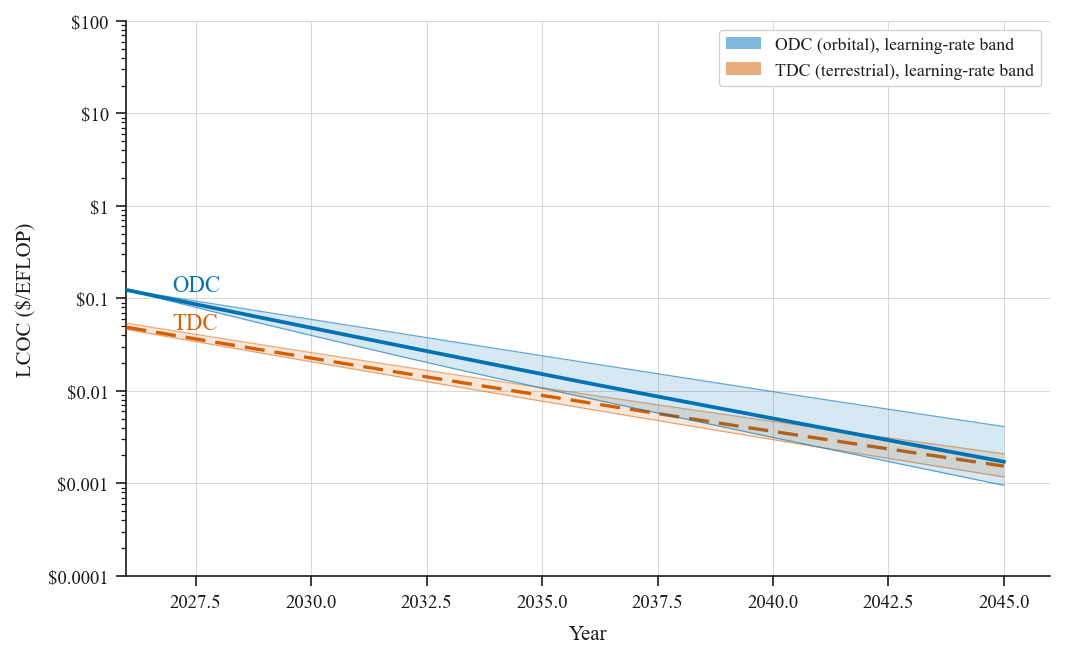

In [43]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))

# TDC band
ax.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.15,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=1.6,
        linestyle=(0, (6, 3)), zorder=4)

# ODC band
ax.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.16,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=1.8, zorder=7)

# Crossover annotation (only renders if the baseline curves actually cross)
diff = odc_nom - tdc_nom
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom[cx] + tdc_nom[cx]) / 2
    ax.axvline(years_calendar[cx], color=INK, linewidth=0.6,
               linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Breakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx] + 1.5, cy * 4.0),
                fontsize=9, color=INK, fontfamily=FONT,
                arrowprops=dict(arrowstyle='->', color=INK, alpha=0.6, lw=0.8))

# End-of-line labels
ax.text(2027, odc_nom[0] * 1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT,
        fontsize=11, va='center')
ax.text(2027, tdc_nom[0] * 1.12, 'TDC', color=TDC_COLOR, fontfamily=FONT,
        fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.5,
                   label='ODC (orbital), learning-rate band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.5,
                   label='TDC (terrestrial), learning-rate band'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True,
                framealpha=1.0, edgecolor=GRID, facecolor='white',
                fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts():
    t.set_color(INK)

style_axes(ax, fig,
    title='',  # caption carries the title in the manuscript
    xlabel='Year',
    ylabel='LCOC ($/EFLOP)',
    xlim=(2026, 2046),
    ylim=(0.0001, 100),
)

plt.tight_layout()
# fig.savefig('lcoc_over_time.pdf')   # vector, for submission
# fig.savefig('lcoc_over_time.png')   # raster preview (300 dpi from rcParams)
plt.show()

### 8b. Tornado sensitivity chart

Each row swings one variable up and down independently around the 2026 baseline and records the resulting LCOC. Rows are sorted by total swing magnitude — variables at the top dominate cost uncertainty. Green = cheaper-LCOC direction; red = more-expensive direction.

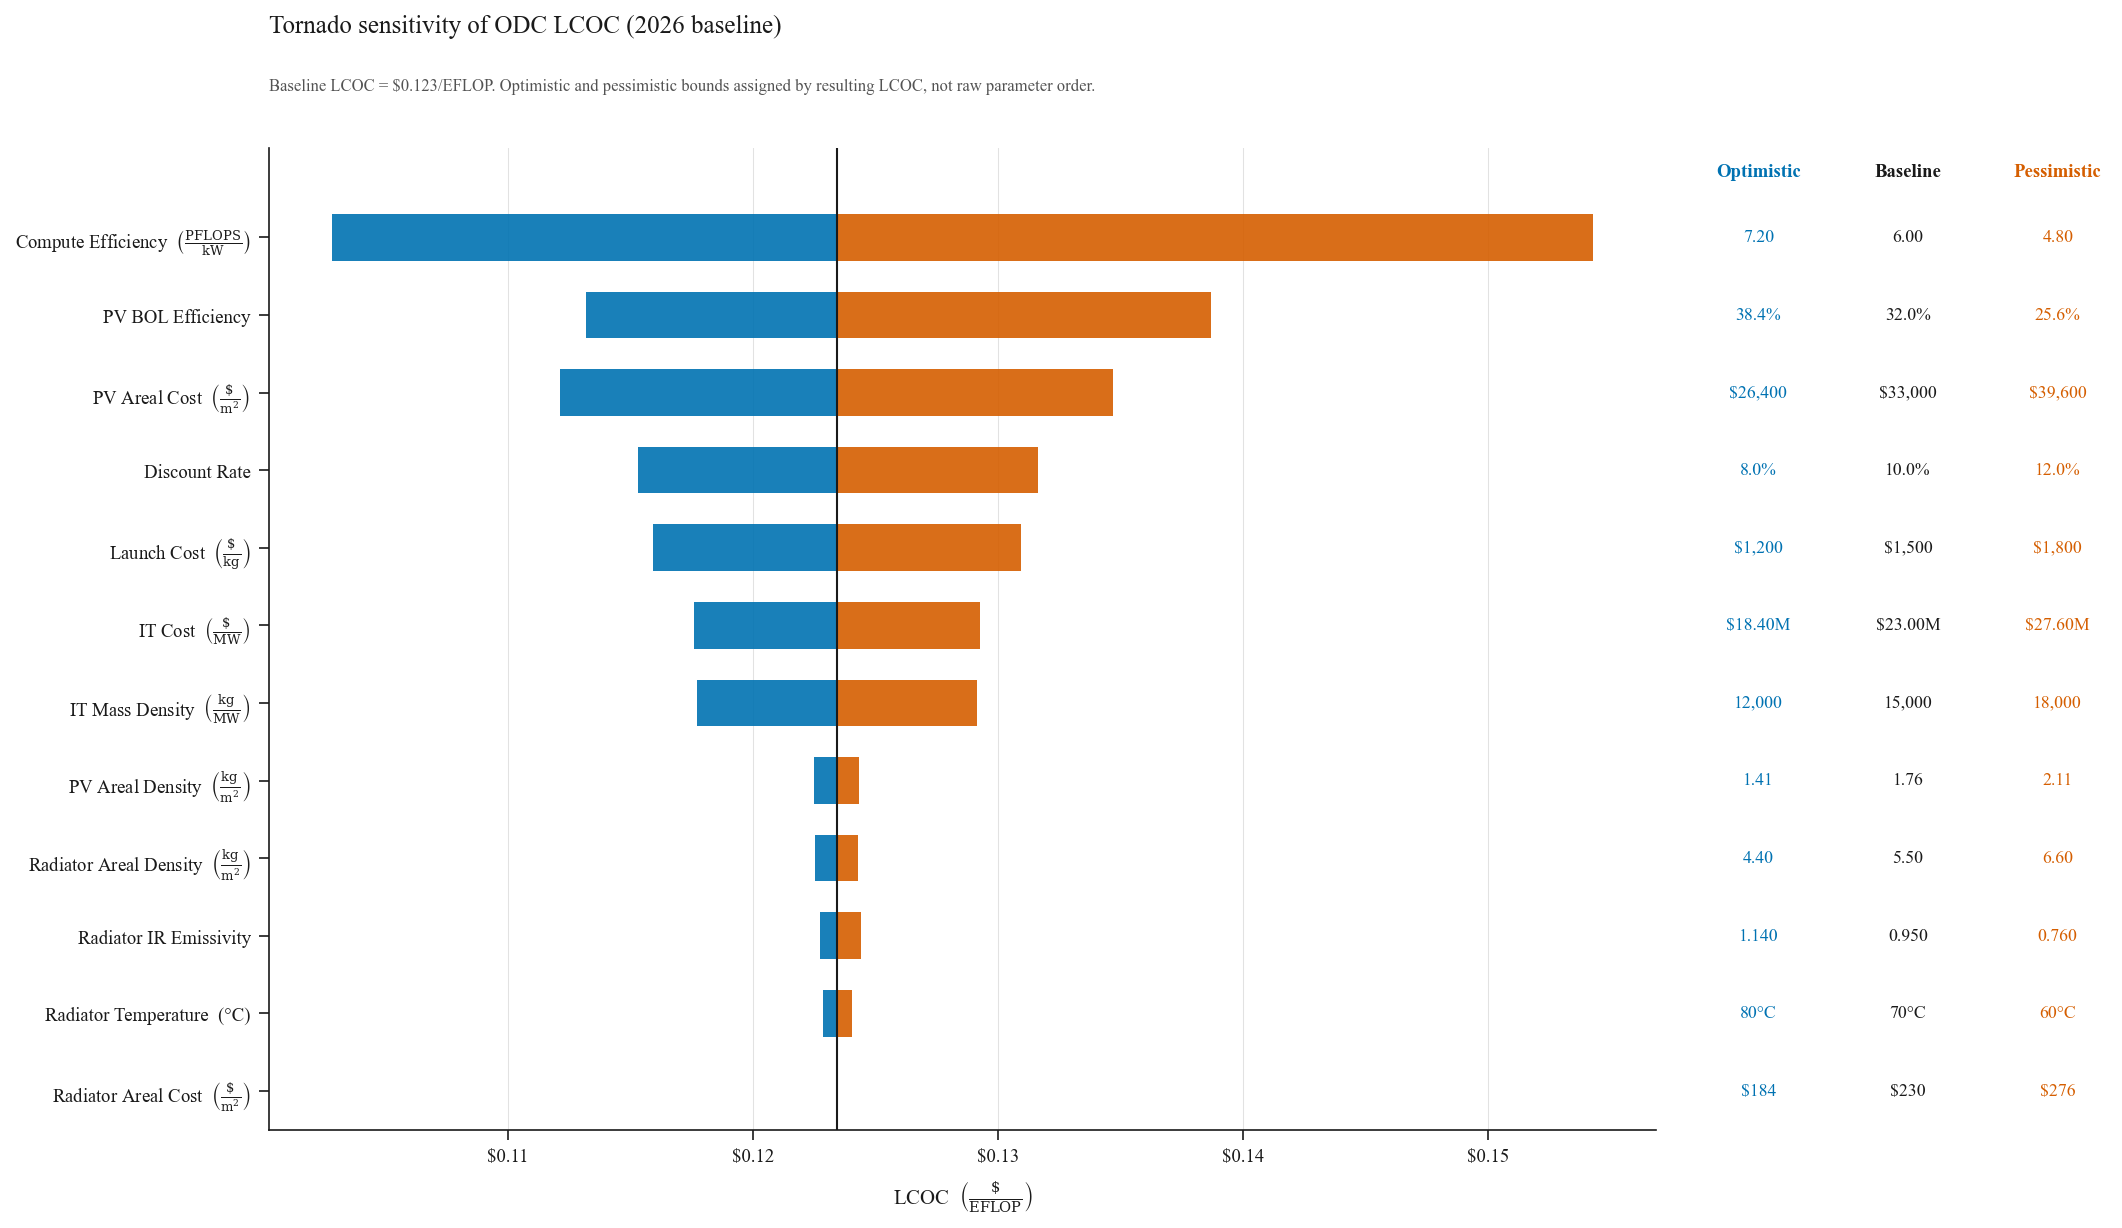

In [44]:
# Parameters to vary, with +/- range
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Radiator Temperature  (\u00b0C)',
     'T_rad_C', None, (60.0, 80.0)),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    if attr == 'T_rad_C':
        return f'{value:.0f}\u00b0C'
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


base_lcoc = calculate_lcoc(BASELINE)['lcoc']

bars = []
for _entry in PARAMS_TO_VARY:
    label, attr, delta = _entry[0], _entry[1], _entry[2]
    _abs_range = _entry[3] if len(_entry) > 3 else None
    base_val = getattr(BASELINE, attr)
    if _abs_range is not None:
        low_param_val, high_param_val = _abs_range
    else:
        low_param_val  = base_val * (1 - delta)
        high_param_val = base_val * (1 + delta)

    lcoc_low  = calculate_lcoc(replace(BASELINE, **{attr: low_param_val}))['lcoc']
    lcoc_high = calculate_lcoc(replace(BASELINE, **{attr: high_param_val}))['lcoc']

    cases = [
        {'param_value': low_param_val,  'lcoc': lcoc_low},
        {'param_value': high_param_val, 'lcoc': lcoc_high},
    ]
    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])
    optimistic_case, pessimistic_case = cases_sorted[0], cases_sorted[-1]

    swing = pessimistic_case['lcoc'] - optimistic_case['lcoc']
    bars.append((
        label, attr,
        optimistic_case['lcoc'], base_lcoc, pessimistic_case['lcoc'], swing,
        optimistic_case['param_value'], base_val, pessimistic_case['param_value'],
    ))

# Largest swing at the top
bars.sort(key=lambda x: x[5], reverse=True)


# -----------------------------------------------------------------------------
# Figure: tornado on the left, value table on the right
# -----------------------------------------------------------------------------
LEFT = 0.34
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                      left=LEFT, right=0.985, top=0.86, bottom=0.09, wspace=0.04)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.6
for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax.barh(i, opt_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.9, zorder=3)      # better (lower LCOC)
    ax.barh(i, pes_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.9, zorder=3)        # worse  (higher LCOC)

# Baseline reference line
ax.axvline(base_lcoc, color=INK, linewidth=1.0, zorder=5)

# Axis styling (categorical y, so no log / no y-grid)
style_axes(ax, fig, title='',
           xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=False, y_dollar=False, x_dollar=True)

ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT, color=INK, fontsize=9)
ax.tick_params(axis='y', pad=4)
ax.grid(axis='y', alpha=0)                              # no horizontal grid
ax.grid(axis='x', color=GRID, alpha=0.6, linewidth=0.5)
ax.set_ylim(len(bars) - 0.5, -1.15)

# Title + subtitle (caption usually carries these in the manuscript)
fig.text(LEFT, 0.965, 'Tornado sensitivity of ODC LCOC (2026 baseline)',
         ha='left', va='top', fontsize=12, color=INK, fontfamily=FONT)
fig.text(LEFT, 0.915,
         fr'Baseline LCOC = ${base_lcoc:.3f}/EFLOP. Optimistic and pessimistic '
         'bounds assigned by resulting LCOC, not raw parameter order.',
         ha='left', va='top', fontsize=8, color=INK, alpha=0.75, fontfamily=FONT)

# -----------------------------------------------------------------------------
# Right-side value table
# -----------------------------------------------------------------------------
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

col_x = {'opt': 0.16, 'base': 0.52, 'pes': 0.88}
for x, header, col in [(col_x['opt'], 'Optimistic',  ODC_COLOR),
                       (col_x['base'], 'Baseline',   INK),
                       (col_x['pes'], 'Pessimistic', ACCENT_R)]:
    ax_tbl.text(x, -0.85, header, ha='center', va='center', fontsize=9,
                color=col, fontfamily=FONT, fontweight='bold')

for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax_tbl.text(col_x['opt'],  i, format_param_value(attr, opt_val),
                ha='center', va='center', fontsize=8.5, color=ODC_COLOR, fontfamily=FONT)
    ax_tbl.text(col_x['base'], i, format_param_value(attr, base_val),
                ha='center', va='center', fontsize=8.5, color=INK, fontfamily=FONT)
    ax_tbl.text(col_x['pes'],  i, format_param_value(attr, pes_val),
                ha='center', va='center', fontsize=8.5, color=ACCENT_R, fontfamily=FONT)

# fig.savefig('tornado_2026.pdf')
# fig.savefig('tornado_2026.png')
plt.show()

### Get rid of IR density + Add carbon price too


### 8c. LCOC vs launch cost sweep

How sensitive is LCOC to launch cost? Three solid/dashed curves at 2026, 2035, 2045 (under baseline learning rates) — each curve sweeps launch cost from \$50 to \$5000/kg while holding everything else at that year's evolved values. Markers show where the baseline launch-cost trajectory lands each year. Horizontal lines = TDC reference at the same year.

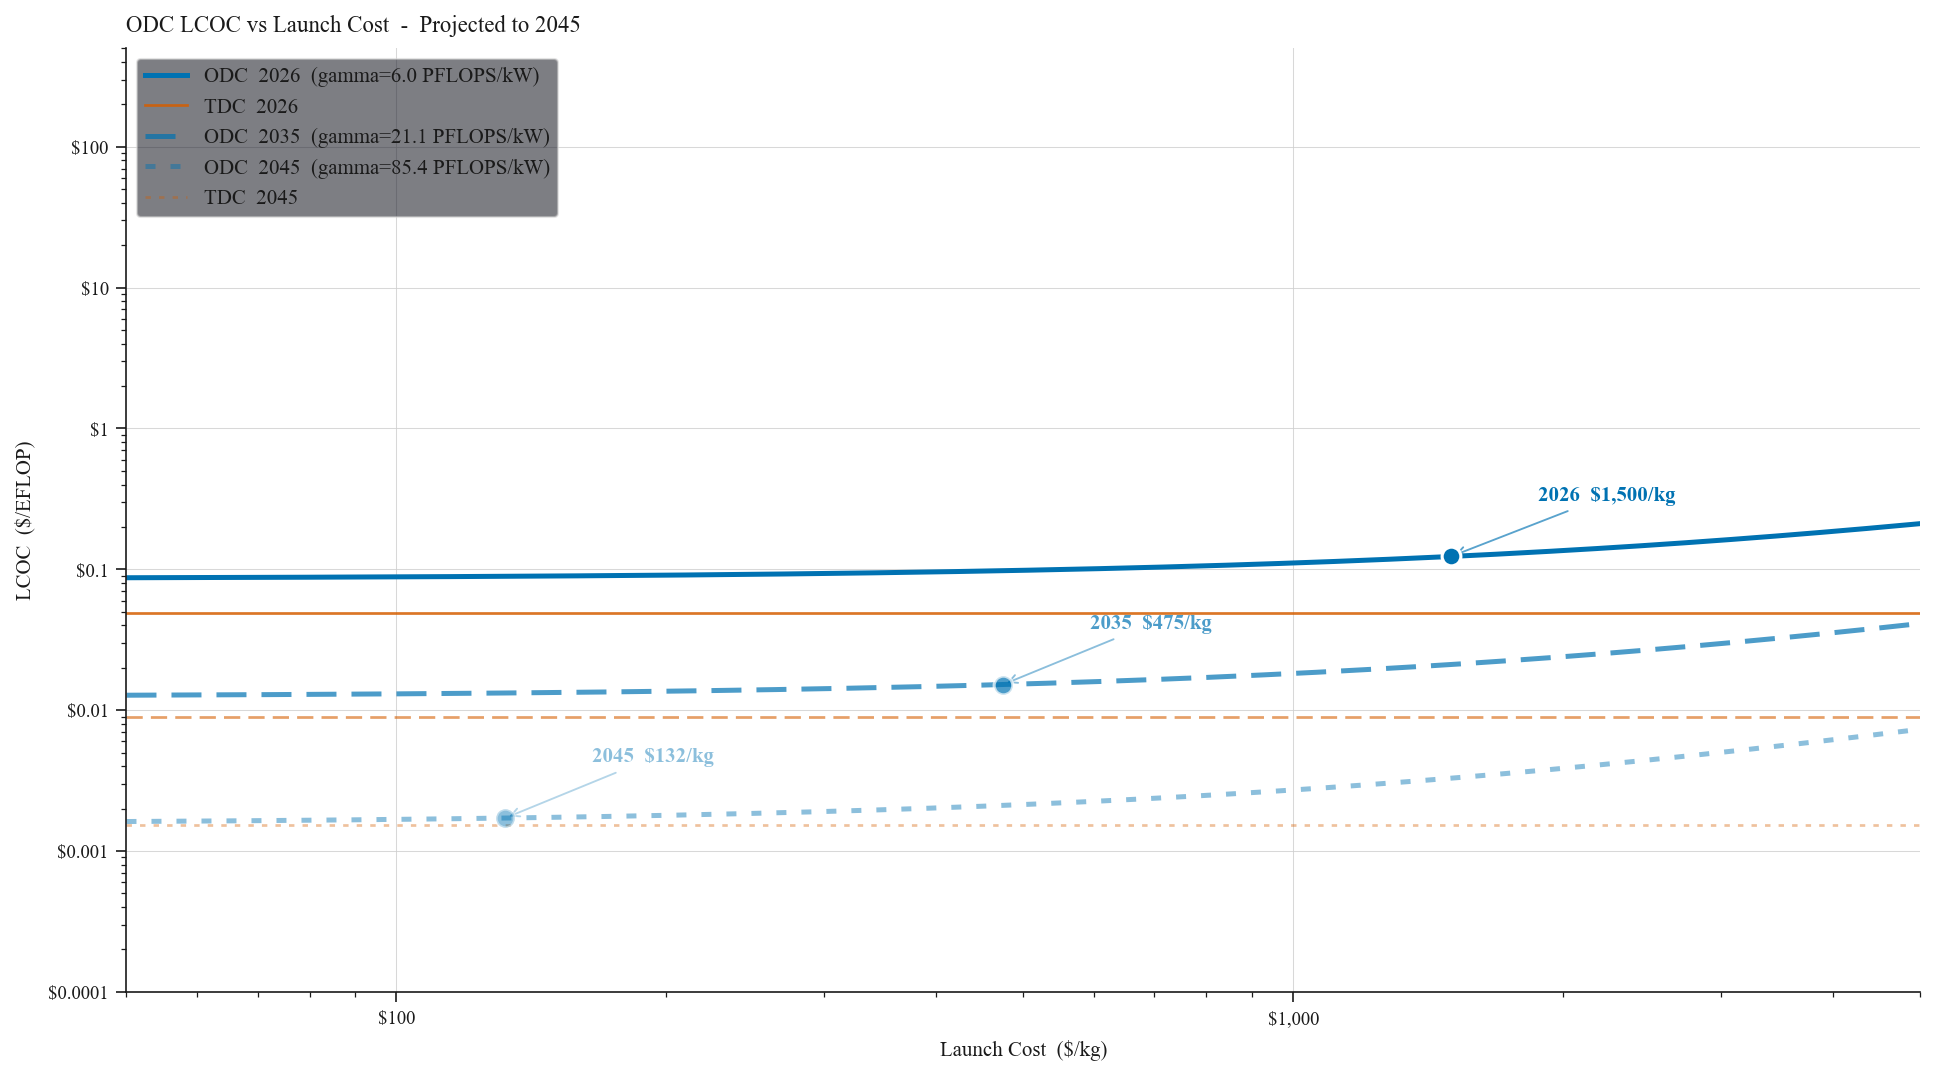

In [45]:
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
line_alphas   = {'2026': 1.00, '2035': 0.70, '2045': 0.45}
line_styles   = {'2026': 'solid', '2035': (0,(6,3)), '2045': (0,(2,3))}

fig, ax = plt.subplots(figsize=(13, 7.5))

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([
        calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
        for lc in launch_costs
    ])
    a  = line_alphas[yr_label]
    ls = line_styles[yr_label]

    ax.plot(launch_costs, lcocs, color=ODC_COLOR, linewidth=2.4,
            linestyle=ls, alpha=a,
            label=f'ODC  {yr_label}  (gamma={ev_base.gamma_PFLOPS_per_kW:.1f} PFLOPS/kW)')

    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    ax.plot(nom_lc, nom_lcoc, 'o', color=ODC_COLOR, markersize=9,
            alpha=a, zorder=10, markeredgecolor=BG, markeredgewidth=1.5)
    ax.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg',
                xy=(nom_lc, nom_lcoc),
                xytext=(nom_lc * 1.25, nom_lcoc * 2.5),
                fontsize=10, color=ODC_COLOR, fontfamily=FONT,
                alpha=a, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=ODC_COLOR,
                                alpha=a*0.65, lw=0.9))

    ax.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.3,
               linestyle=ls, alpha=a*0.85,
               label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = ax.legend(loc='upper left', frameon=True, framealpha=0.55,
                edgecolor=GRID, facecolor='#12141e',
                prop={'family': FONT, 'size': 10})
for t in leg.get_texts(): t.set_color(WHITE)

style_axes(ax, fig,
    title='ODC LCOC vs Launch Cost  -  Projected to 2045',
    # subtitle='Dashed = 2035 & 2045 projection at baseline learning rates  -  Circles = baseline launch cost that year  -  TDC reference lines',
    xlabel='Launch Cost  ($/kg)',
    ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=True,
    xlim=(50, 5000), ylim=(0.0001, 500),
    x_dollar=True, y_dollar=True,
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

### 8d. Data-center demand growth and ODC market-share scenarios

Global data-center demand is projected to grow sharply, and **adoption drives learning**: the more of that demand an ODC fleet serves, the larger its cumulative deployed capacity, and the faster its production-driven costs (launch, PV) fall along a Wright's-law experience curve. This section makes that feedback explicit.

**Demand envelope (sources).** Anchored to: **Goldman Sachs** (global DC power +50% by 2027, +165% by 2030 vs 2023), **IEA** *Energy and AI* (DC electricity ≈ doubles to ~945 TWh by 2030, ~15%/yr), and **McKinsey** *AI Power* (171–219 GW global DC capacity by 2030, 19–22%/yr CAGR, ~70% AI). We take a central capacity path of ~120 GW (2026) → ~195 GW (2030), then a decelerating CAGR to ~430 GW by 2045, with a ±15% band spanning the McKinsey low/high range.

**Panel A** — total DC demand (left axis, band = source spread) with the ODC-*served* capacity (right axis) for four scenarios in which ODCs capture **0.5 / 2 / 5 / 10 % of the *incremental* demand** added after 2026.

**Panel B** — the payoff: 2045 ODC LCOC as a function of ODC market share. Here launch and PV costs are driven **purely by Wright's law on cumulative ODC capacity** (LR = 15 %/doubling launch, 20 %/doubling PV), anchored at C₀ = 0.1 GW with 2026 baseline costs — consistent with the first commercial ODC fleets implied by Starcloud's deployment roadmap (first H100 in orbit Nov 2025; Blackwell commercial module 2026; ~40 MW-class ODCs early 2030s). Compute efficiency γ follows its industry-wide 2045 calendar value (it is not ODC-specific); IT $/MW and radiator cost carry no learning. The dashed line is the 2045 TDC reference: ODC LCOC falls steadily with share as deployment-driven learning compounds, **narrowing the gap to the TDC** (the curve and the reference line meet only if ODC captures enough share to drive launch/PV far enough down the experience curve).

*Caveat:* attributing all launch/PV learning to ODC deployment isolates the adoption→cost feedback; in reality launch also benefits from non-ODC demand, so the share needed for parity is an upper bound.

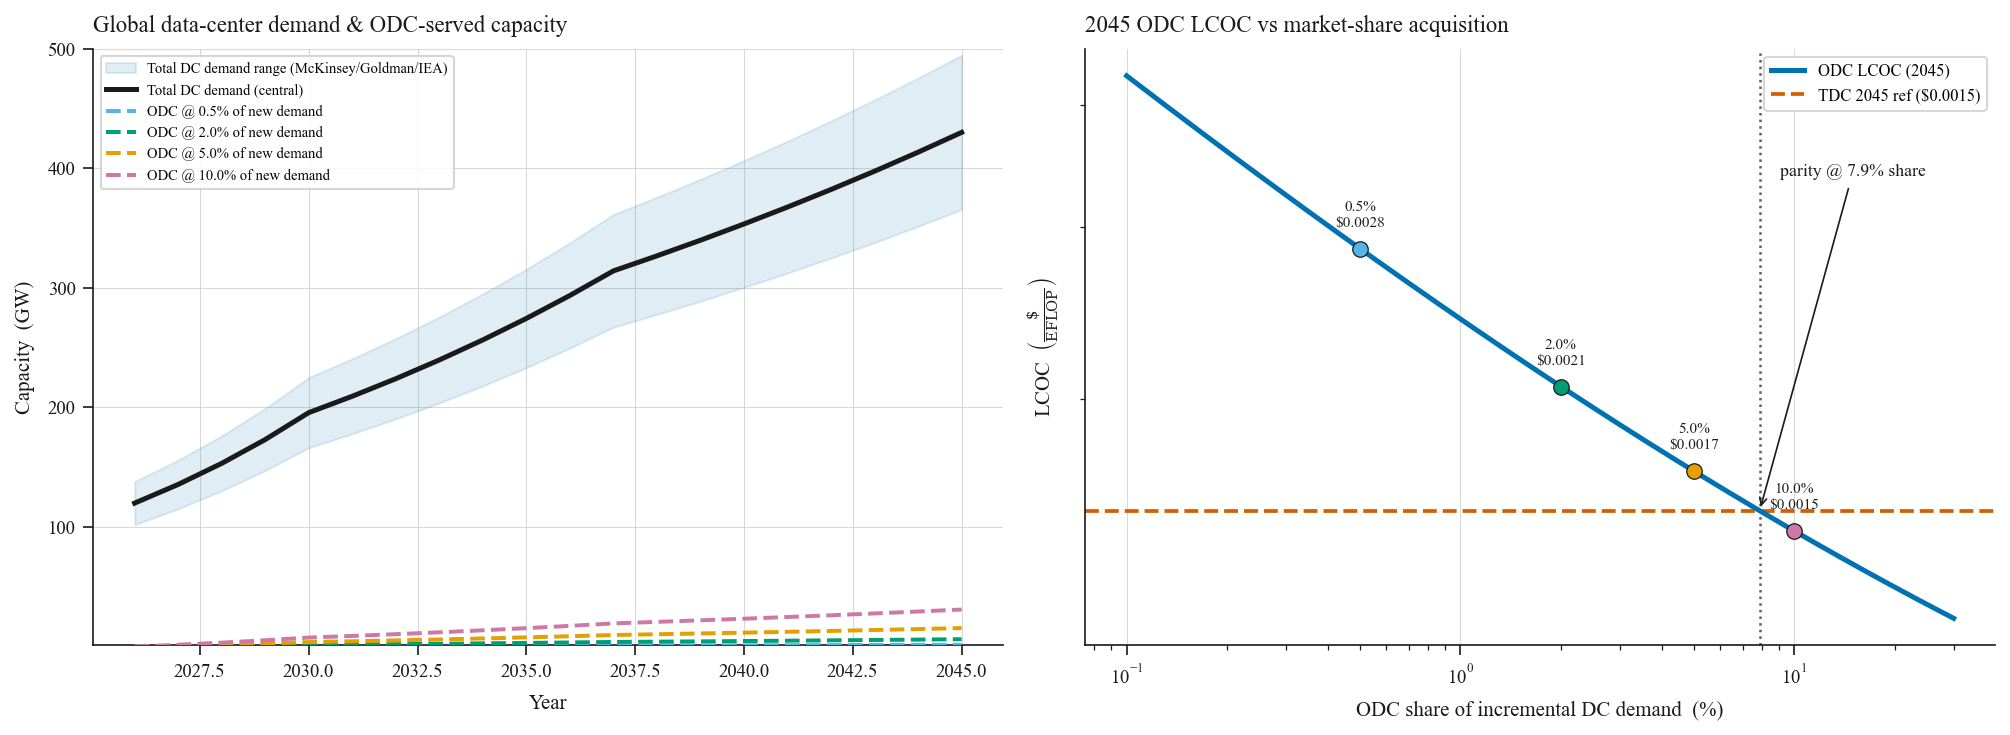

2045 demand: 430 GW  (incremental since 2026: 310 GW)
2045 reference values (consistent across ODC & TDC):
  gamma 85.4 PFLOPS/kW | PV eff 0.350 | IT $4.7M/MW | IT mass 8,409 kg/MW
  TDC 2045 reference LCOC: $0.0015/EFLOP

  share   cum GW    ODC LCOC   ODC/TDC
   0.5%     1.5 $   0.0028    1.86x
   2.0%     6.2 $   0.0021    1.34x
   5.0%    15.5 $   0.0017    1.10x
  10.0%    31.0 $   0.0015    0.95x

ODC<->TDC parity at ~7.87% share of incremental demand (~24 GW of ODC capacity)


In [46]:
# =============================================================================
# 8d. DC demand growth + ODC market-share -> learning -> LCOC
# -----------------------------------------------------------------------------
# FIX vs prior version: odc_lcoc_vs_share() now starts from the consistent 2045
# scenario, evolve_scenario(BASELINE, YR_OFFSET, LR_BASELINE), so IT $/MW and IT
# mass density carry their 2045 values (the SAME ones tdc_2045 uses), then
# overrides ONLY launch and PV cost with the Wright's-law (deployment-scale)
# values. Previously IT $/MW was frozen at the 2026 $23M/MW while the TDC
# reference used the 2045 ~$4.7M/MW, which penalised the ODC and pushed parity
# off the chart. Panel B now labels the share->LCOC values directly.
# =============================================================================

# ---- Total DC demand path (GW of IT capacity), source-anchored ----------------
def dc_demand_GW(year):
    """Central global DC capacity [GW]. Anchors: ~120 GW (2026) -> ~195 GW (2030,
    McKinsey midpoint) -> decelerating CAGR to ~430 GW (2045)."""
    y = np.asarray(year, dtype=float)
    D0 = 120.0  # 2026
    out = np.empty_like(y)
    for k, yr in np.ndenumerate(y):
        if yr <= 2030:
            out[k] = D0 * 1.13 ** (yr - 2026)            # ~13%/yr 2026-2030
        elif yr <= 2037:
            d2030 = D0 * 1.13 ** 4
            out[k] = d2030 * 1.07 ** (yr - 2030)         # ~7%/yr 2030-2037
        else:
            d2037 = D0 * 1.13 ** 4 * 1.07 ** 7
            out[k] = d2037 * 1.04 ** (yr - 2037)         # ~4%/yr 2037-2045
    return out

yrs = np.arange(2026, 2046)
D_base = dc_demand_GW(yrs)
D_low, D_high = 0.85 * D_base, 1.15 * D_base              # +/-15% source spread
D_2026 = dc_demand_GW(2026).item()
incremental = D_base - D_2026                              # demand added after 2026

SHARES = [0.005, 0.02, 0.05, 0.10]                        # ODC share of incremental demand
SHARE_COLORS = ['#56B4E9', '#009E73', '#E69F00', '#CC79A7']  # Okabe-Ito

# ---- Wright's-law learning on cumulative ODC capacity (Panel B) ---------------
C0_GW       = 0.10        # anchor cumulative ODC capacity [GW] (~first commercial fleet)
LR_LAUNCH   = 0.15        # 15% / doubling
LR_PV       = 0.20        # 20% / doubling (Swanson)
YR_OFFSET   = 19          # 2045 calendar offset for industry-wide gamma / TDC

# consistent 2045 reference scenario (gamma, PV eff, IT $/MW, IT mass density)
S_2045      = evolve_scenario(BASELINE, YR_OFFSET, LR_BASELINE)
gamma_2045  = S_2045.gamma_PFLOPS_per_kW
pv_eff_2045 = S_2045.pv_eff_BOL
tdc_2045    = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, YR_OFFSET, LR_BASELINE)
inc_2045    = incremental[-1]                              # GW added by 2045

def odc_lcoc_vs_share(share):
    """2045 ODC LCOC when ODCs serve `share` of incremental demand.
    Launch & PV fall via Wright's law on cumulative ODC capacity (deployment
    scale). gamma, PV efficiency, IT $/MW and IT mass density take their
    consistent 2045 calendar values (matching the TDC reference); radiator
    carries no learning."""
    C = np.maximum(share * inc_2045, C0_GW)
    doublings = np.log2(C / C0_GW)
    launch = BASELINE.launch_cost_per_kg * (1 - LR_LAUNCH) ** doublings
    pv     = BASELINE.pv_areal_cost      * (1 - LR_PV)     ** doublings
    # start from the consistent 2045 scenario, override ONLY launch + PV cost
    s = replace(S_2045, launch_cost_per_kg=float(launch), pv_areal_cost=float(pv))
    return calculate_lcoc(s)['lcoc']

share_grid = np.logspace(np.log10(0.001), np.log10(0.30), 240)
lcoc_grid  = np.array([odc_lcoc_vs_share(s) for s in share_grid])

# parity share (where ODC LCOC crosses TDC 2045)
parity_share = None
below = lcoc_grid <= tdc_2045
if below.any():
    j = np.argmax(below)
    if j > 0:
        x0, x1 = share_grid[j-1], share_grid[j]
        y0, y1 = lcoc_grid[j-1], lcoc_grid[j]
        parity_share = x0 + (tdc_2045 - y0) * (x1 - x0) / (y1 - y0)

# =============================================================================
# Figure
# =============================================================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13.5, 5.0))
fig.patch.set_facecolor(BG)

# ---- Panel A: demand forecast + ODC-served capacity (single GW axis, log) -----
axA.fill_between(yrs, D_low, D_high, color=ODC_COLOR, alpha=0.12, zorder=1,
                 label='Total DC demand range (McKinsey/Goldman/IEA)')
axA.plot(yrs, D_base, color=INK, lw=2.4, zorder=4, label='Total DC demand (central)')
for s, col in zip(SHARES, SHARE_COLORS):
    axA.plot(yrs, s * incremental, color=col, lw=1.9, ls='--', zorder=3,
             label=f'ODC @ {s*100:.1f}% of new demand')
style_axes(axA, fig, title='Global data-center demand & ODC-served capacity',
           xlabel='Year', ylabel='Capacity  (GW)',
           y_log=False, y_dollar=False)
axA.set_ylim(1, 500)
axA.legend(fontsize=7.0, loc='upper left', framealpha=0.85,
           facecolor=BG, edgecolor=GRID)

# ---- Panel B: 2045 ODC LCOC vs market share ----------------------------------
axB.plot(share_grid * 100, lcoc_grid, color=ODC_COLOR, lw=2.4, zorder=3,
         label='ODC LCOC (2045)')
for s, col in zip(SHARES, SHARE_COLORS):
    v = odc_lcoc_vs_share(s)
    axB.scatter(s * 100, v, color=col, s=55, zorder=5, edgecolor=INK, linewidth=0.6)
    # label the (share -> LCOC) value at each marked share
    axB.annotate(f'{s*100:.1f}%\n${v:.4f}', xy=(s * 100, v),
                 xytext=(0, 9), textcoords='offset points',
                 ha='center', va='bottom', fontsize=7.4, color=INK, fontfamily=FONT)
axB.axhline(tdc_2045, color=TDC_COLOR, ls='--', lw=1.8, zorder=2,
            label=f'TDC 2045 ref (${tdc_2045:.4f})')
if parity_share is not None:
    axB.axvline(parity_share * 100, color=INK, ls=':', lw=1.2, alpha=0.7)
    axB.annotate(f'parity @ {parity_share*100:.1f}% share',
                 xy=(parity_share * 100, tdc_2045),
                 xytext=(parity_share * 100 * 1.15, tdc_2045 * 2.2),
                 fontsize=8.5, color=INK, fontfamily=FONT,
                 arrowprops=dict(arrowstyle='->', color=INK, lw=0.8))
style_axes(axB, fig, title='2045 ODC LCOC vs market-share acquisition',
           xlabel='ODC share of incremental DC demand  (%)',
           ylabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=True)
axB.set_xscale('log')
axB.legend(fontsize=8, loc='upper right', framealpha=0.85, facecolor=BG, edgecolor=GRID)

plt.tight_layout()
# fig.savefig('demand_marketshare.pdf'); fig.savefig('demand_marketshare.png', dpi=200)
plt.show()

# ---- values behind Panel B ---------------------------------------------------
print(f'2045 demand: {D_base[-1]:.0f} GW  (incremental since 2026: {inc_2045:.0f} GW)')
print(f'2045 reference values (consistent across ODC & TDC):')
print(f'  gamma {gamma_2045:.1f} PFLOPS/kW | PV eff {pv_eff_2045:.3f} | '
      f'IT ${S_2045.it_cost_per_MW/1e6:.1f}M/MW | IT mass {S_2045.it_mass_density:,.0f} kg/MW')
print(f'  TDC 2045 reference LCOC: ${tdc_2045:.4f}/EFLOP\n')
print(f'{"share":>7} {"cum GW":>8} {"ODC LCOC":>11} {"ODC/TDC":>9}')
for s in SHARES:
    v = odc_lcoc_vs_share(s)
    print(f'{s*100:>6.1f}% {s*inc_2045:>7.1f} ${v:>9.4f} {v/tdc_2045:>7.2f}x')
if parity_share is not None:
    print(f'\nODC<->TDC parity at ~{parity_share*100:.2f}% share of incremental demand '
          f'(~{parity_share*inc_2045:.0f} GW of ODC capacity)')
else:
    print('\nNo parity within plotted share range')

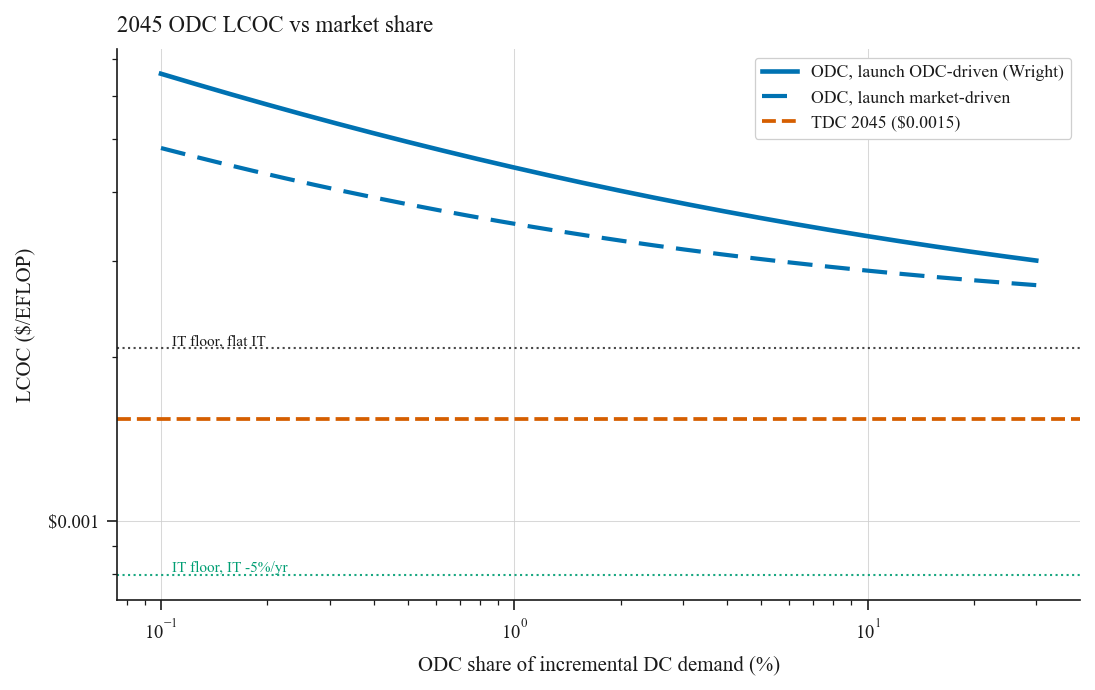

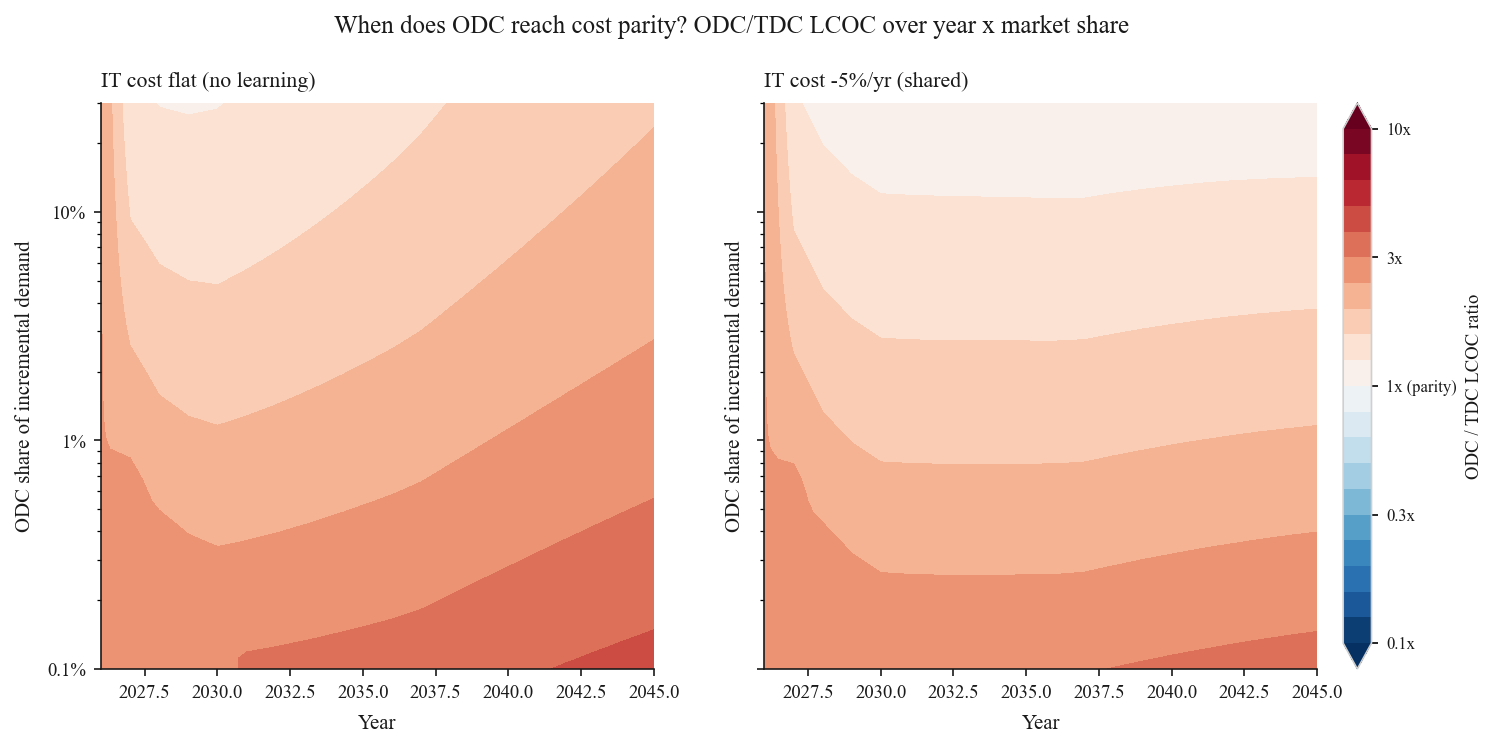

2045 TDC reference: $0.0015/EFLOP
2045 ODC IT-only floor: flat IT $0.0021 | IT -5%/yr $0.0008
  2045 parity (flat IT, ODC-driven launch): none within 30%
  2045 parity (IT -5%/yr, ODC-driven launch): none within 30%


In [47]:
# =============================================================================
# 8d (v2). Demand growth -> ODC market share -> learning -> LCOC
#   - launch learning shown for BOTH experience bases: 'market' (calendar; ODC
#     rides the broader launch market, share-independent) and 'odc' (Wright's law
#     on ODC cumulative capacity). Truth is between.
#   - IT-cost floor drawn explicitly (flat IT vs a small shared IT learning rate).
#   - 2045 share slice PLUS a year x share contour of the ODC/TDC LCOC ratio,
#     with the parity frontier (ratio = 1) overlaid.
# =============================================================================
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

# ---- demand path (unchanged) ------------------------------------------------
def dc_demand_GW(year):
    y = np.asarray(year, dtype=float); D0 = 120.0
    out = np.empty_like(y)
    for k, yr in np.ndenumerate(y):
        if yr <= 2030:   out[k] = D0 * 1.13 ** (yr - 2026)
        elif yr <= 2037: out[k] = D0 * 1.13**4 * 1.07 ** (yr - 2030)
        else:            out[k] = D0 * 1.13**4 * 1.07**7 * 1.04 ** (yr - 2037)
    return out

D_2026 = float(dc_demand_GW(2026))
def incremental_GW(year):
    return float(dc_demand_GW(year)) - D_2026

# ---- learning assumptions ---------------------------------------------------
C0_GW          = 0.10     # anchor cumulative ODC capacity [GW]
LR_LAUNCH      = 0.15     # Wright: 15% / doubling (ODC-driven launch case)
LR_PV          = 0.20     # Swanson: 20% / doubling (space PV, ODC-driven)
IT_LEARN_FLAT  = 0.0      # Trent's assumption
IT_LEARN_SMALL = 0.05     # a shared IT $/MW learning rate (same in all scenarios)

def _doublings(C):
    return max(np.log2(max(C, C0_GW) / C0_GW), 0.0)

def odc_lcoc(year, share, it_learn=0.0, launch_mode='market'):
    yo = year - START_YEAR
    d  = _doublings(share * incremental_GW(year))
    pv_cost = BASELINE.pv_areal_cost * (1 - LR_PV) ** d            # ODC-driven
    if launch_mode == 'odc':
        launch = BASELINE.launch_cost_per_kg * (1 - LR_LAUNCH) ** d
    else:                                                          # 'market'
        launch = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch) ** yo
    gamma  = BASELINE.gamma_PFLOPS_per_kW * (1 + LR_BASELINE.gamma_growth) ** yo
    pv_eff = min(0.35, BASELINE.pv_eff_BOL + LR_BASELINE.pv_eff_pp * yo)
    it_c   = BASELINE.it_cost_per_MW * (1 - it_learn) ** yo
    s = replace(BASELINE, launch_cost_per_kg=float(launch), pv_areal_cost=float(pv_cost),
                gamma_PFLOPS_per_kW=gamma, pv_eff_BOL=pv_eff, it_cost_per_MW=it_c)
    return calculate_lcoc(s)['lcoc']

def odc_floor(year, it_learn, launch_mode):
    """Asymptotic ODC LCOC as share -> large: PV -> 0; launch -> 0 (odc) or market (calendar)."""
    yo = year - START_YEAR
    launch = 0.0 if launch_mode == 'odc' else BASELINE.launch_cost_per_kg*(1-LR_BASELINE.launch)**yo
    s = replace(BASELINE, launch_cost_per_kg=float(launch), pv_areal_cost=0.0,
                gamma_PFLOPS_per_kW=BASELINE.gamma_PFLOPS_per_kW*(1+LR_BASELINE.gamma_growth)**yo,
                pv_eff_BOL=min(0.35, BASELINE.pv_eff_BOL + LR_BASELINE.pv_eff_pp*yo),
                it_cost_per_MW=BASELINE.it_cost_per_MW*(1-it_learn)**yo)
    return calculate_lcoc(s)['lcoc']

def tdc_lcoc_year(year):
    return terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, year - START_YEAR, LR_BASELINE)


# ============================== FIGURE 1 =====================================
# 2045 ODC LCOC vs share: two launch experience bases + IT-cost floors.
YEAR   = 2045
shares = np.logspace(np.log10(0.001), np.log10(0.30), 200)
odc_market = np.array([odc_lcoc(YEAR, s, IT_LEARN_FLAT, 'market') for s in shares])
odc_drive  = np.array([odc_lcoc(YEAR, s, IT_LEARN_FLAT, 'odc')    for s in shares])
tdc_ref     = tdc_lcoc_year(YEAR)
floor_flat  = odc_floor(YEAR, IT_LEARN_FLAT,  'odc')
floor_learn = odc_floor(YEAR, IT_LEARN_SMALL, 'odc')

fig, ax = plt.subplots(figsize=(7.4, 4.7))
ax.plot(shares*100, odc_drive,  color=ODC_COLOR, lw=2.2, label='ODC, launch ODC-driven (Wright)')
ax.plot(shares*100, odc_market, color=ODC_COLOR, lw=2.0, ls=(0,(6,3)),
        label='ODC, launch market-driven')
ax.axhline(tdc_ref, color=TDC_COLOR, lw=1.8, ls='--', label=f'TDC 2045 (${tdc_ref:.4f})')
ax.axhline(floor_flat,  color=INK,       lw=1.0, ls=':', alpha=0.8)
ax.axhline(floor_learn, color='#009E73', lw=1.0, ls=':', alpha=0.9)
ax.text(0.105, floor_flat,  ' IT floor, flat IT',            va='bottom', ha='left', color=INK,       fontsize=7.4, fontfamily=FONT)
ax.text(0.105, floor_learn, f' IT floor, IT -{IT_LEARN_SMALL*100:.0f}%/yr', va='bottom', ha='left', color='#009E73', fontsize=7.4, fontfamily=FONT)

leg = ax.legend(loc='upper right', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)
style_axes(ax, fig, title='2045 ODC LCOC vs market share',
           xlabel='ODC share of incremental DC demand (%)',
           ylabel='LCOC ($/EFLOP)', y_log=True, x_log=True, x_dollar=False)
plt.tight_layout()
fig.savefig('share_slice_2045.pdf'); fig.savefig('share_slice_2045.png')
plt.show()


# ============================== FIGURE 2 (contour) ===========================
# ODC/TDC LCOC ratio over (year x share). Parity = ratio 1 (black line).
# Launch treated as ODC-driven so share is a real lever (optimistic launch case).
yrs_c    = np.arange(START_YEAR, START_YEAR + 20)              # 2026..2045
shares_c = np.logspace(np.log10(0.001), np.log10(0.30), 55)
tdc_row  = np.array([tdc_lcoc_year(y) for y in yrs_c])

def ratio_grid(it_learn, launch_mode='odc'):
    Z = np.empty((len(shares_c), len(yrs_c)))
    for i, sh in enumerate(shares_c):
        for j, y in enumerate(yrs_c):
            Z[i, j] = np.log10(odc_lcoc(y, sh, it_learn, launch_mode) / tdc_row[j])
    return Z

def _style_contour(ax, title):
    ax.set_yscale('log')
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:g}%'))
    ax.set_facecolor(BG)
    for sd in ('top','right'): ax.spines[sd].set_visible(False)
    for sd in ('left','bottom'): ax.spines[sd].set_color(INK); ax.spines[sd].set_linewidth(0.8)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    ax.set_xlabel('Year', fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_ylabel('ODC share of incremental demand', fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.2, 4.9), sharey=True)
fig.patch.set_facecolor(BG)
levels = np.linspace(-1, 1, 21)                                # log10 ratio: 0.1x .. 10x
panels = [(ax1, IT_LEARN_FLAT,  'IT cost flat (no learning)'),
          (ax2, IT_LEARN_SMALL, f'IT cost -{IT_LEARN_SMALL*100:.0f}%/yr (shared)')]
for ax, itl, ttl in panels:
    Z  = ratio_grid(itl)
    cf = ax.contourf(yrs_c, shares_c*100, Z, levels=levels, cmap='RdBu_r', extend='both')
    cl = ax.contour(yrs_c, shares_c*100, Z, levels=[0], colors=INK, linewidths=2.0)
    # if cl.collections and len(cl.allsegs[0]):
    ax.clabel(cl, fmt={0: 'parity'}, fontsize=8, inline=True)
    _style_contour(ax, ttl)

cbar = fig.colorbar(cf, ax=[ax1, ax2], fraction=0.046, pad=0.02,
                    ticks=[-1, -0.5, 0, 0.5, 1])
cbar.ax.set_yticklabels(['0.1x', '0.3x', '1x (parity)', '3x', '10x'],
                        fontfamily=FONT, color=INK, fontsize=8)
cbar.set_label('ODC / TDC LCOC ratio', fontfamily=FONT, color=INK, fontsize=9)
cbar.outline.set_edgecolor(GRID)

fig.suptitle('When does ODC reach cost parity? ODC/TDC LCOC over year x market share',
             fontsize=12, color=INK, fontfamily=FONT, x=0.5, y=1.0)
# fig.savefig('parity_contour.pdf', bbox_inches='tight')
# fig.savefig('parity_contour.png', bbox_inches='tight')
plt.show()


# ---- readout ----------------------------------------------------------------
print(f'2045 TDC reference: ${tdc_ref:.4f}/EFLOP')
print(f'2045 ODC IT-only floor: flat IT ${floor_flat:.4f} | IT -{IT_LEARN_SMALL*100:.0f}%/yr ${floor_learn:.4f}')
for itl in (IT_LEARN_FLAT, IT_LEARN_SMALL):
    pe = [s for s in shares if odc_lcoc(2045, s, itl, 'odc') <= tdc_ref]
    tag = 'flat IT' if itl == 0 else f'IT -{itl*100:.0f}%/yr'
    print(f'  2045 parity ({tag}, ODC-driven launch): '
          + (f'share >= {min(pe)*100:.2f}%' if pe else 'none within 30%'))

## 9. Summary

In [48]:
print('=' * 96)
print('SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)')
print('=' * 96)
print(f'\nBaseline ODC parameters (locked initial values, 2026):')
print(f'  gamma           = {BASELINE.gamma_PFLOPS_per_kW} PFLOPS/kW')
print(f'  Launch          = ${BASELINE.launch_cost_per_kg:,.0f}/kg')
print(f'  PV eta_BOL      = {BASELINE.pv_eff_BOL}')
print(f'  PV areal cost   = ${BASELINE.pv_areal_cost:,.0f}/m^2')
print(f'  Rad areal cost  = ${BASELINE.rad_areal_cost:,.0f}/m^2')
print(f'  IT cost         = ${BASELINE.it_cost_per_MW/1e6:.1f}M/MW')
print(f'  alpha_solar     = {BASELINE.alpha_solar_rad}')
print(f'  alpha_IR        = {BASELINE.eps_IR}')
print(f'\nLearning-rate scenarios drive the uncertainty band on plots.')
print()

print(f'{"Year":>6s}  |   {"ODC range $/EFLOP":>32s}     {"TDC range $/EFLOP":>32s}  |  ratio')
print(f'{"":>6s}  |   {"(pes / base / opt)":>32s}     {"(pes / base / opt)":>32s}  |  (base)')
print('-' * 96)
for label, idx in [('2026', 0), ('2030', 4), ('2035', 9), ('2040', 14), ('2045', 19)]:
    odc_range = f'${odc_lo[idx]:.4f} / ${odc_nom[idx]:.4f} / ${odc_hi[idx]:.4f}'
    tdc_range = f'${tdc_lo[idx]:.4f} / ${tdc_nom[idx]:.4f} / ${tdc_hi[idx]:.4f}'
    print(f'{label:>6s}  |   {odc_range:>32s}     {tdc_range:>32s}  |  {odc_nom[idx]/tdc_nom[idx]:.2f}x')

print()
print('Cost breakdown for 2026 baseline ODC:')
for k, v in baseline_result['breakdown'].items():
    print(f'  {k:10s} ${v:.4f}/EFLOP   ({v/baseline_result["lcoc"]*100:5.1f}%)')

print()
print('Key takeaways:')
print('  - Initial parameter values are locked; only the learning rate varies.')
print('  - Launch cost decline drives the ODC trajectory; under baseline LR, launch falls')
print('    below ~$200/kg by 2045, narrowing the gap to TDC substantially.')
print('  - gamma improvement applies to both ODC and TDC equally and shifts both curves')
print('    down in parallel - it does not by itself close the ODC/TDC gap.')
print('  - PV areal cost ($33,000/m^2) and IT cost ($23M/MW) are now the second-tier')
print('    sensitivities behind launch.  See the tornado chart for confirmation.')

SUMMARY: Orbital vs Terrestrial DC LCOC (2026-2045)

Baseline ODC parameters (locked initial values, 2026):
  gamma           = 6.0 PFLOPS/kW
  Launch          = $1,500/kg
  PV eta_BOL      = 0.32
  PV areal cost   = $33,000/m^2
  Rad areal cost  = $230/m^2
  IT cost         = $23.0M/MW
  alpha_solar     = 0.05
  alpha_IR        = 0.95

Learning-rate scenarios drive the uncertainty band on plots.

  Year  |                  ODC range $/EFLOP                    TDC range $/EFLOP  |  ratio
        |                 (pes / base / opt)                   (pes / base / opt)  |  (base)
------------------------------------------------------------------------------------------------
  2026  |        $0.1234 / $0.1234 / $0.1234          $0.0539 / $0.0487 / $0.0461  |  2.53x
  2030  |        $0.0593 / $0.0481 / $0.0398          $0.0260 / $0.0226 / $0.0207  |  2.13x
  2035  |        $0.0240 / $0.0152 / $0.0107          $0.0108 / $0.0089 / $0.0077  |  1.70x
  2040  |        $0.0098 / $0.0050 / $0.0

# Carbon Impact

Verification: F_perp_adjacent(1,1) = 0.20004 (expect 0.20004)

CARBON MODEL  -  100 MW IT, 15 yr mission, grid 0.40 tCO2e/MWh

PHYSICAL SIZING
  PV array :      270,130 m^2  (50.5 football fields)
  Geometry: L=300 m, H=450.2 m, h=1.501, W=229.6 m (w=0.7652)
  F_PV (per face): 0.2567   Net cooling: 1452.1 W/m^2
  Radiator :       68,866 m^2  (12.9 football fields)
  Mass budget (t): PV 475, Radiator 634, IT 1,500, Total 2,609

TDC CARBON (tCO2e)
  IT (all gens)   :      103,096
  Core & shell    :       32,500
  MEP             :       20,000
  Embodied total  :      155,596
  Operational     :    5,886,720
  TOTAL           :    6,042,316  (6.04 Mt)

ODC CARBON (tCO2e)
  Launches: 57  @ 16,222 t/launch
  Launch initial  :      438,002
  Launch refresh  :      486,669
  IT (all gens)   :      103,096
  PV array        :      378,182
  Radiator        :        5,923
  TOTAL           :    1,411,872  (1.41 Mt)

  ODC/TDC ratio @ grid 0.40: 0.23x

Figures written to carbon_figs/: tdc_carb

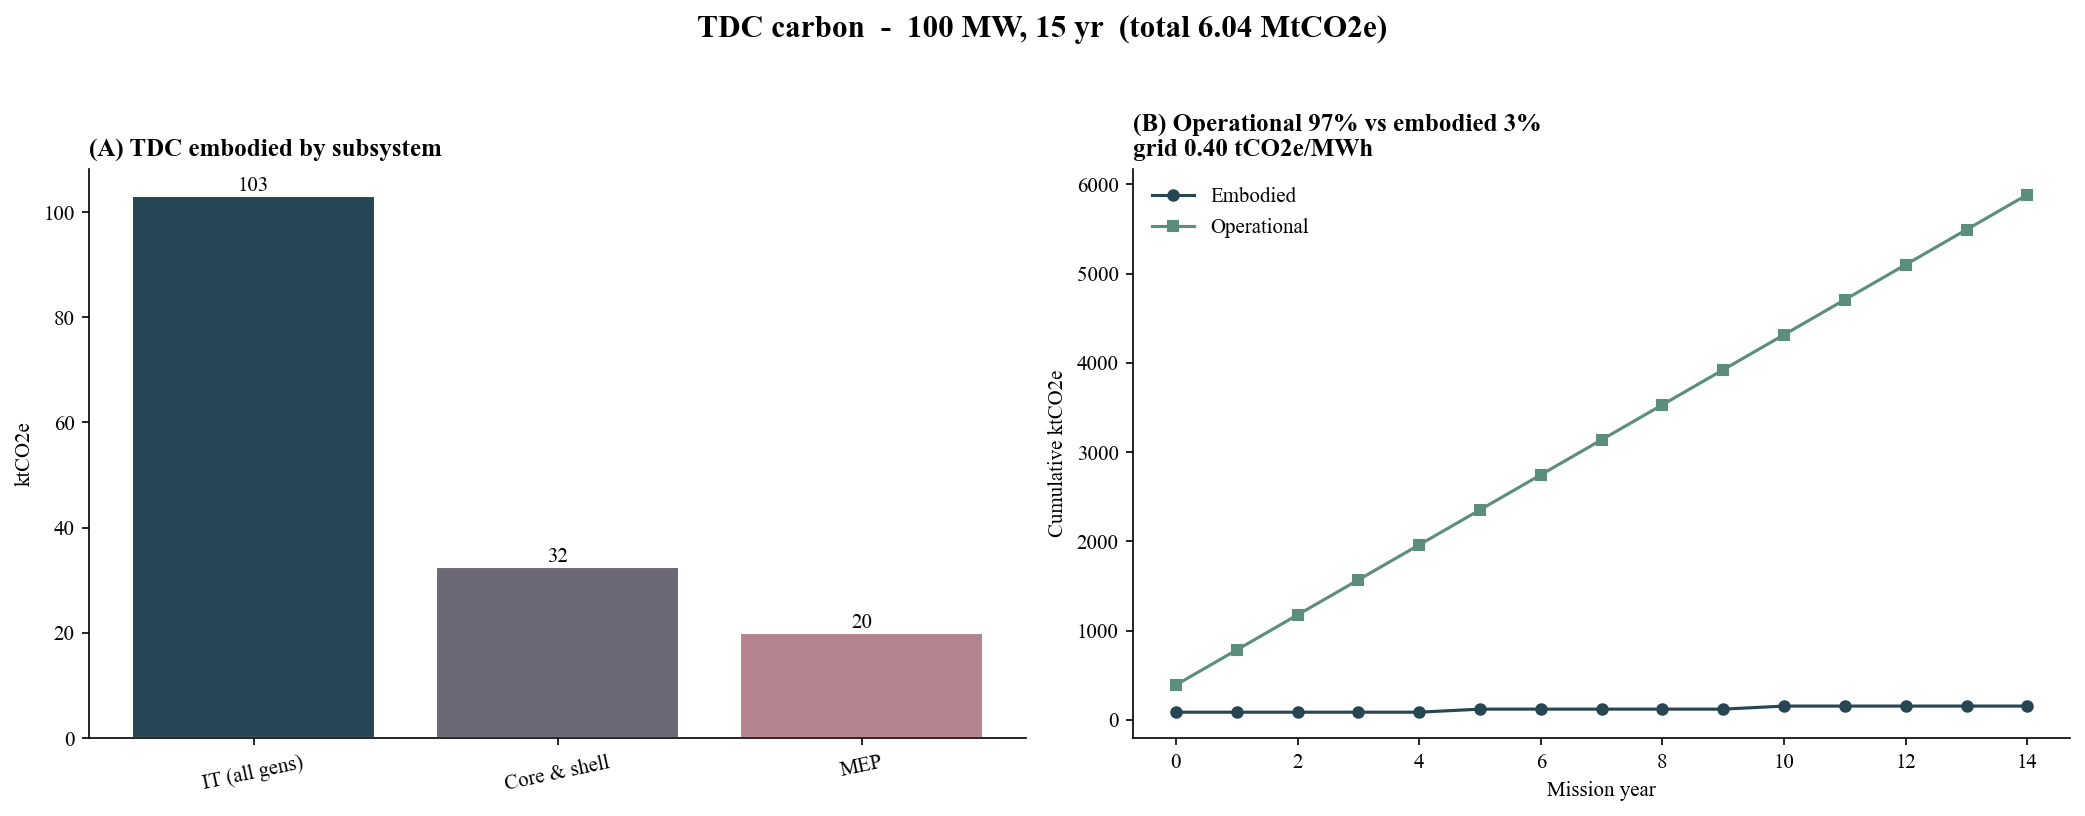

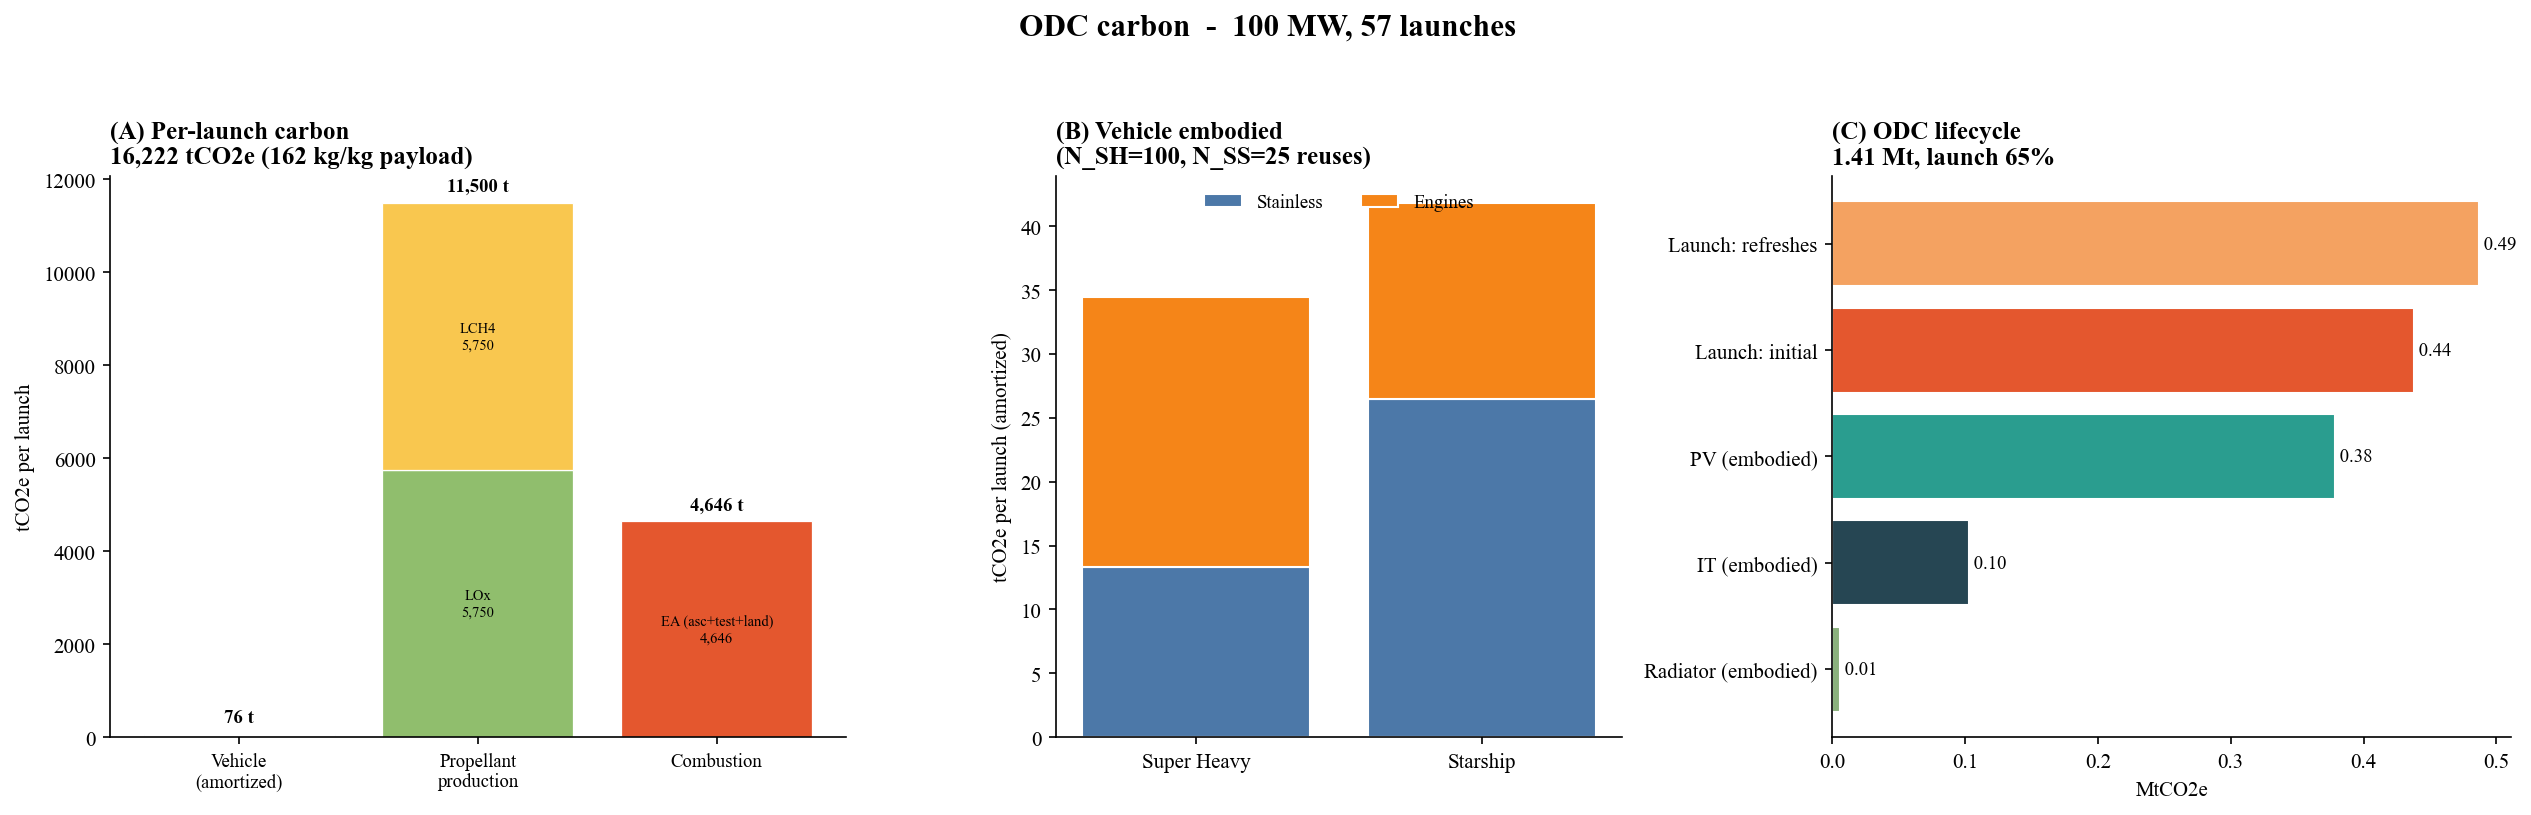

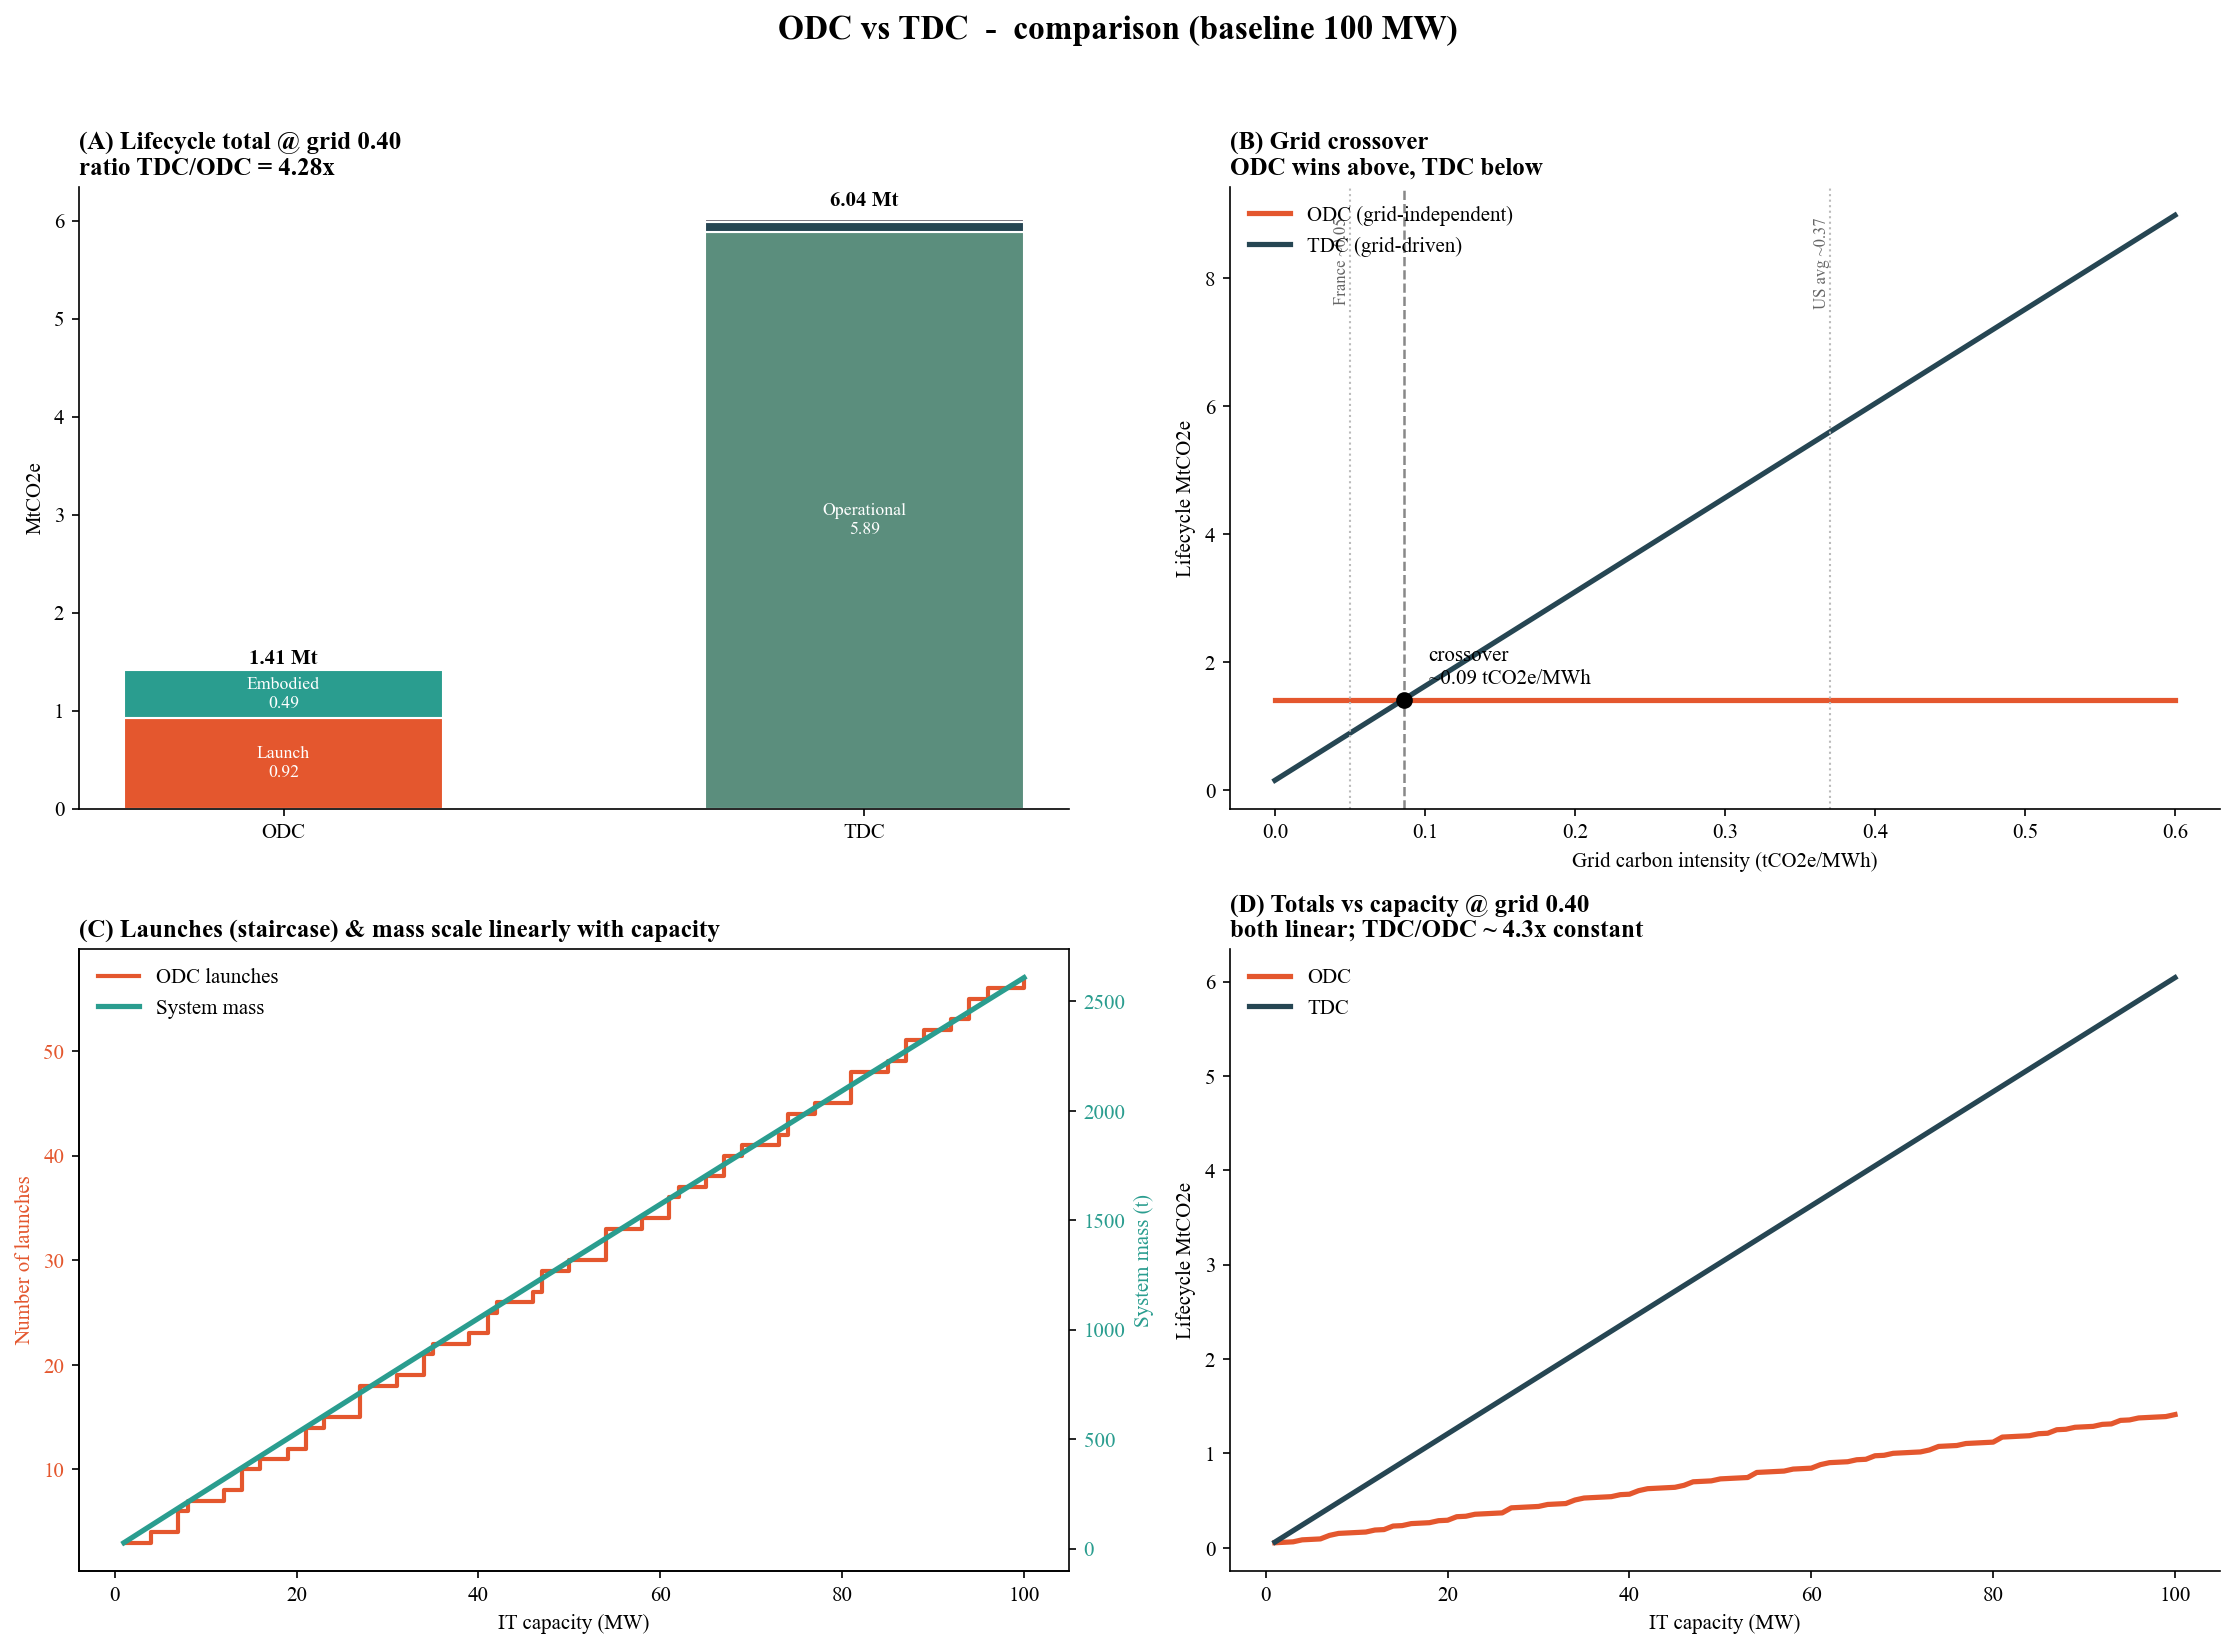

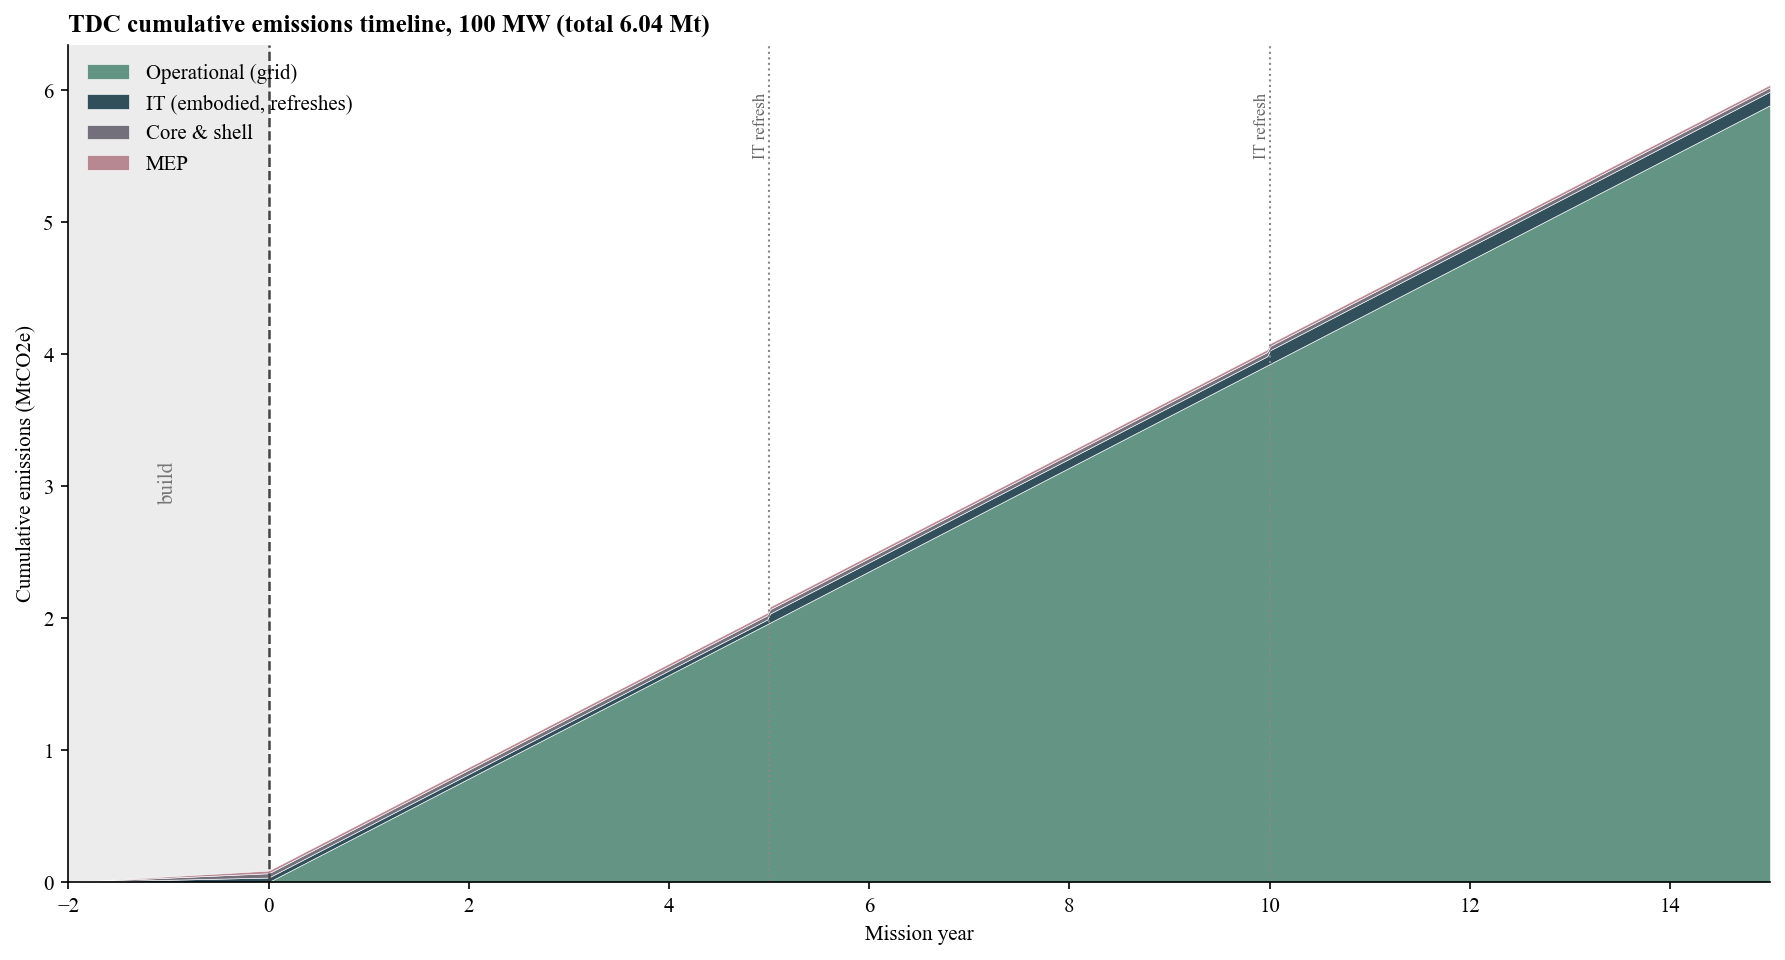

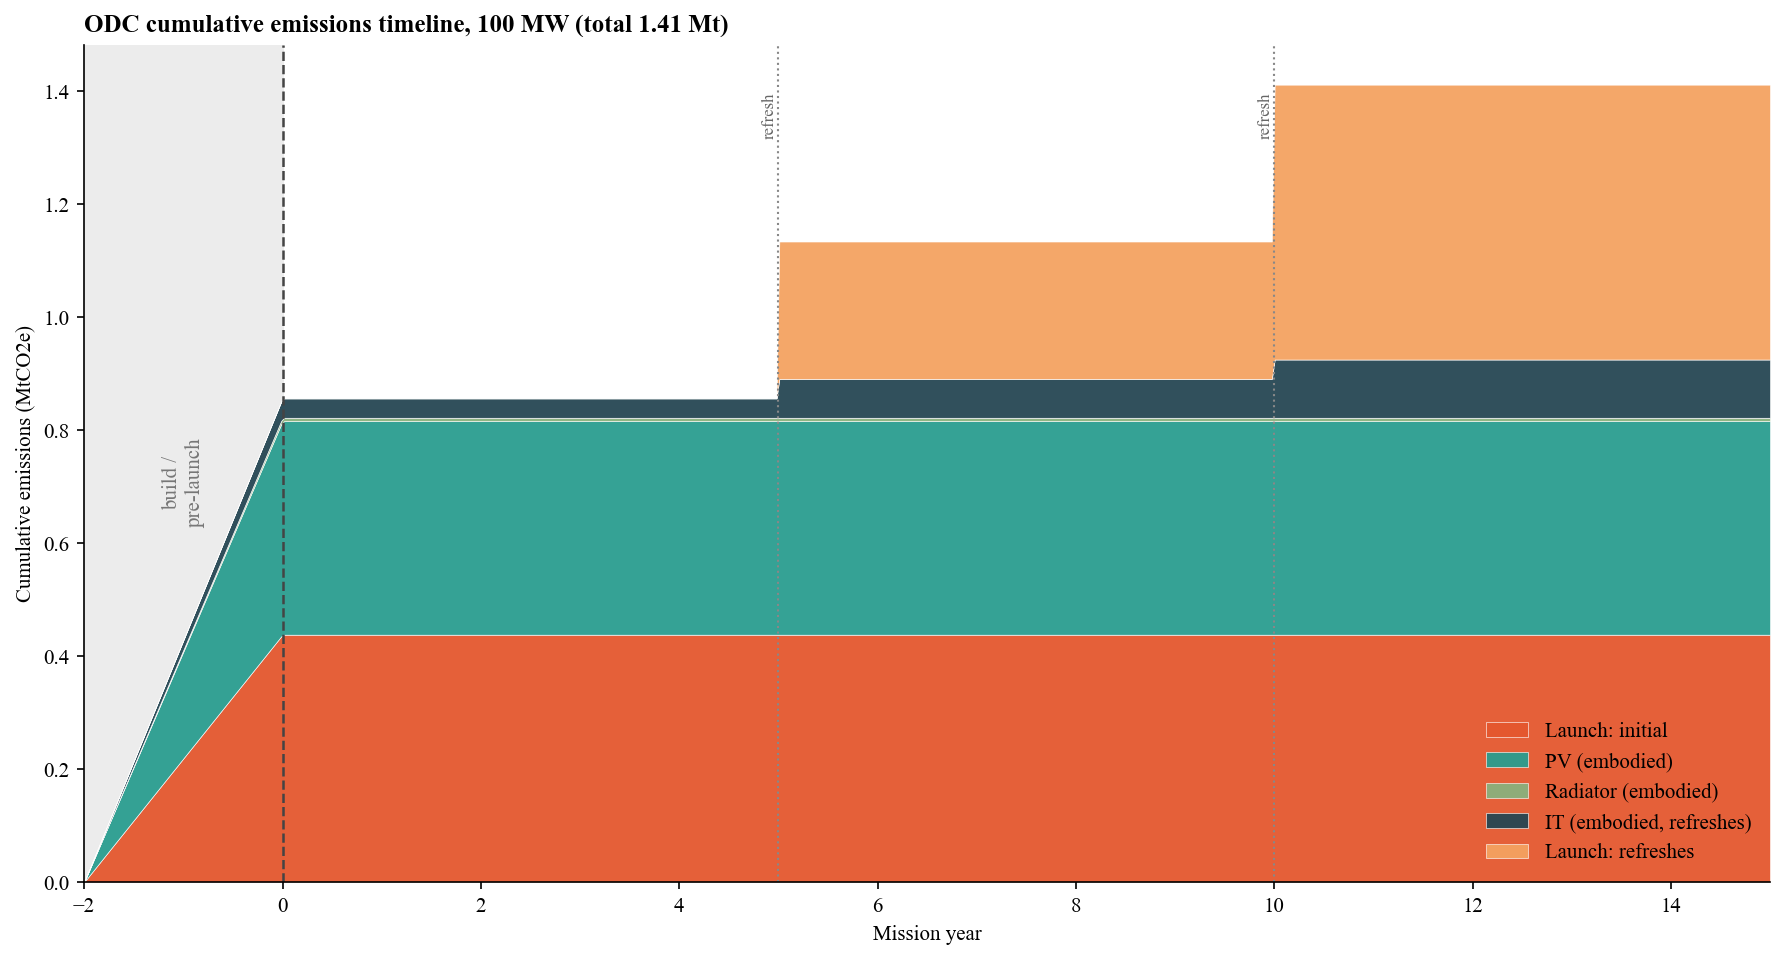

In [49]:
# =============================================================================
# REPLACES: ALL OF CELL 32 (the full end-to-end carbon model cell).
# This is the COMPLETE original cell with ONE change:
#   it_mass_density default 55_000.0 -> 15_000.0  (see "CHANGED" below).
# Paste this over the ENTIRE cell 32. It keeps CAPACITY_MW, the constants, every
# carbon function (odc_carbon / tdc_carbon / sizing) and the plotting, so the
# NameErrors (CAPACITY_MW, odc_carbon_result) are resolved.
# =============================================================================
import os
import math
from dataclasses import dataclass, replace

import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ================================================================================
# ODC vs TDC -- end-to-end life-cycle carbon model (GWP100)
# Set CAPACITY_MW below; everything else sizes off it.
#
# NOTE: dataclass + sizing functions are namespaced (CarbonScenario, c_size_*,
# c_mass_budget) so they do NOT clobber the financial-model Scenario / size_* /
# mass_budget defined earlier in the notebook. Both models stay live together.
#
# Sources: Alissa et al. 2025 Nature 641:331 (facility LCA); Falk et al. 2025
# arXiv:2509.00093 + NVIDIA HGX B200 PCF (IT embodied); Miraux 2022 (Starship
# vehicle/propellant); IAI 2023 (aluminium); Swart 2011 + Mohr 2007 (PV);
# BaSO4 coating + IAI (radiator). Author sizing model for PV/radiator geometry.
# ================================================================================

CAPACITY_MW = 100.0          # DEFAULT DC IT capacity

# ----------------------------------------------------------------- constants --
I_SUN         = 1361.0       # solar constant [W/m^2]
SIGMA         = 5.670374419e-8
T_EARTH_EFF   = 254.15       # Earth effective radiating temp [K] (NASA)
EARTH_ALBEDO  = 0.306        # (NASA)
FOOTBALL_M2   = 5350.0       # for human-scale prints

os.makedirs("carbon_figs", exist_ok=True)


# ================================================================== scenario ==
@dataclass
class CarbonScenario:
    # capacity / mission
    it_capacity_mw: float = CAPACITY_MW
    mission_years:  int   = 15
    it_refresh_years: int = 5

    # --- PV array ---
    pv_eff_BOL:   float = 0.32      # triple-junction GaAs BOL efficiency
    pv_derating:  float = 0.85      # wiring/mismatch/soiling-equivalent (PVWatts)
    pv_areal_mass: float = 1.76     # kg/m^2 (Spectrolab stack)
    pv_kgco2e_m2: float = 1400.0    # embodied, central (Swart 2011 + Mohr 2007)

    # --- radiator (single horizontal beam, double-sided) ---
    T_rad_C:        float = 80.0
    T_PV_C:         float = 31.1    # PV temp from radiative energy balance (consistent w/ main model)
    L_rad:          float = 300.0   # fixed beam length [m]; width solved for
    eps_IR:         float = 0.95
    eps_PV_back:    float = 0.84
    alpha_solar_rad: float = 0.05
    F_earth:        float = 0.10
    rad_areal_mass: float = 9.2     # kg/m^2 (BaSO4 coat 4.5 + Al 4.7)
    rad_kgco2e_m2:  float = 86.0    # embodied, central

    # --- IT (shared by ODC and TDC for apples-to-apples) ---
    it_mass_density:    float = 15_000.0   # kg/MW  CHANGED 55,000 -> 15,000 (matches financial model)
    node_power_kw:      float = 10.4
    gpu_baseboard_kgco2e: float = 2274.0   # HGX B200 PCF
    host_server_kgco2e:   float = 1300.0

    # --- TDC facility / operation ---
    pue:              float = 1.12
    load_factor:      float = 1.0
    grid_intensity:   float = 0.40   # tCO2e/MWh == kgCO2e/kWh
    grid_decarb:      float = 0.0
    power_density_kw_m2: float = 2.0
    shell_kgco2e_m2:  float = 650.0
    mep_kgco2e_m2:    float = 400.0

    # --- ODC launch vehicle (Starship; Miraux 2022) ---
    sh_dry_t:    float = 275.0
    ss_dry_t:    float = 120.0
    n_raptor_sh: int   = 33
    n_raptor_ss: int   = 6
    raptor_mass_t: float = 1.6
    propellant_t: float = 4600.0
    o_f_ratio:   float = 3.6
    payload_cap_t: float = 100.0     # payload to LEO per launch
    n_sh_reuse:  float = 100.0
    n_ss_reuse:  float = 25.0
    ci_steel:    float = 6.0         # kgCO2e/kg stainless
    ci_engine:   float = 40.0        # kgCO2e/kg Ni-superalloy
    ci_prop_prod: float = 2.5        # kgCO2e/kg methalox (LOx+LCH4 production)
    combustion_ea_t: float = 4646.0  # tCO2e/launch (FAA EA; ascent+tests+landing)
    include_reentry: bool = False    # reused vehicle -> ~0 per delivery


def c_q_compute(s: CarbonScenario) -> float:
    """Compute heat / power load [W]."""
    return s.it_capacity_mw * 1e6


# ============================================================ physical sizing ==
def F_perp_adjacent(h: float, w: float) -> float:
    """View factor: horizontal W x L plate -> perpendicular L x H plate sharing edge L.
    h = H/L, w = W/L. Howell/Siegel adjacent perpendicular rectangles.
    Verified: F_perp_adjacent(1, 1) ~ 0.20004."""
    H2W2 = h**2 + w**2
    a = ((1 + h**2) * (1 + w**2)) / (1 + H2W2)
    b = (w**2 * (1 + H2W2)) / ((1 + w**2) * H2W2)
    c = (h**2 * (1 + H2W2)) / ((1 + h**2) * H2W2)
    term = (h * np.arctan(1/h) + w * np.arctan(1/w)
            - np.sqrt(H2W2) * np.arctan(1/np.sqrt(H2W2))
            + 0.25 * np.log(a * b**(w**2) * c**(h**2)))
    return term / (np.pi * w)


def c_size_pv_array(s: CarbonScenario) -> float:
    return c_q_compute(s) / (s.pv_eff_BOL * s.pv_derating * I_SUN)


def c_size_radiator(s: CarbonScenario, verbose: bool = False) -> float:
    """Self-consistent radiator area for a single horizontal beam (double-sided).
    L = s.L_rad fixed; brentq solves width ratio w = W/L."""
    T_r  = s.T_rad_C + 273.15
    T_PV = s.T_PV_C  + 273.15
    A_PV = c_size_pv_array(s)
    H    = A_PV / (2 * s.L_rad)
    h    = H / s.L_rad
    L    = s.L_rad
    Q    = c_q_compute(s)

    def q_net(w):
        F_pv = F_perp_adjacent(h, w)
        q_ir = (2*s.eps_IR*SIGMA*T_r**4
                - 2*s.eps_IR*s.eps_PV_back*F_pv*SIGMA*T_PV**4
                - s.eps_IR*SIGMA*T_EARTH_EFF**4*s.F_earth)
        q_alb = s.alpha_solar_rad * EARTH_ALBEDO * I_SUN * s.F_earth
        return q_ir - q_alb

    resid = lambda w: q_net(w) * (w * L**2) - Q
    w_star = brentq(resid, 1e-4, 1e4)
    A_rad  = w_star * L**2

    if verbose:
        q = q_net(w_star); F_pv = F_perp_adjacent(h, w_star)
        print(f'  Geometry: L={L:.0f} m, H={H:.1f} m, h={h:.3f}, '
              f'W={w_star*L:.1f} m (w={w_star:.4f})')
        print(f'  F_PV (per face): {F_pv:.4f}   Net cooling: {q:.1f} W/m^2')
    return A_rad


def c_mass_budget(s: CarbonScenario) -> dict:
    A_PV  = c_size_pv_array(s)
    A_rad = c_size_radiator(s)
    m_PV  = A_PV  * s.pv_areal_mass
    m_rad = A_rad * s.rad_areal_mass
    m_IT  = s.it_capacity_mw * s.it_mass_density
    return {'A_PV': A_PV, 'A_rad': A_rad,
            'PV': m_PV, 'Radiator': m_rad, 'IT': m_IT,
            'Total': m_PV + m_rad + m_IT}


# ================================================================ IT helpers ==
def it_quantities(s: CarbonScenario) -> dict:
    nodes = s.it_capacity_mw * 1000.0 / s.node_power_kw
    gens  = math.ceil(s.mission_years / s.it_refresh_years)
    per_gen_t = nodes * (s.gpu_baseboard_kgco2e + s.host_server_kgco2e) / 1000.0
    return {'nodes': nodes, 'generations': gens,
            'per_gen_t': per_gen_t, 'all_gens_t': per_gen_t * gens}


# =================================================================== TDC model ==
def tdc_carbon(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    area = s.it_capacity_mw * 1000.0 / s.power_density_kw_m2
    shell = area * s.shell_kgco2e_m2 / 1000.0
    mep   = area * s.mep_kgco2e_m2   / 1000.0

    yrs = list(range(s.mission_years))
    emb = [0.0]*s.mission_years
    op  = [0.0]*s.mission_years
    emb[0] += shell + mep
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb[yr] += it['per_gen_t']
    annual_mwh = s.it_capacity_mw * s.pue * s.load_factor * 8760.0
    for y in yrs:
        gi = s.grid_intensity * (1 - s.grid_decarb)**y
        op[y] = annual_mwh * gi

    emb_total = sum(emb); op_total = sum(op)
    return {
        'breakdown': {'IT (all gens)': it['all_gens_t'],
                      'Core & shell': shell, 'MEP': mep},
        'embodied_total': emb_total, 'operational_total': op_total,
        'total': emb_total + op_total,
        'floor_area_m2': area,
        'profile': {'years': yrs, 'embodied_spike': emb, 'operational': op,
                    'cum_embodied': np.cumsum(emb).tolist(),
                    'cum_operational': np.cumsum(op).tolist(),
                    'cum_total': np.cumsum(np.array(emb)+np.array(op)).tolist()},
    }


# =================================================================== ODC model ==
def odc_per_launch(s: CarbonScenario) -> dict:
    """Per-launch carbon terms for a reused delivery vehicle [tCO2e]."""
    eng_sh = s.n_raptor_sh * s.raptor_mass_t
    eng_ss = s.n_raptor_ss * s.raptor_mass_t
    emb_sh = (s.sh_dry_t - eng_sh)*s.ci_steel + eng_sh*s.ci_engine
    emb_ss = (s.ss_dry_t - eng_ss)*s.ci_steel + eng_ss*s.ci_engine
    vehicle = emb_sh/s.n_sh_reuse + emb_ss/s.n_ss_reuse
    prop = s.ci_prop_prod * s.propellant_t
    comb = s.combustion_ea_t
    terms = {'Vehicle (amortized)': vehicle,
             'Propellant production': prop,
             'Combustion': comb}
    if s.include_reentry:
        terms['Re-entry'] = 13.2 * s.payload_cap_t  # NOx
    detail = {
        'sh_struct': (s.sh_dry_t-eng_sh)*s.ci_steel/s.n_sh_reuse,
        'sh_eng':    eng_sh*s.ci_engine/s.n_sh_reuse,
        'ss_struct': (s.ss_dry_t-eng_ss)*s.ci_steel/s.n_ss_reuse,
        'ss_eng':    eng_ss*s.ci_engine/s.n_ss_reuse,
        'lox':  prop*0.5, 'methane': prop*0.5,
    }
    return {'terms': terms, 'per_launch_t': sum(terms.values()), 'detail': detail}


def odc_hardware_embodied(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    A_PV  = c_size_pv_array(s)
    A_rad = c_size_radiator(s)
    return {'IT (all gens)': it['all_gens_t'],
            'PV array':      A_PV  * s.pv_kgco2e_m2  / 1000.0,
            'Radiator':      A_rad * s.rad_kgco2e_m2 / 1000.0}


def odc_carbon(s: CarbonScenario) -> dict:
    it = it_quantities(s)
    mb = c_mass_budget(s)
    pl = odc_per_launch(s)
    per_launch = pl['per_launch_t']

    it_mass = mb['IT']/1000.0  # tonnes
    cap = s.payload_cap_t

    n_init    = math.ceil(mb['Total']/1000.0 / cap)
    n_refresh_each = math.ceil(it_mass / cap)
    n_refresh_events = it['generations'] - 1
    n_launches = n_init + n_refresh_each*n_refresh_events

    launch_initial   = n_init * per_launch
    launch_refresh   = n_refresh_each * n_refresh_events * per_launch
    launch_total     = launch_initial + launch_refresh

    emb = odc_hardware_embodied(s)
    emb_total = sum(emb.values())

    yrs = list(range(s.mission_years))
    emb_spike = [0.0]*s.mission_years
    lau_spike = [0.0]*s.mission_years
    emb_spike[0] += emb['PV array'] + emb['Radiator']
    lau_spike[0] += launch_initial
    for g in range(it['generations']):
        yr = g*s.it_refresh_years
        if yr < s.mission_years:
            emb_spike[yr] += it['per_gen_t']
            if g > 0:
                lau_spike[yr] += n_refresh_each*per_launch
    cum_total = np.cumsum(np.array(emb_spike)+np.array(lau_spike)).tolist()

    return {
        'breakdown': emb,
        'launch_initial': launch_initial, 'launch_refresh': launch_refresh,
        'launch_total': launch_total, 'embodied_total': emb_total,
        'total': launch_total + emb_total,
        'n_launches': n_launches, 'n_init': n_init,
        'per_launch_t': per_launch, 'per_launch_detail': pl,
        'mass_budget': mb,
        'profile': {'years': yrs, 'embodied_spike': emb_spike,
                    'launch_spike': lau_spike, 'cum_total': cum_total},
    }


# ============================================================== visualization ==
PAL = {"it": "#264653", "shell": "#6D6875", "mep": "#B5838D", "op": "#5B8E7D",
       "launch": "#E4572E", "launch2": "#F4A261", "pv": "#2A9D8F",
       "rad": "#8AB17D", "odc": "#E4572E", "tdc": "#264653",
       "steel": "#4C78A8", "engine": "#F58518", "lox": "#90BE6D", "ch4": "#F9C74F"}


def _despine(ax): sns.despine(ax=ax)


def plot_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_carbon.png"):
    p = tdc['profile']; yrs = np.array(p['years'])
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
    items = sorted(tdc['breakdown'].items(), key=lambda x: x[1], reverse=True)
    cols = {'IT (all gens)': PAL['it'], 'Core & shell': PAL['shell'], 'MEP': PAL['mep']}
    ax1.bar([k for k,_ in items], [v/1000 for _,v in items],
            color=[cols[k] for k,_ in items], edgecolor="white")
    ax1.set_ylabel("ktCO2e"); ax1.set_title("(A) TDC embodied by subsystem", loc="left", fontweight="bold")
    for i,(k,v) in enumerate(items):
        ax1.text(i, v/1000, f"{v/1000:,.0f}", ha="center", va="bottom", fontsize=10)
    ax1.tick_params(axis='x', rotation=12); _despine(ax1)
    ax2.plot(yrs, np.array(p['cum_embodied'])/1000, "-o", color=PAL['it'], ms=5, label="Embodied")
    ax2.plot(yrs, np.array(p['cum_operational'])/1000, "-s", color=PAL['op'], ms=5, label="Operational")
    ax2.set_xlabel("Mission year"); ax2.set_ylabel("Cumulative ktCO2e")
    es = tdc['embodied_total']/tdc['total']; os_ = tdc['operational_total']/tdc['total']
    ax2.set_title(f"(B) Operational {os_:.0%} vs embodied {es:.0%}\n"
                  f"grid {s.grid_intensity:.2f} tCO2e/MWh", loc="left", fontweight="bold")
    ax2.legend(frameon=False, loc="upper left"); _despine(ax2)
    fig.suptitle(f"TDC carbon  -  {s.it_capacity_mw:g} MW, {s.mission_years} yr  "
                 f"(total {tdc['total']/1e6:.2f} MtCO2e)", fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_carbon.png"):
    d = odc['per_launch_detail']['detail']; pl = odc['per_launch_t']
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5.5),
                                        gridspec_kw={"width_ratios":[1.3,1,1.2]})
    stages = {
        "Vehicle\n(amortized)": [("SH struct", d['sh_struct'], PAL['steel']),
                                 ("SH engines", d['sh_eng'], PAL['engine']),
                                 ("SS struct", d['ss_struct'], PAL['steel']),
                                 ("SS engines", d['ss_eng'], PAL['engine'])],
        "Propellant\nproduction": [("LOx", d['lox'], PAL['lox']),
                                   ("LCH4", d['methane'], PAL['ch4'])],
        "Combustion": [("EA (asc+test+land)", s.combustion_ea_t, PAL['launch'])],
    }
    xs = list(range(len(stages))); ymax = pl
    for i,(name, segs) in enumerate(stages.items()):
        bottom=0
        for lab,val,col in segs:
            ax1.bar(i, val, bottom=bottom, color=col, edgecolor="white", linewidth=0.6)
            if val > 0.03*ymax:
                ax1.text(i, bottom+val/2, f"{lab}\n{val:,.0f}", ha="center", va="center", fontsize=7)
            bottom+=val
        ax1.text(i, bottom+0.01*ymax, f"{bottom:,.0f} t", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
    ax1.set_xticks(xs); ax1.set_xticklabels(list(stages.keys()), fontsize=9)
    ax1.set_ylabel("tCO2e per launch")
    ax1.set_title(f"(A) Per-launch carbon\n{pl:,.0f} tCO2e ({pl/s.payload_cap_t:,.0f} kg/kg payload)",
                  loc="left", fontweight="bold"); _despine(ax1)
    labels=["Super Heavy","Starship"]; struct=[d['sh_struct'],d['ss_struct']]; eng=[d['sh_eng'],d['ss_eng']]
    x=np.arange(2)
    ax2.bar(x, struct, color=PAL['steel'], edgecolor="white", label="Stainless")
    ax2.bar(x, eng, bottom=struct, color=PAL['engine'], edgecolor="white", label="Engines")
    ax2.set_xticks(x); ax2.set_xticklabels(labels)
    ax2.set_ylabel("tCO2e per launch (amortized)")
    ax2.set_title(f"(B) Vehicle embodied\n(N_SH={s.n_sh_reuse:.0f}, N_SS={s.n_ss_reuse:.0f} reuses)",
                  loc="left", fontweight="bold")
    ax2.legend(frameon=False, fontsize=9, loc="upper center", ncol=2); _despine(ax2)
    comp = [("Launch: initial", odc['launch_initial'], PAL['launch']),
            ("Launch: refreshes", odc['launch_refresh'], PAL['launch2']),
            ("PV (embodied)", odc['breakdown']['PV array'], PAL['pv']),
            ("IT (embodied)", odc['breakdown']['IT (all gens)'], PAL['it']),
            ("Radiator (embodied)", odc['breakdown']['Radiator'], PAL['rad'])]
    comp.sort(key=lambda x:x[1], reverse=True)
    ax3.barh([c[0] for c in comp], [c[1]/1e6 for c in comp],
             color=[c[2] for c in comp], edgecolor="white")
    ax3.invert_yaxis(); ax3.set_xlabel("MtCO2e")
    ax3.set_title(f"(C) ODC lifecycle\n{odc['total']/1e6:.2f} Mt, "
                  f"launch {100*odc['launch_total']/odc['total']:.0f}%",
                  loc="left", fontweight="bold")
    for i,c in enumerate(comp):
        ax3.text(c[1]/1e6, i, f" {c[1]/1e6:.2f}", va="center", fontsize=9)
    _despine(ax3)
    fig.suptitle(f"ODC carbon  -  {s.it_capacity_mw:g} MW, {odc['n_launches']:.0f} launches",
                 fontsize=15, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.94]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_comparison(s: CarbonScenario, fname="carbon_figs/comparison.png"):
    odc = odc_carbon(s); tdc = tdc_carbon(s)
    fig, ((axA, axB), (axC, axD)) = plt.subplots(2, 2, figsize=(15, 11))
    for x, stack in [(0, [("Launch", odc['launch_total'], PAL['launch']),
                          ("Embodied", odc['embodied_total'], PAL['pv'])]),
                     (1, [("Operational", tdc['operational_total'], PAL['op']),
                          ("IT embodied", tdc['breakdown']['IT (all gens)'], PAL['it']),
                          ("Core & shell", tdc['breakdown']['Core & shell'], PAL['shell']),
                          ("MEP", tdc['breakdown']['MEP'], PAL['mep'])])]:
        bottom=0
        for name,val,col in stack:
            axA.bar(x, val/1e6, bottom=bottom/1e6, color=col, edgecolor="white", width=0.55)
            if val/1e6 > 0.04*max(odc['total'],tdc['total'])/1e6:
                axA.text(x,(bottom+val/2)/1e6, f"{name}\n{val/1e6:.2f}", ha="center", va="center",
                         fontsize=8.5, color="white")
            bottom+=val
        axA.text(x, bottom/1e6*1.01, f"{bottom/1e6:.2f} Mt", ha="center", va="bottom", fontweight="bold")
    axA.set_xticks([0,1]); axA.set_xticklabels(["ODC","TDC"]); axA.set_ylabel("MtCO2e")
    axA.set_title(f"(A) Lifecycle total @ grid {s.grid_intensity:.2f}\n"
                  f"ratio TDC/ODC = {tdc['total']/odc['total']:.2f}x", loc="left", fontweight="bold")
    _despine(axA)
    grid = np.linspace(0, 0.6, 120)
    tdc_curve = np.array([tdc_carbon(replace(s, grid_intensity=g))['total']
                          for g in grid]) / 1e6
    odc_flat = np.full_like(grid, odc['total']/1e6)
    axB.plot(grid, odc_flat, color=PAL['odc'], lw=2.5, label="ODC (grid-independent)")
    axB.plot(grid, tdc_curve, color=PAL['tdc'], lw=2.5, label="TDC (grid-driven)")
    ix = int(np.argmin(np.abs(tdc_curve - odc_flat))); gx = grid[ix]
    axB.axvline(gx, color="#888", ls="--", lw=1.2)
    axB.plot(gx, odc['total']/1e6, "o", color="k", ms=7, zorder=5)
    axB.annotate(f"crossover\n~{gx:.2f} tCO2e/MWh", (gx, odc['total']/1e6),
                 textcoords="offset points", xytext=(12,8), fontsize=10)
    for lab,gv in [("France ~0.05",0.05),("US avg ~0.37",0.37)]:
        axB.axvline(gv, color="#bbb", ls=":", lw=1)
        axB.text(gv, axB.get_ylim()[1]*0.95, lab, rotation=90, va="top", ha="right",
                 fontsize=8, color="#666")
    axB.set_xlabel("Grid carbon intensity (tCO2e/MWh)"); axB.set_ylabel("Lifecycle MtCO2e")
    axB.set_title("(B) Grid crossover\nODC wins above, TDC below", loc="left", fontweight="bold")
    axB.legend(frameon=False, loc="upper left"); _despine(axB)
    caps = np.arange(1, 101, dtype=float)
    n_launch=[]; mass_t=[]; odc_tot=[]; tdc_tot=[]
    for c in caps:
        sc = replace(s, it_capacity_mw=c)
        oc = odc_carbon(sc); tc = tdc_carbon(sc)
        n_launch.append(oc['n_launches']); mass_t.append(oc['mass_budget']['Total']/1000.0)
        odc_tot.append(oc['total']/1e6); tdc_tot.append(tc['total']/1e6)
    lC = axC.plot(caps, n_launch, color=PAL['launch'], lw=2, drawstyle="steps-post",
                  label="ODC launches")
    axC.set_xlabel("IT capacity (MW)"); axC.set_ylabel("Number of launches", color=PAL['launch'])
    axC.tick_params(axis='y', labelcolor=PAL['launch'])
    axC2 = axC.twinx()
    lC2 = axC2.plot(caps, mass_t, color=PAL['pv'], lw=2.5, label="System mass")
    axC2.set_ylabel("System mass (t)", color=PAL['pv']); axC2.tick_params(axis='y', labelcolor=PAL['pv'])
    axC2.grid(False)
    axC.set_title("(C) Launches (staircase) & mass scale linearly with capacity",
                  loc="left", fontweight="bold")
    axC.legend(lC + lC2, [l.get_label() for l in lC + lC2], frameon=False,
               loc="upper left", fontsize=10)
    _despine(axC)
    axD.plot(caps, odc_tot, color=PAL['odc'], lw=2.5, label="ODC")
    axD.plot(caps, tdc_tot, color=PAL['tdc'], lw=2.5, label="TDC")
    axD.set_xlabel("IT capacity (MW)"); axD.set_ylabel("Lifecycle MtCO2e")
    axD.set_title(f"(D) Totals vs capacity @ grid {s.grid_intensity:.2f}\n"
                  f"both linear; TDC/ODC ~ {tdc_tot[-1]/odc_tot[-1]:.1f}x constant",
                  loc="left", fontweight="bold")
    axD.legend(frameon=False, loc="upper left"); _despine(axD)
    fig.suptitle(f"ODC vs TDC  -  comparison (baseline {s.it_capacity_mw:g} MW)",
                 fontsize=16, fontweight="bold", y=0.995)
    fig.tight_layout(rect=[0,0,1,0.97]); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ----------------------------------------------------- emissions timelines ----
def _ramp(t, value, t0=-2.0, t1=0.0):
    return value * np.clip((t - t0) / (t1 - t0), 0.0, 1.0)


def _step(t, value, t_event):
    return np.where(t >= t_event, value, 0.0)


def plot_timeline_odc(s: CarbonScenario, odc: dict, fname="carbon_figs/odc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    n_ref_each = math.ceil((odc['mass_budget']['IT']/1000.0) / s.payload_cap_t)
    ref_launch = n_ref_each * odc['per_launch_t']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    launch_init = _ramp(t, odc['launch_initial'])
    pv  = _ramp(t, odc['breakdown']['PV array'])
    rad = _ramp(t, odc['breakdown']['Radiator'])
    it_cum = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    lref   = sum(_step(t, ref_launch, ry) for ry in refresh_yrs)
    bands = [("Launch: initial", launch_init, PAL['launch']),
             ("PV (embodied)",   pv,  PAL['pv']),
             ("Radiator (embodied)", rad, PAL['rad']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Launch: refreshes", lref, PAL['launch2'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build /\npre-launch", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"ODC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {odc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="lower right", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


def plot_timeline_tdc(s: CarbonScenario, tdc: dict, fname="carbon_figs/tdc_timeline.png"):
    t = np.linspace(-2, s.mission_years, 600)
    it = it_quantities(s)
    per_gen = it['per_gen_t']
    shell = tdc['breakdown']['Core & shell']; mep = tdc['breakdown']['MEP']
    op_total = tdc['operational_total']
    refresh_yrs = [g*s.it_refresh_years for g in range(1, it['generations'])
                   if g*s.it_refresh_years < s.mission_years]
    op_c    = np.where(t <= 0, 0.0, np.clip(t, 0, None)/s.mission_years * op_total)
    it_cum  = _ramp(t, per_gen) + sum(_step(t, per_gen, ry) for ry in refresh_yrs)
    shell_c = _ramp(t, shell)
    mep_c   = _ramp(t, mep)
    bands = [("Operational (grid)", op_c, PAL['op']),
             ("IT (embodied, refreshes)", it_cum, PAL['it']),
             ("Core & shell", shell_c, PAL['shell']),
             ("MEP", mep_c, PAL['mep'])]
    Y = np.vstack([b[1] for b in bands]) / 1e6
    total_top = Y.sum(axis=0)
    fig, ax = plt.subplots(figsize=(12, 6.5))
    ax.stackplot(t, Y, labels=[b[0] for b in bands],
                 colors=[b[2] for b in bands], alpha=0.95, edgecolor="white", lw=0.3)
    ax.axvspan(-2, 0, color="#ECECEC", zorder=0)
    ax.axvline(0, color="#444", lw=1.2, ls="--")
    ymax = total_top.max()
    ax.text(-1.0, ymax*0.5, "build", ha="center", va="center",
            fontsize=10, color="#777", rotation=90)
    for ry in refresh_yrs:
        ax.axvline(ry, color="#888", ls=":", lw=1)
        ax.text(ry, ymax*0.99, "IT refresh", rotation=90, fontsize=8,
                color="#666", va="top", ha="right")
    ax.set_xlim(-2, s.mission_years); ax.set_ylim(0, ymax*1.05)
    ax.set_xlabel("Mission year"); ax.set_ylabel("Cumulative emissions (MtCO2e)")
    ax.set_title(f"TDC cumulative emissions timeline, {s.it_capacity_mw:g} MW "
                 f"(total {tdc['total']/1e6:.2f} Mt)", fontweight="bold", loc="left")
    ax.legend(loc="upper left", frameon=False, fontsize=10)
    _despine(ax)
    fig.tight_layout(); fig.savefig(fname, dpi=150, bbox_inches="tight")
    return fig


# ===================================================================== driver ==
def run(capacity_mw: float, make_plots: bool = True):
    s = replace(CarbonScenario(), it_capacity_mw=capacity_mw)
    print("="*70)
    print(f"CARBON MODEL  -  {capacity_mw:g} MW IT, {s.mission_years} yr mission, "
          f"grid {s.grid_intensity:.2f} tCO2e/MWh")
    print("="*70)

    print("\nPHYSICAL SIZING")
    A_PV = c_size_pv_array(s)
    print(f"  PV array : {A_PV:>12,.0f} m^2  ({A_PV/FOOTBALL_M2:.1f} football fields)")
    A_rad = c_size_radiator(s, verbose=True)
    print(f"  Radiator : {A_rad:>12,.0f} m^2  ({A_rad/FOOTBALL_M2:.1f} football fields)")
    mb = c_mass_budget(s)
    print("  Mass budget (t): " + ", ".join(f"{k} {mb[k]/1000:,.0f}"
          for k in ['PV','Radiator','IT','Total']))

    tdc = tdc_carbon(s)
    print("\nTDC CARBON (tCO2e)")
    for k,v in tdc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'Embodied total':<16}: {tdc['embodied_total']:>12,.0f}")
    print(f"  {'Operational':<16}: {tdc['operational_total']:>12,.0f}")
    print(f"  {'TOTAL':<16}: {tdc['total']:>12,.0f}  ({tdc['total']/1e6:.2f} Mt)")

    odc = odc_carbon(s)
    print("\nODC CARBON (tCO2e)")
    print(f"  Launches: {odc['n_launches']:.0f}  @ {odc['per_launch_t']:,.0f} t/launch")
    print(f"  {'Launch initial':<16}: {odc['launch_initial']:>12,.0f}")
    print(f"  {'Launch refresh':<16}: {odc['launch_refresh']:>12,.0f}")
    for k,v in odc['breakdown'].items(): print(f"  {k:<16}: {v:>12,.0f}")
    print(f"  {'TOTAL':<16}: {odc['total']:>12,.0f}  ({odc['total']/1e6:.2f} Mt)")
    print(f"\n  ODC/TDC ratio @ grid {s.grid_intensity:.2f}: {odc['total']/tdc['total']:.2f}x")

    if make_plots:
        plot_tdc(s, tdc); plot_odc(s, odc); plot_comparison(s)
        plot_timeline_tdc(s, tdc); plot_timeline_odc(s, odc)
        print("\nFigures written to carbon_figs/: tdc_carbon, odc_carbon, "
              "comparison, tdc_timeline, odc_timeline (.png)")
    return s, tdc, odc


# -------------------------------------------------- run + expose for later cells
print(f"Verification: F_perp_adjacent(1,1) = {F_perp_adjacent(1,1):.5f} (expect 0.20004)\n")

carbon_scenario, tdc_carbon_result, odc_carbon_result = run(CAPACITY_MW, make_plots=True)

# Scalar results cast to float for the upcoming financial-vs-emissions comparison
odc_total_tco2e       = float(odc_carbon_result['total'])
odc_launch_tco2e      = float(odc_carbon_result['launch_total'])
odc_embodied_tco2e    = float(odc_carbon_result['embodied_total'])
tdc_total_tco2e       = float(tdc_carbon_result['total'])
tdc_embodied_tco2e    = float(tdc_carbon_result['embodied_total'])
tdc_operational_tco2e = float(tdc_carbon_result['operational_total'])
odc_n_launches        = int(odc_carbon_result['n_launches'])
odc_per_launch_tco2e  = float(odc_carbon_result['per_launch_t'])
system_mass_t         = float(odc_carbon_result['mass_budget']['Total'] / 1000.0)

# Exact grid-intensity crossover (operational term is linear in grid at decarb=0)
_op_slope_per_grid    = tdc_operational_tco2e / carbon_scenario.grid_intensity
carbon_crossover_grid = float((odc_total_tco2e - tdc_embodied_tco2e) / _op_slope_per_grid)

carbon_summary = {
    'odc_total_tco2e':       odc_total_tco2e,
    'tdc_total_tco2e':       tdc_total_tco2e,
    'odc_launch_tco2e':      odc_launch_tco2e,
    'odc_embodied_tco2e':    odc_embodied_tco2e,
    'tdc_embodied_tco2e':    tdc_embodied_tco2e,
    'tdc_operational_tco2e': tdc_operational_tco2e,
    'crossover_grid_tco2e_per_mwh': carbon_crossover_grid,
    'n_launches':            odc_n_launches,
    'system_mass_t':         system_mass_t,
}
print(f"\n  Exact grid crossover: {carbon_crossover_grid:.3f} tCO2e/MWh")

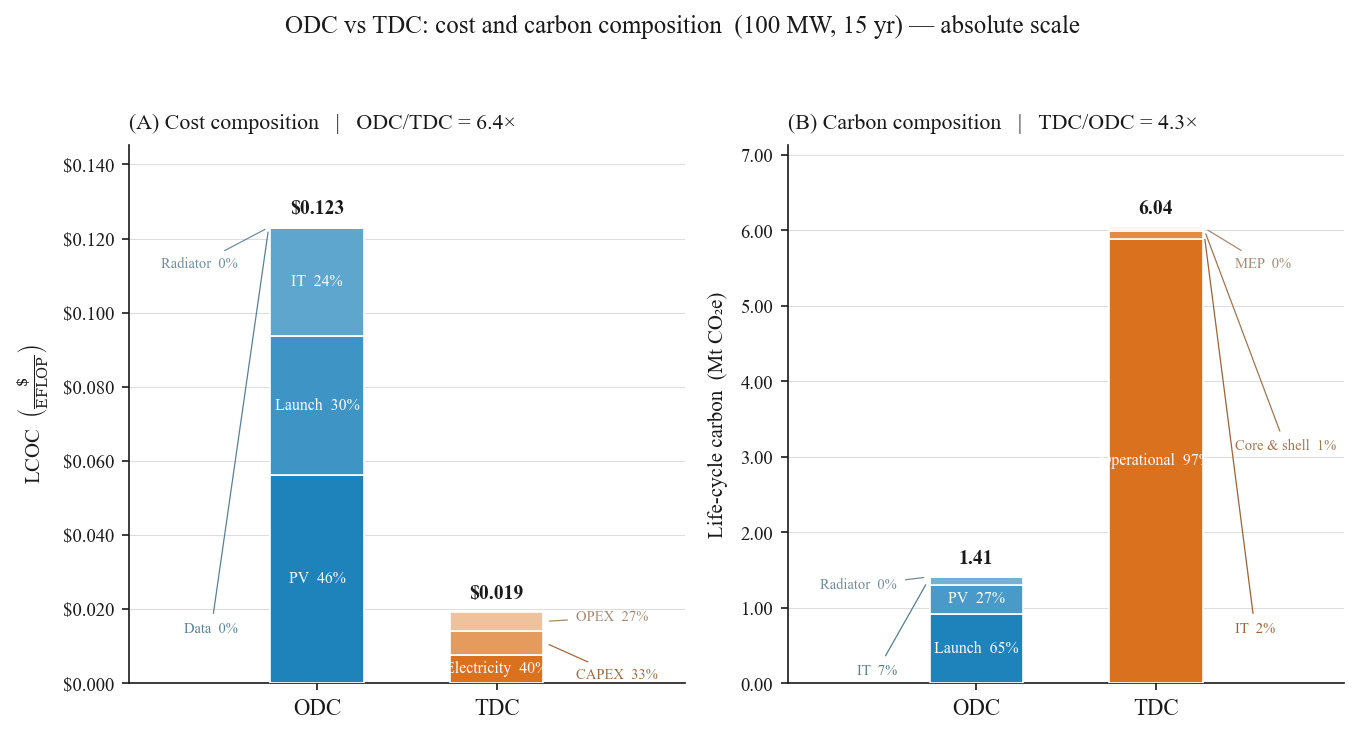

COST breakdown ($/EFLOP)
  ODC total = $0.1231
    PV           $0.0563  ( 45.8%)
    Launch       $0.0373  ( 30.3%)
    IT           $0.0292  ( 23.7%)
    Data         $0.0002  (  0.1%)
    Radiator     $0.0001  (  0.1%)
  TDC total = $0.0194
    Electricity  $0.0078  ( 40.1%)
    CAPEX        $0.0063  ( 32.6%)
    OPEX         $0.0053  ( 27.3%)
  ODC/TDC = 6.4x

CARBON breakdown (MtCO2e)
  ODC total = 1.412 Mt
    Launch           0.925 Mt  ( 65.5%)
    PV               0.378 Mt  ( 26.8%)
    IT               0.103 Mt  (  7.3%)
    Radiator         0.006 Mt  (  0.4%)
  TDC total = 6.042 Mt
    Operational      5.887 Mt  ( 97.4%)
    IT               0.103 Mt  (  1.7%)
    Core & shell     0.033 Mt  (  0.5%)
    MEP              0.020 Mt  (  0.3%)
  TDC/ODC = 4.3x


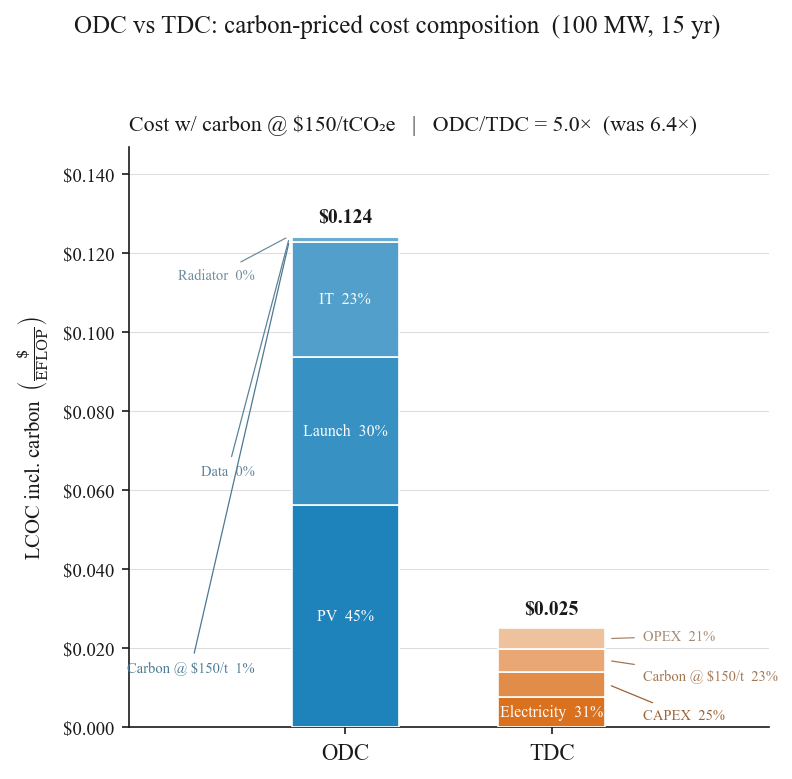

Carbon @ $150/tCO2e
  ODC adder $0.0013/EFLOP  on 1.41 Mt
  TDC adder $0.0057/EFLOP  on 6.04 Mt
  ODC total $0.1244  |  TDC total $0.0251
  ODC/TDC = 4.96x  (was 6.35x at $0)

ODC/TDC cost ratio vs carbon price:
  $   0/t : 6.35x
  $  50/t : 5.80x
  $ 100/t : 5.34x
  $ 150/t : 4.96x
  $ 250/t : 4.33x
  $ 500/t : 3.32x


In [50]:
# =============================================================================
# REGENERATED: the cost + life-cycle carbon COMPOSITION cell (defines odc_cost,
# tdc_cost, odc_carbon_comp, tdc_carbon_comp and draws the two-panel bar figure).
# This is the cell you deleted; paste it back in its original spot.
#
# DEPENDS ON (must have been run first):
#   - cell 18  -> style vars BG, INK, GRID, FONT, ODC_COLOR, TDC_COLOR
#   - cell 5   -> BASELINE
#   - cell 9/11-> mass_budget, annual_eflop, Q_COMPUTE, LIFETIME_YR, HOURS_PER_YEAR, SECONDS_PER_YEAR
#   - cell 32  -> odc_carbon_result, tdc_carbon_result
# The carbon-price figure (cell33_carbon_price_figure.py) appends AFTER this.
# =============================================================================
# =============================================================================
# Side-by-side composition: cost ($/EFLOP) and life-cycle carbon (MtCO2e)
# ABSOLUTE y-axis per panel (cost in $/EFLOP, carbon in MtCO2e -- different units,
# different axes). Each stacked bar shows the real magnitude; the % share of every
# component is printed inside its segment (or beside thin segments). ODC/TDC ratio
# annotated in the panel title.
# =============================================================================
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

def _shades(base, n, lo=0.12, hi=0.62):
    rgb = np.array(mcolors.to_rgb(base))
    return [tuple(rgb * (1 - f) + f) for f in np.linspace(lo, hi, n)]

def _ink_for(rgb):
    lum = 0.299*rgb[0] + 0.587*rgb[1] + 0.114*rgb[2]
    return INK if lum > 0.6 else 'white'


# ---- Cost breakdown ($/EFLOP), financial model ------------------------------
mb_f     = mass_budget(BASELINE)
years_f  = np.arange(LIFETIME_YR)
disc_f   = 1.0 / (1 + BASELINE.discount_rate) ** years_f
npv_comp = (annual_eflop(BASELINE) * disc_f).sum()

cost_PV   = mb_f['A_PV']  * BASELINE.pv_areal_cost
cost_rad  = mb_f['A_rad'] * BASELINE.rad_areal_cost
cost_IT   = (Q_COMPUTE / 1e6) * BASELINE.it_cost_per_MW
launch0   = mb_f['Total'] * BASELINE.launch_cost_per_kg
launch_rf = mb_f['IT']    * BASELINE.launch_cost_per_kg
drop_cost = BASELINE.data_fixed_cost + BASELINE.data_mass_per_drop * BASELINE.launch_cost_per_kg

def _cf(year0, refresh=0.0):
    cf = np.zeros(LIFETIME_YR); cf[0] = year0
    for ry in (5, 10): cf[ry] += refresh
    return cf

odc_cost = {
    'Launch':   (_cf(launch0, launch_rf) * disc_f).sum() / npv_comp,
    'IT':       (_cf(cost_IT, cost_IT)   * disc_f).sum() / npv_comp,
    'PV':       (_cf(cost_PV)            * disc_f).sum() / npv_comp,
    'Radiator': (_cf(cost_rad)           * disc_f).sum() / npv_comp,
    'Data':     (np.full(LIFETIME_YR, drop_cost * BASELINE.data_drops_per_year)
                 * disc_f).sum() / npv_comp,
}

def _tdc_cost_breakdown(gamma, c=10_000, d=0.10, pue=1.12, p=150, r=0.10, n=15, k=1.0):
    annual_elec = pue * (p / 1000) * k * HOURS_PER_YEAR
    annual_opex = d * c
    annual_comp = gamma * k * SECONDS_PER_YEAR
    df = 1.0 / (1 + r) ** np.arange(n)
    npc = (annual_comp * df).sum()
    return {
        'CAPEX':       c / npc * 1000,
        'OPEX':        (annual_opex * df).sum() / npc * 1000,
        'Electricity': (annual_elec * df).sum() / npc * 1000,
    }
tdc_cost = _tdc_cost_breakdown(BASELINE.gamma_PFLOPS_per_kW)


# ---- Carbon breakdown (Mt CO2e), carbon model -------------------------------
odc_carbon_comp = {
    'Launch':   odc_carbon_result['launch_total']                  / 1e6,
    'IT':       odc_carbon_result['breakdown']['IT (all gens)']    / 1e6,
    'PV':       odc_carbon_result['breakdown']['PV array']         / 1e6,
    'Radiator': odc_carbon_result['breakdown']['Radiator']         / 1e6,
}
tdc_carbon_comp = {
    'Operational':  tdc_carbon_result['operational_total']         / 1e6,
    'IT':           tdc_carbon_result['breakdown']['IT (all gens)']/ 1e6,
    'Core & shell': tdc_carbon_result['breakdown']['Core & shell'] / 1e6,
    'MEP':          tdc_carbon_result['breakdown']['MEP']          / 1e6,
}


# ---- drawing: ABSOLUTE stacked bars, % share labelled -----------------------
def _compose_panel(ax, odc_parts, tdc_parts, ylabel, title, yfmt):
    totals = {0: sum(odc_parts.values()), 1: sum(tdc_parts.values())}
    ymax   = max(totals.values()) * 1.18
    thresh = 0.05 * ymax                       # min segment height for an inside label

    for x, (parts, base) in zip((0, 1), [(odc_parts, ODC_COLOR), (tdc_parts, TDC_COLOR)]):
        items = sorted(parts.items(), key=lambda kv: kv[1], reverse=True)
        total = totals[x]
        cols  = _shades(base, len(items))
        bottom = 0.0
        side = []                              # (y_mid, text, color) for thin segments
        for (lab, val), col in zip(items, cols):
            share = val / total
            ax.bar(x, val, bottom=bottom, width=0.52, color=col,
                   edgecolor=BG, linewidth=0.8, zorder=3)
            ymid = bottom + val / 2
            txt = f'{lab}  {share*100:.0f}%'
            if val >= thresh:
                ax.text(x, ymid, txt, ha='center', va='center', fontsize=7.6,
                        color=_ink_for(col), fontfamily=FONT, zorder=4)
            else:
                side.append((ymid, txt, tuple(np.array(mcolors.to_rgb(col)) * 0.7)))
            bottom += val
        # thin-segment labels stacked just outside the bar, with leader lines;
        # ODC (x=0) labels go LEFT, TDC (x=1) labels go RIGHT, to keep the centre clear
        if side:
            if x == 0:
                x_txt, x_arr, ha = x - 0.44, x - 0.27, 'right'
            else:
                x_txt, x_arr, ha = x + 0.44, x + 0.27, 'left'
            ys = np.linspace(total * 0.12, total * 0.92, len(side))
            for (ymid, txt, col), y_lab in zip(side, ys):
                ax.annotate(txt, xy=(x_arr, ymid), xytext=(x_txt, y_lab),
                            ha=ha, va='center', fontsize=7.0, color=col,
                            fontfamily=FONT, zorder=5,
                            arrowprops=dict(arrowstyle='-', color=col, lw=0.6))
        ax.text(x, total + ymax * 0.015, yfmt(total), ha='center', va='bottom',
                fontsize=9.5, color=INK, fontfamily=FONT, fontweight='bold', zorder=6)

    ax.set_xlim(-1.05, 2.05); ax.set_ylim(0, ymax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['ODC', 'TDC'])
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.set_facecolor(BG)
    for sdn in ('top', 'right'): ax.spines[sdn].set_visible(False)
    for sdn in ('left', 'bottom'):
        ax.spines[sdn].set_color(INK); ax.spines[sdn].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    plt.setp(ax.get_xticklabels(), fontfamily=FONT, color=INK, fontsize=11)
    plt.setp(ax.get_yticklabels(), fontfamily=FONT, color=INK)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)


cost_ratio   = sum(odc_cost.values())        / sum(tdc_cost.values())
carbon_ratio = sum(tdc_carbon_comp.values()) / sum(odc_carbon_comp.values())

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.2, 4.9))
fig.patch.set_facecolor(BG)

_compose_panel(axL, odc_cost, tdc_cost,
               ylabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
               title=f'(A) Cost composition   |   ODC/TDC = {cost_ratio:.1f}×',
               yfmt=lambda v: f'${v:.3f}')

_compose_panel(axR, odc_carbon_comp, tdc_carbon_comp,
               ylabel='Life-cycle carbon  (Mt CO₂e)',
               title=f'(B) Carbon composition   |   TDC/ODC = {carbon_ratio:.1f}×',
               yfmt=lambda v: f'{v:.2f}')

fig.suptitle('ODC vs TDC: cost and carbon composition  (100 MW, 15 yr) — absolute scale',
             fontsize=12, color=INK, fontfamily=FONT, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('cost_carbon_composition.pdf')
fig.savefig('cost_carbon_composition.png')
plt.show()


# ---- exact numbers (for the text / SI) --------------------------------------
print("COST breakdown ($/EFLOP)")
for name, parts in [('ODC', odc_cost), ('TDC', tdc_cost)]:
    tot = sum(parts.values())
    print(f"  {name} total = ${tot:.4f}")
    for k, v in sorted(parts.items(), key=lambda kv: kv[1], reverse=True):
        print(f"    {k:<12} ${v:.4f}  ({v/tot*100:5.1f}%)")
print(f"  ODC/TDC = {cost_ratio:.1f}x\n")

print("CARBON breakdown (MtCO2e)")
for name, parts in [('ODC', odc_carbon_comp), ('TDC', tdc_carbon_comp)]:
    tot = sum(parts.values())
    print(f"  {name} total = {tot:.3f} Mt")
    for k, v in sorted(parts.items(), key=lambda kv: kv[1], reverse=True):
        print(f"    {k:<14} {v:7.3f} Mt  ({v/tot*100:5.1f}%)")
print(f"  TDC/ODC = {carbon_ratio:.1f}x")
CARBON_PRICE = 150.0   # $/tCO2e

_odc_carbon_Mt = sum(odc_carbon_comp.values())
_tdc_carbon_Mt = sum(tdc_carbon_comp.values())

def _carbon_adder_per_eflop(total_Mt):
    """Lifecycle carbon (MtCO2e) -> $/EFLOP at CARBON_PRICE, using the cost
    panel's NPV-compute denominator so it stacks on the same axis."""
    return (total_Mt * 1e6 * CARBON_PRICE) / npv_comp

_clab = f'Carbon @ ${CARBON_PRICE:.0f}/t'
odc_cost_cp = {**odc_cost, _clab: _carbon_adder_per_eflop(_odc_carbon_Mt)}
tdc_cost_cp = {**tdc_cost, _clab: _carbon_adder_per_eflop(_tdc_carbon_Mt)}

ratio_before = sum(odc_cost.values())    / sum(tdc_cost.values())
ratio_after  = sum(odc_cost_cp.values()) / sum(tdc_cost_cp.values())

fig2, ax2 = plt.subplots(1, 1, figsize=(5.4, 5.2))
fig2.patch.set_facecolor(BG)
_compose_panel(
    ax2, odc_cost_cp, tdc_cost_cp,
    ylabel=r'LCOC incl. carbon  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
    title=(f'Cost w/ carbon @ ${CARBON_PRICE:.0f}/tCO\u2082e   |   '
           f'ODC/TDC = {ratio_after:.1f}\u00d7  (was {ratio_before:.1f}\u00d7)'),
    yfmt=lambda v: f'${v:.3f}',
)
fig2.suptitle('ODC vs TDC: carbon-priced cost composition  (100 MW, 15 yr)',
              fontsize=12, color=INK, fontfamily=FONT, y=0.99)
fig2.tight_layout(rect=[0, 0, 1, 0.95])
fig2.savefig('cost_carbon_priced.pdf')
fig2.savefig('cost_carbon_priced.png')
plt.show()

# ---- numbers + a quick price sweep (relative idea across prices) ------------
print(f'Carbon @ ${CARBON_PRICE:.0f}/tCO2e')
print(f'  ODC adder ${_carbon_adder_per_eflop(_odc_carbon_Mt):.4f}/EFLOP  on {_odc_carbon_Mt:.2f} Mt')
print(f'  TDC adder ${_carbon_adder_per_eflop(_tdc_carbon_Mt):.4f}/EFLOP  on {_tdc_carbon_Mt:.2f} Mt')
print(f'  ODC total ${sum(odc_cost_cp.values()):.4f}  |  TDC total ${sum(tdc_cost_cp.values()):.4f}')
print(f'  ODC/TDC = {ratio_after:.2f}x  (was {ratio_before:.2f}x at $0)\n')

print('ODC/TDC cost ratio vs carbon price:')
for cp in (0, 50, 100, 150, 250, 500):
    o = sum(odc_cost.values()) + (_odc_carbon_Mt * 1e6 * cp) / npv_comp
    t = sum(tdc_cost.values()) + (_tdc_carbon_Mt * 1e6 * cp) / npv_comp
    print(f'  ${cp:>4}/t : {o/t:.2f}x')

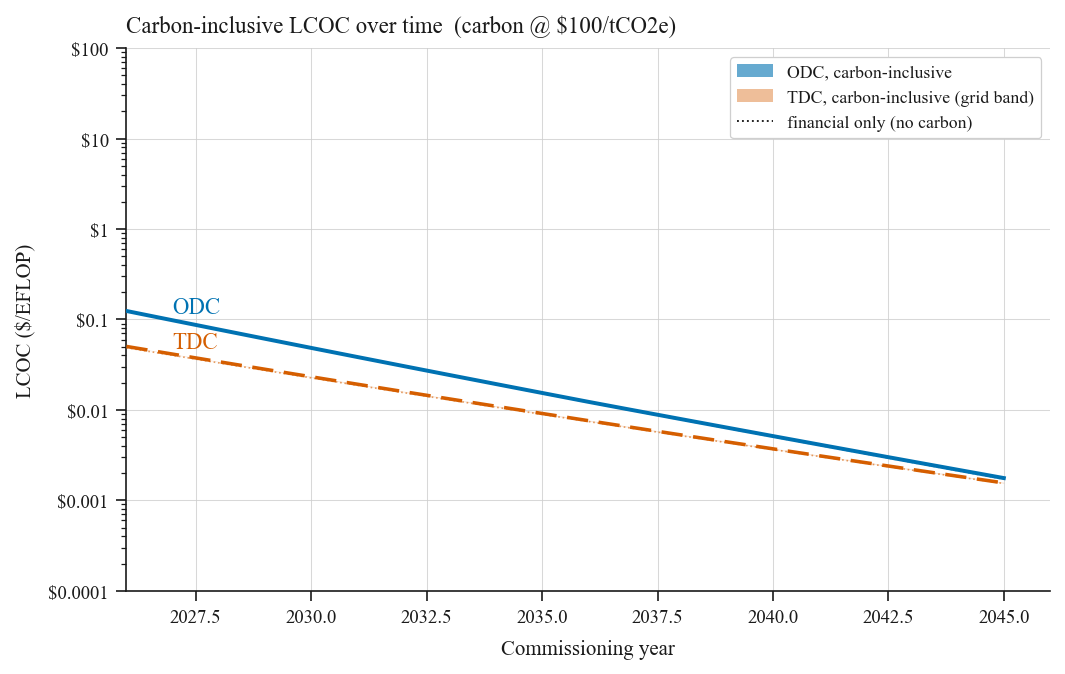

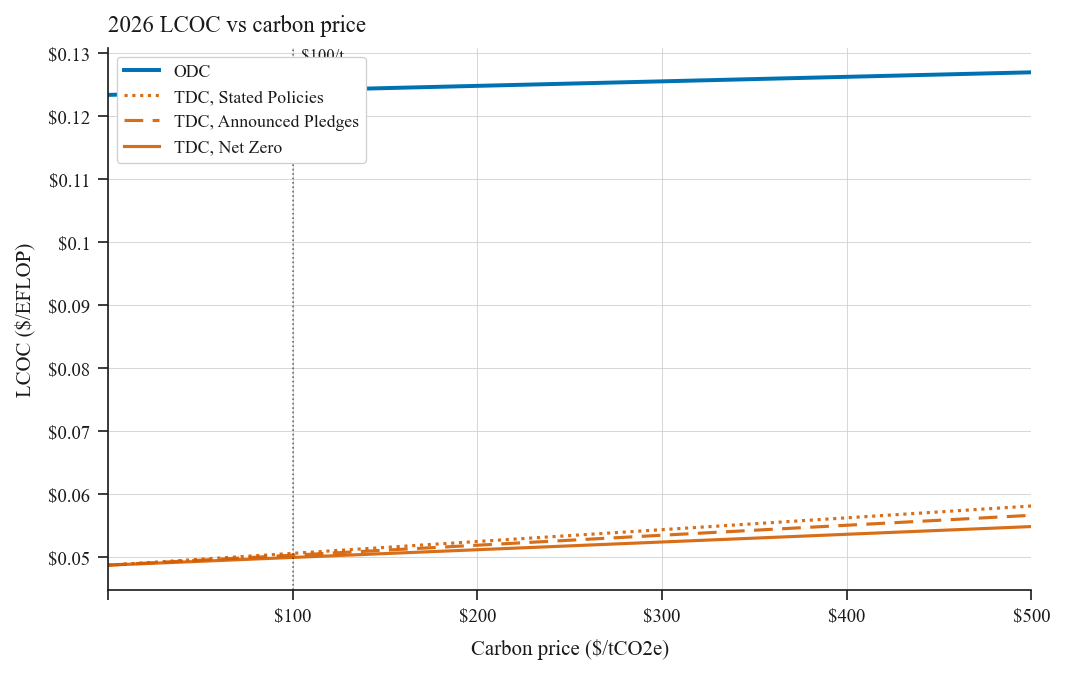

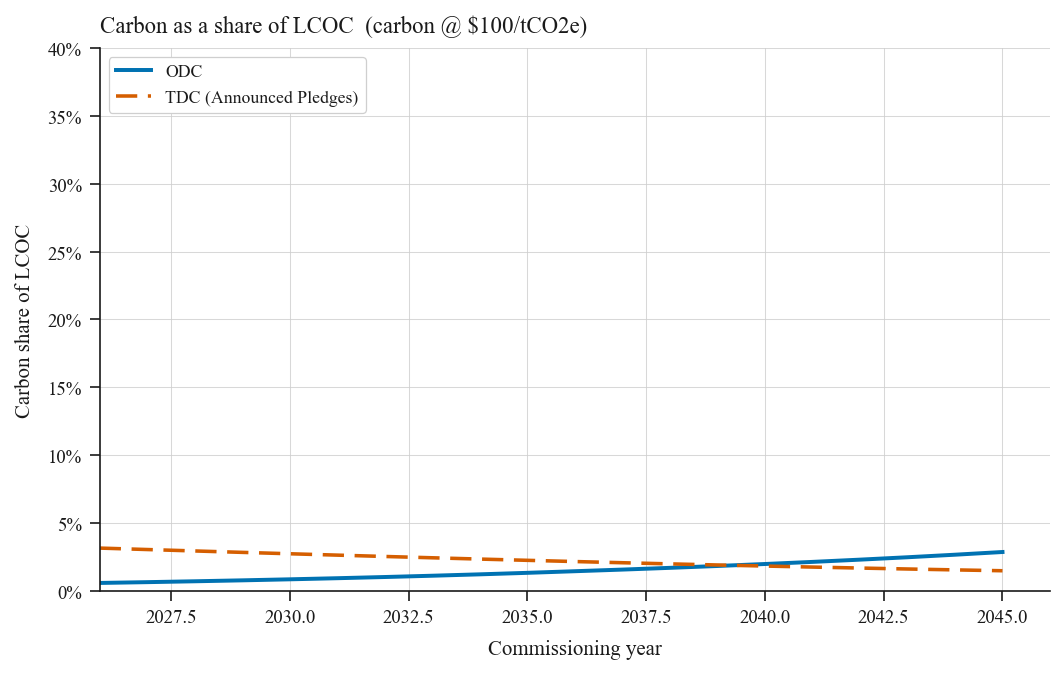

Carbon price $100/tCO2e | forcing mult 1

2026:
  ODC  fin $0.1234  +carbon $0.0007  = $0.1241  (carbon 1%)
  TDC  Stated Policies   $0.0487  +carbon $0.0019  = $0.0506  (carbon 4%)
  TDC  Announced Pledges $0.0487  +carbon $0.0016  = $0.0503  (carbon 3%)
  TDC  Net Zero          $0.0487  +carbon $0.0012  = $0.0500  (carbon 2%)

2045:
  ODC  fin $0.0017  +carbon $0.0001  = $0.0018  (carbon 3%)
  TDC  Stated Policies   $0.0015  +carbon $0.0001  = $0.0016  (carbon 3%)
  TDC  Announced Pledges $0.0015  +carbon $0.0000  = $0.0016  (carbon 1%)
  TDC  Net Zero          $0.0015  +carbon $0.0000  = $0.0015  (carbon 1%)



In [51]:
# ============================================================================
# Carbon-inclusive LCOC over time
# LCOC_total = LCOC_financial + (NPV carbon cost)/(NPV compute).
# Financial side held at BASELINE learning rates (reuses odc_nom / tdc_nom).
# New axes: grid decarbonization scenario (TDC only) and carbon price.
# ============================================================================

# ---- assumptions (edit here) ------------------------------------------------
GRID_2026          = 0.446    # tCO2e/MWh, IEA WEO 2025 global avg (446 gCO2/kWh)
BASE_CARBON_PRICE  = 100.0    # $/tCO2e (EPA 2023 social cost of carbon, central)
CARBON_PRICE_GROWTH = 0.0     # real %/yr (0 = flat real price)
ODC_FORCING_MULT   = 1.0      # >1 tests high-altitude underestimate (Dominguez 2024)

# IEA WEO 2025 scenarios as annual grid-intensity decline rates, fitted to the
# 2024->2040 endpoints in the figure. Affects TDC only (ODC is grid-independent).
GRID_SCENARIOS = {
    'Stated Policies':   0.05,   # slow decarb  (keeps TDC dirty -> favours ODC)
    'Announced Pledges': 0.09,   # central
    'Net Zero':          0.16,   # fast decarb  (hardest on ODC's relative case)
}

def carbon_price(cal_year):
    return BASE_CARBON_PRICE * (1 + CARBON_PRICE_GROWTH) ** (cal_year - START_YEAR)

# ---- shared discounting / compute -------------------------------------------
R    = BASELINE.discount_rate
disc = 1.0 / (1 + R) ** np.arange(LIFETIME_YR)

# NPV of compute (EFLOP) for a system commissioned at each offset (gamma grows)
npv_compute = np.array([
    (annual_eflop(evolve_scenario(BASELINE, yo, LR_BASELINE)) * disc).sum()
    for yo in year_offsets
])

def _price_vec(Y):
    return np.array([carbon_price(Y + i) for i in range(LIFETIME_YR)])

# ---- ODC carbon adder (grid-independent; emissions fixed over calendar time)--
_op = odc_carbon_result['profile']
odc_annual_t = (np.array(_op['embodied_spike'])
                + ODC_FORCING_MULT * np.array(_op['launch_spike']))   # tCO2e/yr

odc_carbon_adder = np.array([
    (odc_annual_t * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
    for k, yo in enumerate(year_offsets)
])

# ---- TDC carbon adder (per grid scenario) -----------------------------------
def _tdc_annual(yo, decarb):
    g0 = GRID_2026 * (1 - decarb) ** yo          # grid at commissioning
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=g0, grid_decarb=decarb))
    return np.array(tc['profile']['embodied_spike']) + np.array(tc['profile']['operational'])

tdc_carbon_adder = {}
for name, decarb in GRID_SCENARIOS.items():
    tdc_carbon_adder[name] = np.array([
        (_tdc_annual(yo, decarb) * _price_vec(START_YEAR + yo) * disc).sum() / npv_compute[k]
        for k, yo in enumerate(year_offsets)
    ])

# ---- carbon-inclusive LCOC --------------------------------------------------
odc_ci = odc_nom + odc_carbon_adder
tdc_ci = {name: tdc_nom + add for name, add in tdc_carbon_adder.items()}


# ============================== FIGURE 1 =====================================
# Carbon-inclusive LCOC over time; TDC band spans grid scenarios.
fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.fill_between(years_calendar, tdc_ci['Net Zero'], tdc_ci['Stated Policies'],
                color=TDC_COLOR, alpha=0.15, zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_ci['Announced Pledges'], color=TDC_COLOR,
        lw=1.7, ls=(0, (6, 3)), zorder=4)
ax.plot(years_calendar, odc_ci, color=ODC_COLOR, lw=1.9, zorder=5)

# financial-only references (no carbon)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, lw=0.8, ls=':', alpha=0.6, zorder=3)

ax.text(2027, odc_ci[0]*1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
ax.text(2027, tdc_ci['Announced Pledges'][0]*1.12, 'TDC', color=TDC_COLOR,
        fontfamily=FONT, fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.6, label='ODC, carbon-inclusive'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.4, label='TDC, carbon-inclusive (grid band)'),
    plt.Line2D([0],[0], color=INK, ls=':', lw=0.9, label='financial only (no carbon)'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=1.0,
                edgecolor=GRID, facecolor='white', fontsize=8.5,
                prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title=f'Carbon-inclusive LCOC over time  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='LCOC ($/EFLOP)',
           xlim=(2026, 2046), ylim=(0.0001, 100))
plt.tight_layout()
fig.savefig('lcoc_carbon_over_time.pdf'); fig.savefig('lcoc_carbon_over_time.png')
plt.show()


# ============================== FIGURE 2 =====================================
# 2026 snapshot: how carbon price moves LCOC (linear in price).
prices = np.linspace(0, 500, 200)
odc_coeff = (odc_annual_t * disc).sum() / npv_compute[0]
odc_sweep = odc_nom[0] + prices * odc_coeff

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(prices, odc_sweep, color=ODC_COLOR, lw=1.9, label='ODC')

tdc_styles = {'Stated Policies': (0,(1,1.5)), 'Announced Pledges': (0,(6,3)), 'Net Zero': 'solid'}
for name, decarb in GRID_SCENARIOS.items():
    coeff = (_tdc_annual(0, decarb) * disc).sum() / npv_compute[0]
    ax.plot(prices, tdc_nom[0] + prices*coeff, color=TDC_COLOR, lw=1.5,
            ls=tdc_styles[name], alpha=0.9, label=f'TDC, {name}')

ax.axvline(BASE_CARBON_PRICE, color=INK, lw=0.8, ls=':', alpha=0.6)
ax.text(BASE_CARBON_PRICE, ax.get_ylim()[1], f'  ${BASE_CARBON_PRICE:.0f}/t',
        color=INK, fontfamily=FONT, fontsize=8, va='top')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig, title='2026 LCOC vs carbon price',
           xlabel='Carbon price ($/tCO2e)', ylabel='LCOC ($/EFLOP)',
           y_log=False, x_dollar=True, xlim=(0, 500))
plt.tight_layout()
fig.savefig('lcoc_vs_carbon_price_2026.pdf'); fig.savefig('lcoc_vs_carbon_price_2026.png')
plt.show()


# ============================== FIGURE 3 =====================================
# Carbon as a share of total LCOC over time.
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(years_calendar, 100*odc_carbon_adder/odc_ci, color=ODC_COLOR, lw=1.9, label='ODC')
ax.plot(years_calendar, 100*tdc_carbon_adder['Announced Pledges']/tdc_ci['Announced Pledges'],
        color=TDC_COLOR, lw=1.7, ls=(0,(6,3)), label='TDC (Announced Pledges)')

leg = ax.legend(loc='upper left', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
style_axes(ax, fig, title=f'Carbon as a share of LCOC  (carbon @ ${BASE_CARBON_PRICE:.0f}/tCO2e)',
           xlabel='Commissioning year', ylabel='Carbon share of LCOC',
           y_log=False, y_dollar=False, xlim=(2026, 2046))
ax.set_ylim(0, max(40, 1.15*100*np.max(tdc_carbon_adder['Stated Policies']/tdc_ci['Stated Policies'])))
plt.tight_layout()
fig.savefig('carbon_share_over_time.pdf'); fig.savefig('carbon_share_over_time.png')
plt.show()


# ---- quick numeric readout --------------------------------------------------
print(f"Carbon price ${BASE_CARBON_PRICE:.0f}/tCO2e | forcing mult {ODC_FORCING_MULT:g}\n")
for label, k in [('2026', 0), ('2045', 19)]:
    print(f"{label}:")
    print(f"  ODC  fin ${odc_nom[k]:.4f}  +carbon ${odc_carbon_adder[k]:.4f}"
          f"  = ${odc_ci[k]:.4f}  (carbon {100*odc_carbon_adder[k]/odc_ci[k]:.0f}%)")
    for name in GRID_SCENARIOS:
        print(f"  TDC  {name:<17} ${tdc_nom[k]:.4f}  +carbon ${tdc_carbon_adder[name][k]:.4f}"
              f"  = ${tdc_ci[name][k]:.4f}  (carbon {100*tdc_carbon_adder[name][k]/tdc_ci[name][k]:.0f}%)")
    print()

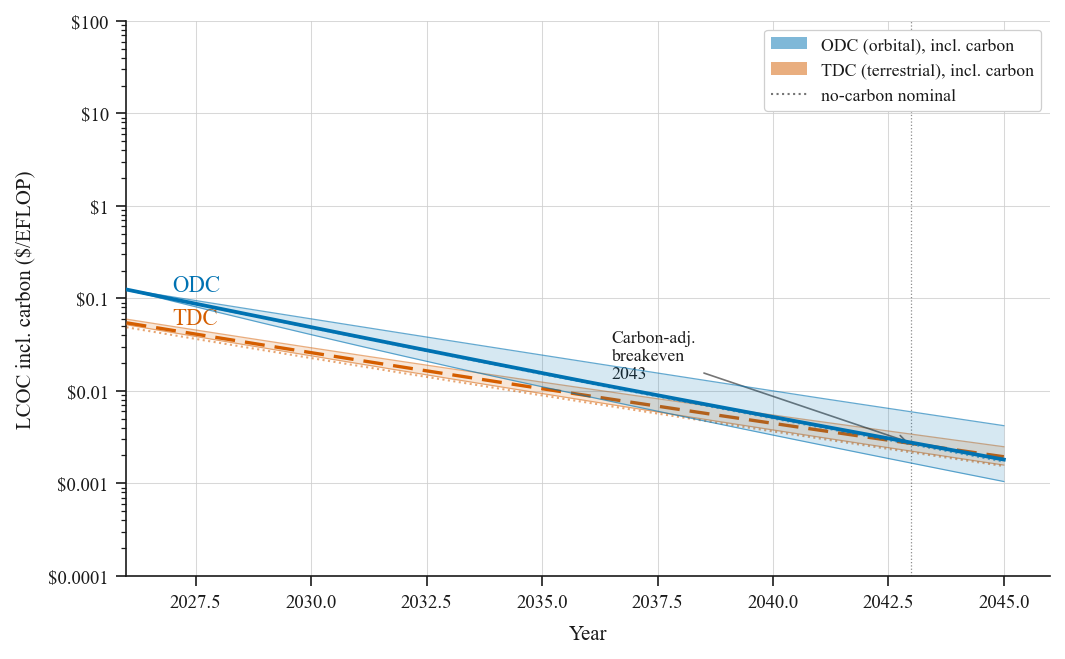

Carbon price: $150/tCO2e   (lifecycle: ODC 1.41 Mt, TDC 6.04 Mt, held at baseline)

  Year   ODC base    ODC +C    dODC    TDC base    TDC +C    dTDC
  2026  $  0.1234 $  0.1248    1.1%   $  0.0487 $  0.0545   11.7%
  2045  $  0.0017 $  0.0018    5.5%   $  0.0015 $  0.0019   26.2%

ODC/TDC nominal ratio:  2026 2.29x   2045 0.93x  (cost-only 2045 was 1.12x)
Note: % rises toward 2045 because carbon is held fixed while costs fall; grid decarbonisation / lighter launches would reduce the 2045 figures.


In [52]:
# =============================================================================
# LCOC over time WITH a carbon price (companion to the cost-only band chart).
# Adds a per-year carbon charge to every band edge:
#     carbon adder [$/EFLOP] = lifecycle carbon [tCO2e] * CARBON_PRICE / NPV_compute(year)
# The adder is the SAME for optimistic/baseline/pessimistic at a given year, so
# the learning-rate band gap is preserved exactly (a uniform vertical shift).
#
# Requires (run first): cell 16 (the *_nom/_hi/_lo bands, years_calendar,
# evolve_scenario, BASELINE, LR_BASELINE, annual_eflop, LIFETIME_YR) and cell 32
# (odc_carbon_result, tdc_carbon_result, both with a 'total' in tCO2e).
#
# CAVEAT (flag for the PI): lifecycle carbon is held at the baseline footprint
# for every build-year. Because raw costs fall over time while carbon is held
# fixed, the % impact RISES toward 2045. Two real effects would pull the 2045
# numbers back down and are NOT modelled here: ODC launch carbon falling as IT
# gets lighter, and TDC operational carbon falling if the grid decarbonises
# (the TDC number is dominated by grid intensity, held at today's 0.40 tCO2e/MWh).
# =============================================================================
import matplotlib.patches as mpatches
CARBON_PRICE = 150.0   # $/tCO2e

# lifecycle carbon totals (tCO2e) from the carbon model
odc_C = odc_carbon_result['total']
tdc_C = tdc_carbon_result['total']

# NPV of lifetime compute for a DC built in each calendar year (gamma growth is
# the same across scenarios, so this is scenario-independent).
disc_f = 1.0 / (1 + BASELINE.discount_rate) ** np.arange(LIFETIME_YR)
def _compute_npv(yo):
    ev = evolve_scenario(BASELINE, yo, LR_BASELINE)
    return float((annual_eflop(ev) * disc_f).sum())
cnpv = np.array([_compute_npv(yo) for yo in year_offsets])

odc_adder = odc_C * CARBON_PRICE / cnpv      # $/EFLOP, per year
tdc_adder = tdc_C * CARBON_PRICE / cnpv

# carbon-inclusive bands (uniform shift -> band gap preserved)
odc_nom_c, odc_hi_c, odc_lo_c = odc_nom + odc_adder, odc_hi + odc_adder, odc_lo + odc_adder
tdc_nom_c, tdc_hi_c, tdc_lo_c = tdc_nom + tdc_adder, tdc_hi + tdc_adder, tdc_lo + tdc_adder

# =============================================================================
# Figure
# =============================================================================
fig, ax = plt.subplots(figsize=(7.2, 4.5))

# TDC band (carbon-inclusive)
ax.fill_between(years_calendar, tdc_lo_c, tdc_hi_c, color=TDC_COLOR, alpha=0.15,
                zorder=2, linewidth=0)
ax.plot(years_calendar, tdc_hi_c, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_lo_c, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
ax.plot(years_calendar, tdc_nom_c, color=TDC_COLOR, linewidth=1.6,
        linestyle=(0, (6, 3)), zorder=4)

# ODC band (carbon-inclusive)
ax.fill_between(years_calendar, odc_lo_c, odc_hi_c, color=ODC_COLOR, alpha=0.16,
                zorder=5, linewidth=0)
ax.plot(years_calendar, odc_hi_c, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_lo_c, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
ax.plot(years_calendar, odc_nom_c, color=ODC_COLOR, linewidth=1.8, zorder=7)

# faint no-carbon nominal lines for reference (shows the carbon shift)
ax.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=1.0, ls=':', alpha=0.55, zorder=6)
ax.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=1.0, ls=':', alpha=0.55, zorder=4)

# Crossover on the carbon-inclusive baseline curves
diff = odc_nom_c - tdc_nom_c
crosses = np.where(np.diff(np.sign(diff)))[0]
for cx in crosses:
    cy = (odc_nom_c[cx] + tdc_nom_c[cx]) / 2
    ax.axvline(years_calendar[cx], color=INK, linewidth=0.6, linestyle=':', alpha=0.5, zorder=2)
    ax.annotate(f'Carbon-adj.\nbreakeven\n{years_calendar[cx]}',
                xy=(years_calendar[cx], cy),
                xytext=(years_calendar[cx] - 6.5, cy * 5.0),
                fontsize=8.5, color=INK, fontfamily=FONT,
                arrowprops=dict(arrowstyle='->', color=INK, alpha=0.6, lw=0.8))

# End-of-line labels
ax.text(2027, odc_nom_c[0] * 1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
ax.text(2027, tdc_nom_c[0] * 1.12, 'TDC', color=TDC_COLOR, fontfamily=FONT, fontsize=11, va='center')

handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.5, label='ODC (orbital), incl. carbon'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.5, label='TDC (terrestrial), incl. carbon'),
    plt.Line2D([0], [0], color=INK, ls=':', lw=1.0, alpha=0.6, label='no-carbon nominal'),
]
leg = ax.legend(handles=handles, loc='upper right', frameon=True, framealpha=1.0,
                edgecolor=GRID, facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts():
    t.set_color(INK)

style_axes(ax, fig, title='', xlabel='Year',
           ylabel='LCOC incl. carbon ($/EFLOP)',
           xlim=(2026, 2046), ylim=(0.0001, 100))
plt.tight_layout()
# fig.savefig('lcoc_carbon_over_time.pdf'); fig.savefig('lcoc_carbon_over_time.png')
plt.show()

# =============================================================================
# Percent impact of the carbon price (vs no-carbon LCOC) at 2026 and 2045
# =============================================================================
print(f'Carbon price: ${CARBON_PRICE:.0f}/tCO2e   '
      f'(lifecycle: ODC {odc_C/1e6:.2f} Mt, TDC {tdc_C/1e6:.2f} Mt, held at baseline)\n')
print(f'{"Year":>6}  {"ODC base":>9} {"ODC +C":>9} {"dODC":>7}   {"TDC base":>9} {"TDC +C":>9} {"dTDC":>7}')
for idx, yr in [(0, 2026), (19, 2045)]:
    do = odc_adder[idx] / odc_nom[idx] * 100
    dt = tdc_adder[idx] / tdc_nom[idx] * 100
    print(f'{yr:>6}  ${odc_nom[idx]:>8.4f} ${odc_nom_c[idx]:>8.4f} {do:>6.1f}%   '
          f'${tdc_nom[idx]:>8.4f} ${tdc_nom_c[idx]:>8.4f} {dt:>6.1f}%')
print(f'\nODC/TDC nominal ratio:  2026 {odc_nom_c[0]/tdc_nom_c[0]:.2f}x   '
      f'2045 {odc_nom_c[19]/tdc_nom_c[19]:.2f}x  (cost-only 2045 was {odc_nom[19]/tdc_nom[19]:.2f}x)')
print('Note: % rises toward 2045 because carbon is held fixed while costs fall; '
      'grid decarbonisation / lighter launches would reduce the 2045 figures.')

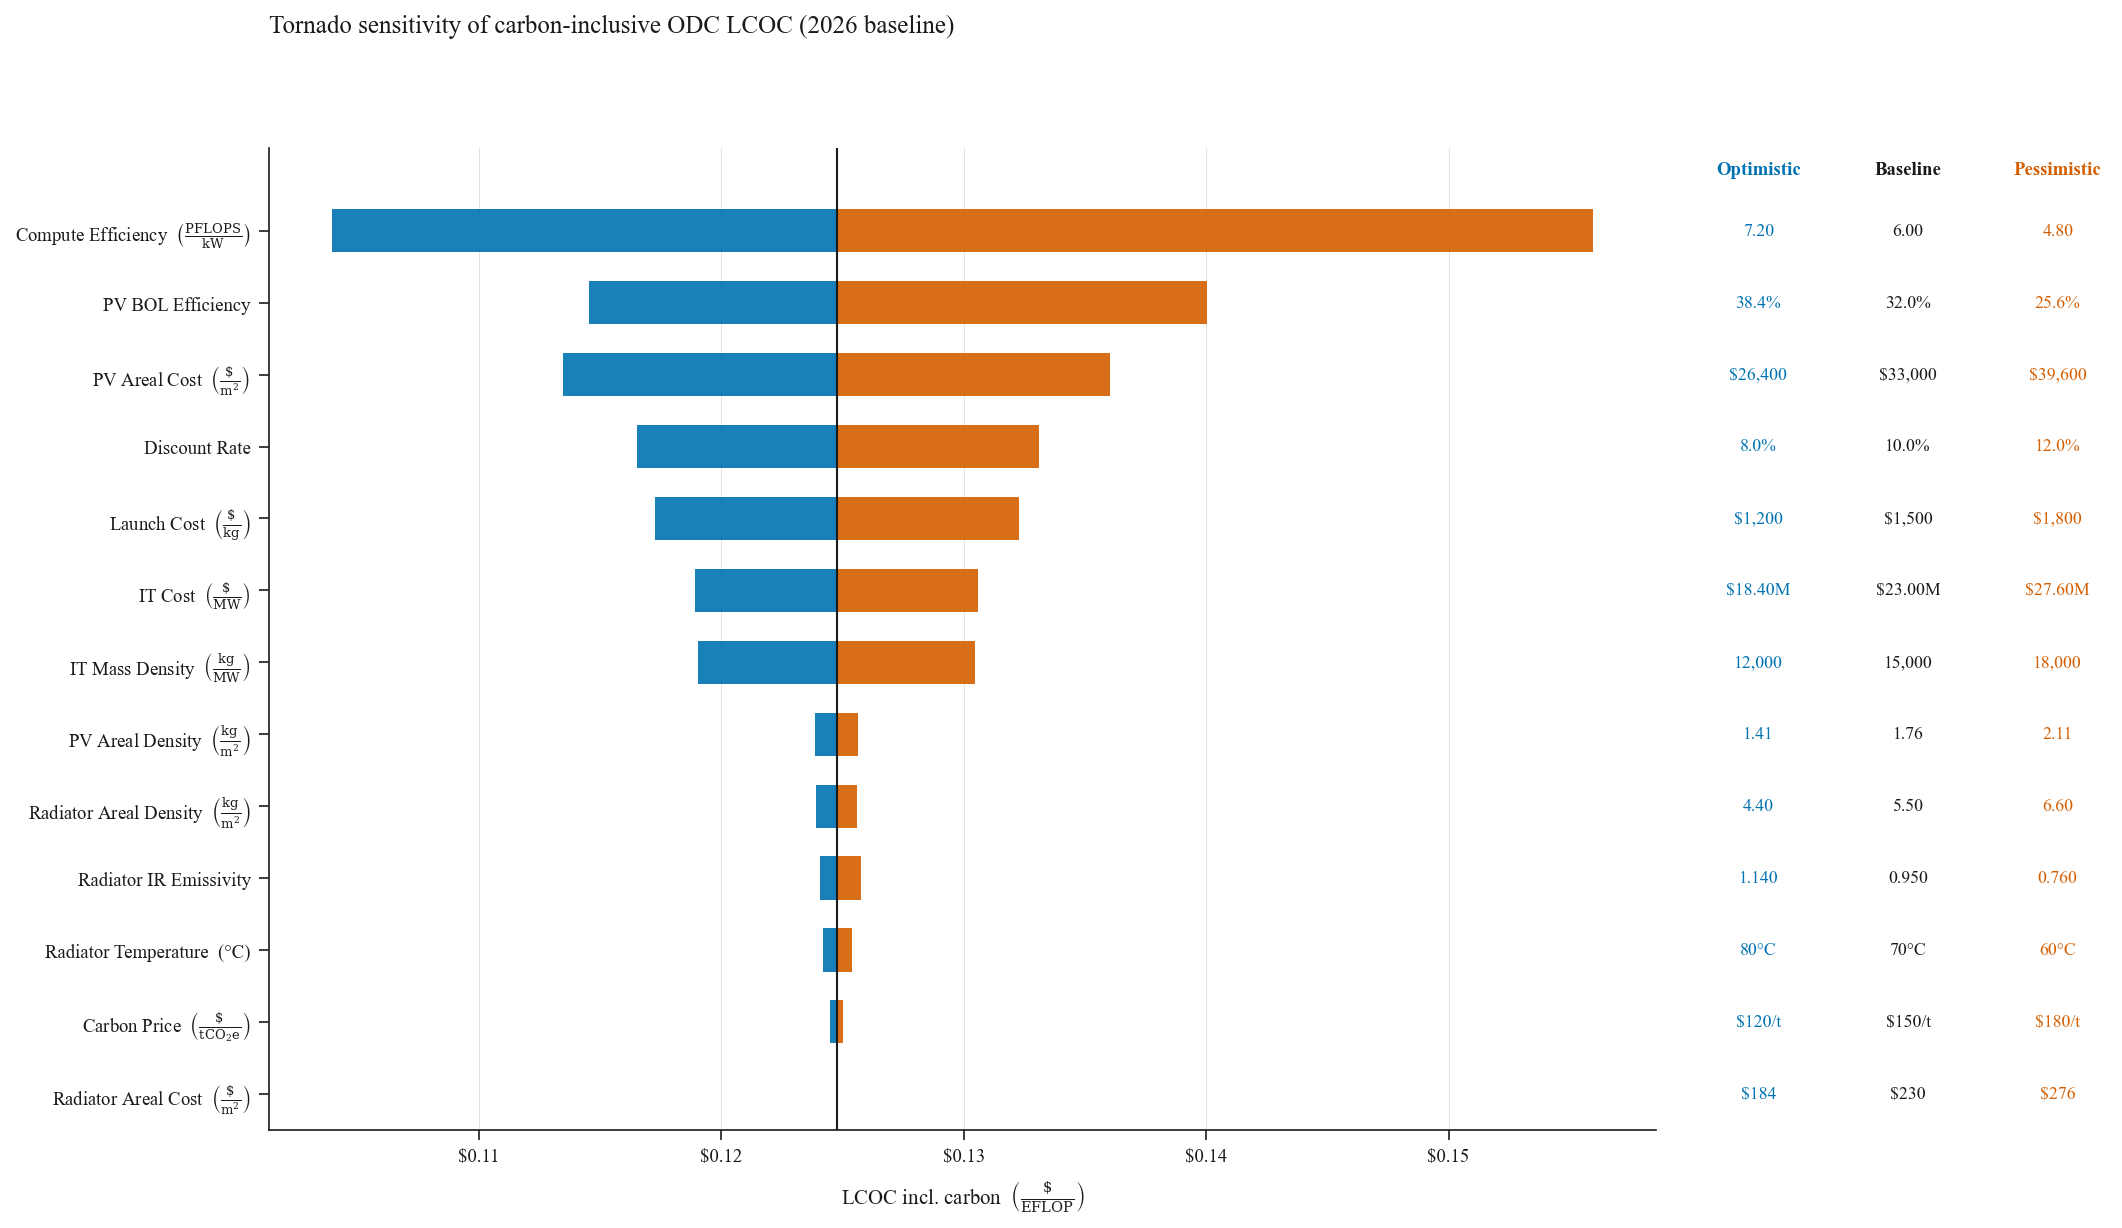

Carbon-inclusive baseline LCOC = $0.1248/EFLOP  (cost $0.1234 + carbon $0.0013 @ $150/t)

parameter                  swing $/EFLOP  % of base
Compute Efficiency                0.0520      41.7%
PV BOL Efficiency                 0.0255      20.4%
PV Areal Cost                     0.0226      18.1%
Discount Rate                     0.0166      13.3%
Launch Cost                       0.0150      12.0%
IT Cost                           0.0117       9.4%
IT Mass Density                   0.0114       9.2%
PV Areal Density                  0.0018       1.4%
Radiator Areal Density            0.0017       1.4%
Radiator IR Emissivity            0.0017       1.4%
Radiator Temperature              0.0012       0.9%
Carbon Price                      0.0005       0.4%
Radiator Areal Cost               0.0000       0.0%


In [53]:
# =============================================================================
# Tornado sensitivity of CARBON-INCLUSIVE ODC LCOC (2026 baseline)
# -----------------------------------------------------------------------------
# Built on the Optimistic/Baseline/Pessimistic cell: the two bounds are assigned
# by RESULTING LCOC (sort), so blue is always the better-LCOC side and the table
# value under each colour is the parameter value that produces it. Ranges kept
# as in that cell.
#
# LCOC here = cost LCOC + carbon charge, where
#     carbon charge [$/EFLOP] = ODC lifecycle carbon [tCO2e] * CARBON_PRICE / NPV_compute
# A new row varies CARBON_PRICE itself. The ODC carbon TOTAL is held at the
# baseline footprint (odc_carbon_result['total']); not recomputed per parameter,
# which is fine because the ODC carbon charge is ~1% of LCOC (negligible coupling).
#
# Requires: calculate_lcoc, annual_eflop, BASELINE, LIFETIME_YR, replace,
# odc_carbon_result, and style vars (ODC_COLOR, ACCENT_R, INK, GRID, FONT) + style_axes.
# =============================================================================
CARBON_PRICE       = 150.0          # $/tCO2e baseline
CARBON_PRICE_RANGE = (120, 180.0)  # low / high for the carbon-price tornado row
ODC_CARBON_T       = odc_carbon_result['total']   # tCO2e, baseline (held fixed)

_CARBON_ATTR = '__carbon_price__'

# Parameters to vary, with +/- range (ranges as in the kept cell)
PARAMS_TO_VARY = [
    ('Launch Cost  ' + r'$\left(\frac{\$}{\mathrm{kg}}\right)$',
     'launch_cost_per_kg', 0.20),
    ('Compute Efficiency  ' + r'$\left(\frac{\mathrm{PFLOPS}}{\mathrm{kW}}\right)$',
     'gamma_PFLOPS_per_kW', 0.20),
    ('IT Cost  ' + r'$\left(\frac{\$}{\mathrm{MW}}\right)$',
     'it_cost_per_MW', 0.20),
    ('PV Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'pv_areal_cost', 0.20),
    ('Carbon Price  ' + r'$\left(\frac{\$}{\mathrm{tCO_2e}}\right)$',
     _CARBON_ATTR, None, CARBON_PRICE_RANGE),
    ('IT Mass Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{MW}}\right)$',
     'it_mass_density', 0.20),
    ('PV Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'pv_areal_mass', 0.20),
    ('Radiator Areal Cost  ' + r'$\left(\frac{\$}{\mathrm{m}^{2}}\right)$',
     'rad_areal_cost', 0.20),
    ('Radiator Temperature  (\u00b0C)',
     'T_rad_C', None, (60.0, 80.0)),
    ('Discount Rate', 'discount_rate', 0.2),
    ('PV BOL Efficiency', 'pv_eff_BOL', 0.20),
    ('Radiator IR Emissivity', 'eps_IR', 0.2),   # NOTE: +20% -> 1.14 > 1.0; tighten if it bothers you
    ('Radiator Areal Density  ' + r'$\left(\frac{\mathrm{kg}}{\mathrm{m}^{2}}\right)$',
     'rad_areal_mass', 0.20),
]


def format_param_value(attr, value):
    """Pretty formatter for the Optimistic / Baseline / Pessimistic value table."""
    if attr == _CARBON_ATTR:
        return f'${value:.0f}/t'
    if attr == 'T_rad_C':
        return f'{value:.0f}\u00b0C'
    if attr in ['discount_rate', 'pv_eff_BOL']:
        return f'{100 * value:.1f}%'
    if attr in ['eps_IR', 'alpha_solar_rad', 'F_earth']:
        return f'{value:.3f}'
    if attr in ['launch_cost_per_kg', 'rad_areal_cost', 'pv_areal_cost']:
        return f'${value:,.0f}'
    if attr == 'it_cost_per_MW':
        return f'${value / 1e6:.2f}M'
    if attr in ['it_mass_density']:
        return f'{value:,.0f}'
    if attr in ['pv_areal_mass', 'rad_areal_mass']:
        return f'{value:.2f}'
    if attr == 'gamma_PFLOPS_per_kW':
        return f'{value:.2f}'
    if attr == 'L_rad':
        return f'{value:.0f}'
    return f'{value:,.3g}'


# ---- carbon-inclusive LCOC ---------------------------------------------------
def _npv_compute(s):
    df = 1.0 / (1 + s.discount_rate) ** np.arange(LIFETIME_YR)
    return float((annual_eflop(s) * df).sum())

def lcoc_with_carbon(s, price=CARBON_PRICE):
    cost = calculate_lcoc(s)['lcoc']
    return cost + ODC_CARBON_T * price / _npv_compute(s)

base_lcoc = lcoc_with_carbon(BASELINE)   # carbon-inclusive baseline

bars = []
for _entry in PARAMS_TO_VARY:
    label, attr, delta = _entry[0], _entry[1], _entry[2]
    _abs_range = _entry[3] if len(_entry) > 3 else None

    if attr == _CARBON_ATTR:
        base_val = CARBON_PRICE
        low_param_val, high_param_val = _abs_range
        lcoc_low  = lcoc_with_carbon(BASELINE, price=low_param_val)
        lcoc_high = lcoc_with_carbon(BASELINE, price=high_param_val)
    else:
        base_val = getattr(BASELINE, attr)
        if _abs_range is not None:
            low_param_val, high_param_val = _abs_range
        else:
            low_param_val  = base_val * (1 - delta)
            high_param_val = base_val * (1 + delta)
        lcoc_low  = lcoc_with_carbon(replace(BASELINE, **{attr: low_param_val}))
        lcoc_high = lcoc_with_carbon(replace(BASELINE, **{attr: high_param_val}))

    cases = [
        {'param_value': low_param_val,  'lcoc': lcoc_low},
        {'param_value': high_param_val, 'lcoc': lcoc_high},
    ]
    cases_sorted = sorted(cases, key=lambda d: d['lcoc'])
    optimistic_case, pessimistic_case = cases_sorted[0], cases_sorted[-1]

    swing = pessimistic_case['lcoc'] - optimistic_case['lcoc']
    bars.append((
        label, attr,
        optimistic_case['lcoc'], base_lcoc, pessimistic_case['lcoc'], swing,
        optimistic_case['param_value'], base_val, pessimistic_case['param_value'],
    ))

# Largest swing at the top
bars.sort(key=lambda x: x[5], reverse=True)

# -----------------------------------------------------------------------------
# Figure: tornado on the left, value table on the right
# -----------------------------------------------------------------------------
LEFT = 0.34
fig = plt.figure(figsize=(19, 8.5))
gs = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[7.0, 2.1],
                      left=LEFT, right=0.985, top=0.86, bottom=0.09, wspace=0.04)
ax     = fig.add_subplot(gs[0, 0])
ax_tbl = fig.add_subplot(gs[0, 1])

bar_h = 0.6
for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax.barh(i, opt_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ODC_COLOR, alpha=0.9, zorder=3)      # better (lower LCOC)
    ax.barh(i, pes_lcoc - base_lcoc, left=base_lcoc, height=bar_h,
            color=ACCENT_R, alpha=0.9, zorder=3)        # worse  (higher LCOC)

ax.axvline(base_lcoc, color=INK, linewidth=1.0, zorder=5)

style_axes(ax, fig, title='',
           xlabel=r'LCOC incl. carbon  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=False, y_dollar=False, x_dollar=True)

ax.set_yticks(range(len(bars)))
ax.set_yticklabels([b[0] for b in bars], fontfamily=FONT, color=INK, fontsize=9)
ax.tick_params(axis='y', pad=4)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', color=GRID, alpha=0.6, linewidth=0.5)
ax.set_ylim(len(bars) - 0.5, -1.15)

fig.text(LEFT, 0.965, 'Tornado sensitivity of carbon-inclusive ODC LCOC (2026 baseline)',
         ha='left', va='top', fontsize=12, color=INK, fontfamily=FONT)
# fig.text(LEFT, 0.915,
#         #  fr'Baseline LCOC = ${base_lcoc:.3f}/EFLOP at ${CARBON_PRICE:.0f}/tCO$_2$e. '
#          'Optimistic and pessimistic bounds assigned by resulting LCOC, not raw parameter order.',
#          ha='left', va='top', fontsize=8, color=INK, alpha=0.75, fontfamily=FONT)

# -----------------------------------------------------------------------------
# Right-side value table
# -----------------------------------------------------------------------------
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.15)
ax_tbl.axis('off')

col_x = {'opt': 0.16, 'base': 0.52, 'pes': 0.88}
for x, header, col in [(col_x['opt'], 'Optimistic',  ODC_COLOR),
                       (col_x['base'], 'Baseline',   INK),
                       (col_x['pes'], 'Pessimistic', ACCENT_R)]:
    ax_tbl.text(x, -0.85, header, ha='center', va='center', fontsize=9,
                color=col, fontfamily=FONT, fontweight='bold')

for i, (label, attr, opt_lcoc, base_lcoc_, pes_lcoc, swing,
        opt_val, base_val, pes_val) in enumerate(bars):
    ax_tbl.text(col_x['opt'],  i, format_param_value(attr, opt_val),
                ha='center', va='center', fontsize=8.5, color=ODC_COLOR, fontfamily=FONT)
    ax_tbl.text(col_x['base'], i, format_param_value(attr, base_val),
                ha='center', va='center', fontsize=8.5, color=INK, fontfamily=FONT)
    ax_tbl.text(col_x['pes'],  i, format_param_value(attr, pes_val),
                ha='center', va='center', fontsize=8.5, color=ACCENT_R, fontfamily=FONT)

# fig.savefig('tornado_2026_carbon.pdf'); fig.savefig('tornado_2026_carbon.png')
plt.show()

# ---- values ------------------------------------------------------------------
print(f'Carbon-inclusive baseline LCOC = ${base_lcoc:.4f}/EFLOP  '
      f'(cost ${calculate_lcoc(BASELINE)["lcoc"]:.4f} + carbon '
      f'${ODC_CARBON_T*CARBON_PRICE/_npv_compute(BASELINE):.4f} @ ${CARBON_PRICE:.0f}/t)\n')
print(f'{"parameter":<26} {"swing $/EFLOP":>13} {"% of base":>10}')
for label, attr, opt_lcoc, _b, pes_lcoc, swing, *_ in bars:
    plain = label.split('  ')[0]
    print(f'{plain:<26} {swing:>13.4f} {swing/base_lcoc*100:>9.1f}%')

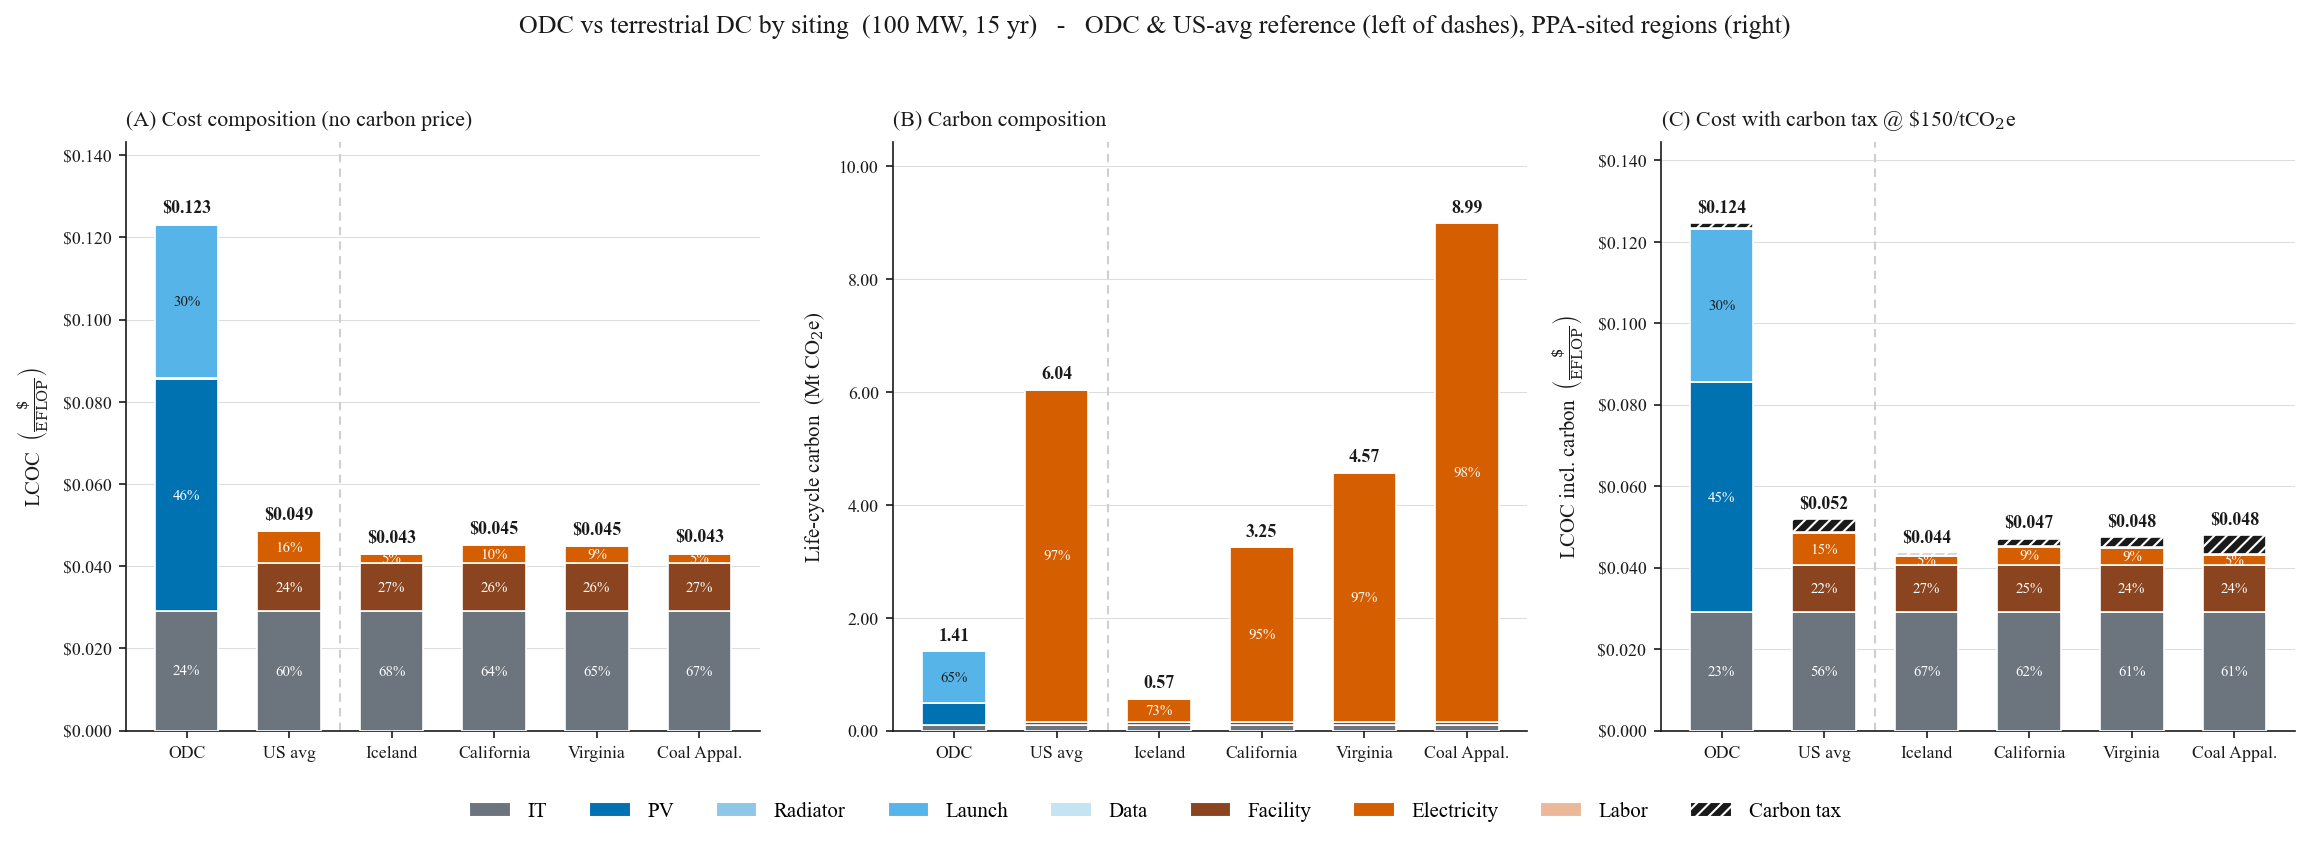

VALIDATION (vs headline numbers)
  ODC cost total       $0.1234/EFLOP   (headline 0.1234)
  TDC cost @ $150       $0.0487/EFLOP   (headline 0.0487)
  ODC/TDC cost ratio    2.53x   (headline 2.53x)
  TDC carbon @ 0.40     6.04 Mt   (headline 6.04)     ODC 1.41 Mt (1.41)
  ODC LCOC @ $150 tax   $0.1245     TDC US-avg @ $150 tax $0.0520

  Per-scenario (cost x / carbon x vs ODC):
    US avg       cost $0.0487 (2.53x)   carbon  6.04 Mt (4.28x)
    Iceland      cost $0.0432 (2.86x)   carbon  0.57 Mt (0.40x)
    California   cost $0.0454 (2.72x)   carbon  3.25 Mt (2.30x)
    Virginia     cost $0.0451 (2.74x)   carbon  4.57 Mt (3.24x)
    Coal Appal.  cost $0.0433 (2.85x)   carbon  8.99 Mt (6.36x)


In [54]:
# =============================================================================
# SITED-SCENARIO COMPOSITION  (paste AFTER cells 14, 18, 32)
# Bar order in every panel: [ ODC | US-avg TDC | sited TDCs... ]
#   (A) LCOC cost composition          $/EFLOP   -- site lever: PPA price
#   (B) Life-cycle carbon composition  Mt CO2e   -- site lever: grid intensity
#   (C) LCOC incl. carbon tax          $/EFLOP   -- (A) + carbon-priced cap
#
# STANDARDIZED TAXONOMY: cost and carbon share one component name per system, so
# panels A/B/C stack segment-for-segment. Components with no modeled value in a
# panel are explicit 0.0 (Data/Labor carbon; not carbon-free, just un-modeled).
#   ODC: IT | PV | Radiator | Launch | Data | Labor
#   TDC: IT | Facility (capex+O&M / shell+MEP) | Electricity (PPA / operational) | Labor
#
# FIXES BAKED IN:
#   - ODC Labor restored (was in build_cash_flows, dropped from the old breakdown).
#   - TDC carbon-tax normalization: divide whole-facility emissions by whole-
#     facility compute (_npc_tdc_total), not per-kW compute x 1000 (was 10x low).
#   - Consistent TDC cost decomposition (shared IT) -> ODC/TDC ratio 2.53x.
#
# Requires (already defined earlier in the notebook):
#   cells 3-14 : BASELINE, mass_budget, annual_eflop, CAPACITY_FACTOR, Q_COMPUTE,
#                LIFETIME_YR, HOURS_PER_YEAR, SECONDS_PER_YEAR, ANNUAL_LABOR_COST,
#                FACILITY_COST_PER_KW, FACILITY_OM_FRAC, IT_REFRESH_YEARS
#   cell 18    : BG, INK, GRID, FONT, ODC_COLOR, TDC_COLOR
#   cell 32    : carbon_scenario, tdc_carbon, odc_carbon_result, replace
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from dataclasses import replace

# --------------------------------------------------------------- knobs --------
CARBON_TAX_USD_PER_T = 150.0     # $/tCO2e used in panel (C); EPA-2023 SCC central ~$190
PUE_TDC              = 1.12
DISCOUNT_CARBON      = True      # discount annual carbon flows before pricing them

# Sited scenarios: (label, grid intensity [tCO2e/MWh], PPA price [$/MWh]).
US_AVG = ('US avg', 0.40, 150)                     # reference TDC (sits 2nd)
SITES  = [
    ('Iceland',      0.028, 43),   # clean + cheap
    ('California',   0.210, 85),   # clean-ish + expensive
    ('Virginia',     0.300, 80),   # "Data Center Alley"
    ('Coal Appal.',  0.600, 45),   # dirty + cheap
]

# ============================================================ cost engine =====
_gamma = BASELINE.gamma_PFLOPS_per_kW
_r     = BASELINE.discount_rate
_disc  = 1.0 / (1 + _r) ** np.arange(LIFETIME_YR)

_npc_odc = (annual_eflop(BASELINE, k_load=CAPACITY_FACTOR) * _disc).sum()   # EFLOP, 100 MW
_npc_tdc = (_gamma * 1.0 * SECONDS_PER_YEAR * _disc).sum()                  # PFLOP, per kW
# whole-facility TDC compute in EFLOP (parallels _npc_odc); used for carbon charge
_npc_tdc_total = _npc_tdc * (Q_COMPUTE / 1e3) / 1e3   # PFLOP/kW x total_kW / 1000

# ========================================================== carbon engine =====
# ODC carbon is site-independent: pull its annual profile + total once.
_odc_prof     = odc_carbon_result['profile']
_odc_annual_t = np.array(_odc_prof['embodied_spike']) + np.array(_odc_prof['launch_spike'])
_odc_total_t  = odc_carbon_result['total']

def _carbon_tax_per_eflop(annual_t, npc, carbon_price):
    """Carbon charge [$/EFLOP]. Discounts annual carbon flows if DISCOUNT_CARBON.
    npc must be the WHOLE-facility compute [EFLOP] matching the extensive emissions."""
    if carbon_price == 0:
        return 0.0
    flows = (annual_t * _disc).sum() if DISCOUNT_CARBON else annual_t.sum()
    return carbon_price * flows / npc

# ================= STANDARDIZED BREAKDOWNS (same names in cost & carbon) =======
def odc_cost_breakdown():
    mb   = mass_budget(BASELINE)
    cPV  = mb['A_PV']  * BASELINE.pv_areal_cost
    cRad = mb['A_rad'] * BASELINE.rad_areal_cost
    cIT  = (Q_COMPUTE / 1e6) * BASELINE.it_cost_per_MW
    lau0 = mb['Total'] * BASELINE.launch_cost_per_kg
    lauR = mb['IT']    * BASELINE.launch_cost_per_kg
    drop = BASELINE.data_fixed_cost + BASELINE.data_mass_per_drop * BASELINE.launch_cost_per_kg
    def cf(y0, rf=0.0):
        a = np.zeros(LIFETIME_YR); a[0] = y0
        for ry in (5, 10): a[ry] += rf
        return a
    return {
        'IT':       (cf(cIT, cIT)  * _disc).sum() / _npc_odc,
        'PV':       (cf(cPV)       * _disc).sum() / _npc_odc,
        'Radiator': (cf(cRad)      * _disc).sum() / _npc_odc,
        'Launch':   (cf(lau0, lauR)* _disc).sum() / _npc_odc,
        'Data':     (np.full(LIFETIME_YR, drop * BASELINE.data_drops_per_year) * _disc).sum() / _npc_odc,
        'Labor':    (np.full(LIFETIME_YR, ANNUAL_LABOR_COST) * _disc).sum() / _npc_odc,  # restored
    }

def tdc_cost_breakdown(p_per_MWh):
    it_per_kW = BASELINE.it_cost_per_MW / 1000.0
    it_cf = np.zeros(LIFETIME_YR)
    for yr in range(0, LIFETIME_YR, IT_REFRESH_YEARS):
        it_cf[yr] += it_per_kW
    elec  = PUE_TDC * (p_per_MWh / 1000) * HOURS_PER_YEAR
    om    = FACILITY_OM_FRAC * FACILITY_COST_PER_KW
    labor = ANNUAL_LABOR_COST / (Q_COMPUTE / 1e3)
    return {
        'IT':          (it_cf * _disc).sum() / _npc_tdc * 1000,
        'Facility':    (FACILITY_COST_PER_KW + (om * _disc).sum()) / _npc_tdc * 1000,  # capex + O&M
        'Electricity': (elec * _disc).sum() / _npc_tdc * 1000,
        'Labor':       (labor * _disc).sum() / _npc_tdc * 1000,
    }

def odc_carbon_breakdown():
    b = odc_carbon_result['breakdown']
    return {
        'IT':       b['IT (all gens)']                / 1e6,
        'PV':       b['PV array']                     / 1e6,
        'Radiator': b['Radiator']                     / 1e6,
        'Launch':   odc_carbon_result['launch_total'] / 1e6,
        'Data':     0.0,   # not modeled
        'Labor':    0.0,   # not modeled
    }

def tdc_carbon_breakdown(grid_intensity):
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=grid_intensity))
    parts = {
        'IT':          tc['breakdown']['IT (all gens)']                          / 1e6,
        'Facility':    (tc['breakdown']['Core & shell'] + tc['breakdown']['MEP']) / 1e6,  # shell + MEP
        'Electricity': tc['operational_total']                                   / 1e6,    # was 'Operational'
        'Labor':       0.0,   # not modeled
    }
    return parts, tc

# ===================================================== parametric LCOC (heatmap)
def odc_lcoc_full(carbon_price=0.0):
    """Total ODC LCOC [$/EFLOP] incl. carbon charge. Site-independent."""
    base = sum(odc_cost_breakdown().values())
    return base + _carbon_tax_per_eflop(_odc_annual_t, _npc_odc, carbon_price)

def tdc_lcoc_full(p_per_MWh, grid_intensity, carbon_price=0.0):
    """Total TDC LCOC [$/EFLOP] incl. carbon charge (fixed whole-facility denom)."""
    base = sum(tdc_cost_breakdown(p_per_MWh).values())
    tc = tdc_carbon(replace(carbon_scenario, grid_intensity=grid_intensity))
    annual = np.array(tc['profile']['embodied_spike']) + np.array(tc['profile']['operational'])
    return base + _carbon_tax_per_eflop(annual, _npc_tdc_total, carbon_price)

# ================================================================ colors =======
SEG_COLOR = {
    'IT':          '#6C757D',   # shared across ODC & TDC
    'PV':          '#0072B2',   # ODC
    'Launch':      '#56B4E9',   # ODC
    'Radiator':    '#8FC7E8',   # ODC
    'Data':        '#C4E3F3',   # ODC (cost only)
    'Facility':    '#8A4520',   # TDC (capex+O&M / shell+MEP)
    'Electricity': '#D55E00',   # TDC, cost AND carbon (site lever)
    'Labor':       '#EBB999',   # shared (cost only)
    'Carbon tax':  '#1a1a1a',   # panel C cap
}
_ACCENT = {'Electricity'}       # always label this segment

def _ink_on(hexcol):
    r, g, b = mcolors.to_rgb(hexcol)
    return INK if (0.299 * r + 0.587 * g + 0.114 * b) > 0.6 else 'white'

def _draw_bars(ax, entities, ylabel, title, yfmt, label_thresh=0.06):
    totals = [sum(v for _, v in segs) for _, segs in entities]
    ymax   = max(totals) * 1.16
    xs     = np.arange(len(entities))
    seen   = {}
    for x, (_, segs) in zip(xs, entities):
        bottom, tot = 0.0, sum(v for _, v in segs)
        for seg, val in segs:
            col   = SEG_COLOR[seg]
            hatch = '////' if seg == 'Carbon tax' else None
            ax.bar(x, val, bottom=bottom, width=0.62, color=col, edgecolor=BG,
                   linewidth=0.8, zorder=3, hatch=hatch)
            seen.setdefault(seg, col)
            if val > 0 and (val >= label_thresh * ymax or seg in _ACCENT):
                ax.text(x, bottom + val / 2, f'{val / tot * 100:.0f}%', ha='center',
                        va='center', fontsize=7.2, color=_ink_on(col), fontfamily=FONT, zorder=4)
            bottom += val
        ax.text(x, bottom + ymax * 0.012, yfmt(bottom), ha='center', va='bottom',
                fontsize=8.6, color=INK, fontfamily=FONT, fontweight='bold', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels([e[0] for e in entities], fontsize=8.5, fontfamily=FONT, color=INK)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_facecolor(BG)
    for s in ('top', 'right'):  ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(INK); ax.spines[s].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=8.5, width=0.8)
    ax.axvline(1.5, color=GRID, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.set_title(title, fontsize=10.5, color=INK, fontfamily=FONT, loc='left', pad=8)
    return seen

def _legend(fig, seen_maps, ncol):
    order = ['IT', 'PV', 'Radiator', 'Launch', 'Data', 'Facility', 'Electricity', 'Labor', 'Carbon tax']
    seen = {}
    for m in seen_maps: seen.update(m)
    handles = [mpatches.Patch(facecolor=seen[k], edgecolor='white', label=k,
                              hatch='////' if k == 'Carbon tax' else None)
               for k in order if k in seen]
    fig.legend(handles=handles, loc='lower center', ncol=ncol, frameon=False,
               fontsize=8, bbox_to_anchor=(0.5, -0.02), prop={'family': FONT})

# ------------------------------------------------------ assemble the entities --
def _cost_entity(label, p): return (label, list(tdc_cost_breakdown(p).items()))
def _carb_entity(label, g): return (label, list(tdc_carbon_breakdown(g)[0].items()))

odc_c = list(odc_cost_breakdown().items())
odc_k = list(odc_carbon_breakdown().items())

costA = [('ODC', odc_c), _cost_entity(*US_AVG[::2])] + [_cost_entity(l, p) for l, g, p in SITES]
carbB = [('ODC', odc_k), _carb_entity(US_AVG[0], US_AVG[1])] + [_carb_entity(l, g) for l, g, p in SITES]

def _tax_cap_tdc(p, g): return tdc_lcoc_full(p, g, CARBON_TAX_USD_PER_T) - sum(tdc_cost_breakdown(p).values())
_tax_cap_odc = odc_lcoc_full(CARBON_TAX_USD_PER_T) - sum(odc_cost_breakdown().values())

costC = [('ODC', odc_c + [('Carbon tax', _tax_cap_odc)]),
         ('US avg', list(tdc_cost_breakdown(US_AVG[2]).items()) + [('Carbon tax', _tax_cap_tdc(US_AVG[2], US_AVG[1]))])] + \
        [(l, list(tdc_cost_breakdown(p).items()) + [('Carbon tax', _tax_cap_tdc(p, g))]) for l, g, p in SITES]

_dollar = lambda v: f'${v:.3f}' if v < 1 else f'${v:,.0f}'
_mt     = lambda v: f'{v:.2f}'

fig, axes = plt.subplots(1, 3, figsize=(15.5, 5.4))
fig.patch.set_facecolor(BG)
s1 = _draw_bars(axes[0], costA, r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
                '(A) Cost composition (no carbon price)', _dollar)
s2 = _draw_bars(axes[1], carbB, r'Life-cycle carbon  (Mt CO$_2$e)',
                '(B) Carbon composition', _mt)
s3 = _draw_bars(axes[2], costC, r'LCOC incl. carbon  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
                rf'(C) Cost with carbon tax @ \${CARBON_TAX_USD_PER_T:.0f}/tCO$_2$e', _dollar)
_legend(fig, [s1, s2, s3], ncol=9)
fig.suptitle('ODC vs terrestrial DC by siting  (100 MW, 15 yr)   -   '
             'ODC & US-avg reference (left of dashes), PPA-sited regions (right)',
             fontsize=12.5, color=INK, fontfamily=FONT, y=1.00)
fig.tight_layout(rect=[0, 0.05, 1, 0.97])
# fig.savefig('sited_composition.pdf', bbox_inches='tight')
# fig.savefig('sited_composition.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------- validation -----
print("VALIDATION (vs headline numbers)")
print(f"  ODC cost total       ${sum(odc_cost_breakdown().values()):.4f}/EFLOP   (headline 0.1234)")
print(f"  TDC cost @ $150       ${sum(tdc_cost_breakdown(150).values()):.4f}/EFLOP   (headline 0.0487)")
print(f"  ODC/TDC cost ratio    {sum(odc_cost_breakdown().values())/sum(tdc_cost_breakdown(150).values()):.2f}x   (headline 2.53x)")
_bd, _tc = tdc_carbon_breakdown(0.40)
print(f"  TDC carbon @ 0.40     {_tc['total']/1e6:.2f} Mt   (headline 6.04)     ODC {_odc_total_t/1e6:.2f} Mt (1.41)")
print(f"  ODC LCOC @ $150 tax   ${odc_lcoc_full(150):.4f}     TDC US-avg @ $150 tax ${tdc_lcoc_full(150, 0.40, 150):.4f}")
print("\n  Per-scenario (cost x / carbon x vs ODC):")
_oc = sum(odc_cost_breakdown().values()); _ok = _odc_total_t / 1e6
for lab, g, p in [US_AVG] + SITES:
    tc_ = sum(tdc_cost_breakdown(p).values())
    tk_ = tdc_carbon(replace(carbon_scenario, grid_intensity=g))['total'] / 1e6
    print(f"    {lab:<12} cost ${tc_:.4f} ({_oc/tc_:.2f}x)   carbon {tk_:5.2f} Mt ({tk_/_ok:.2f}x)")

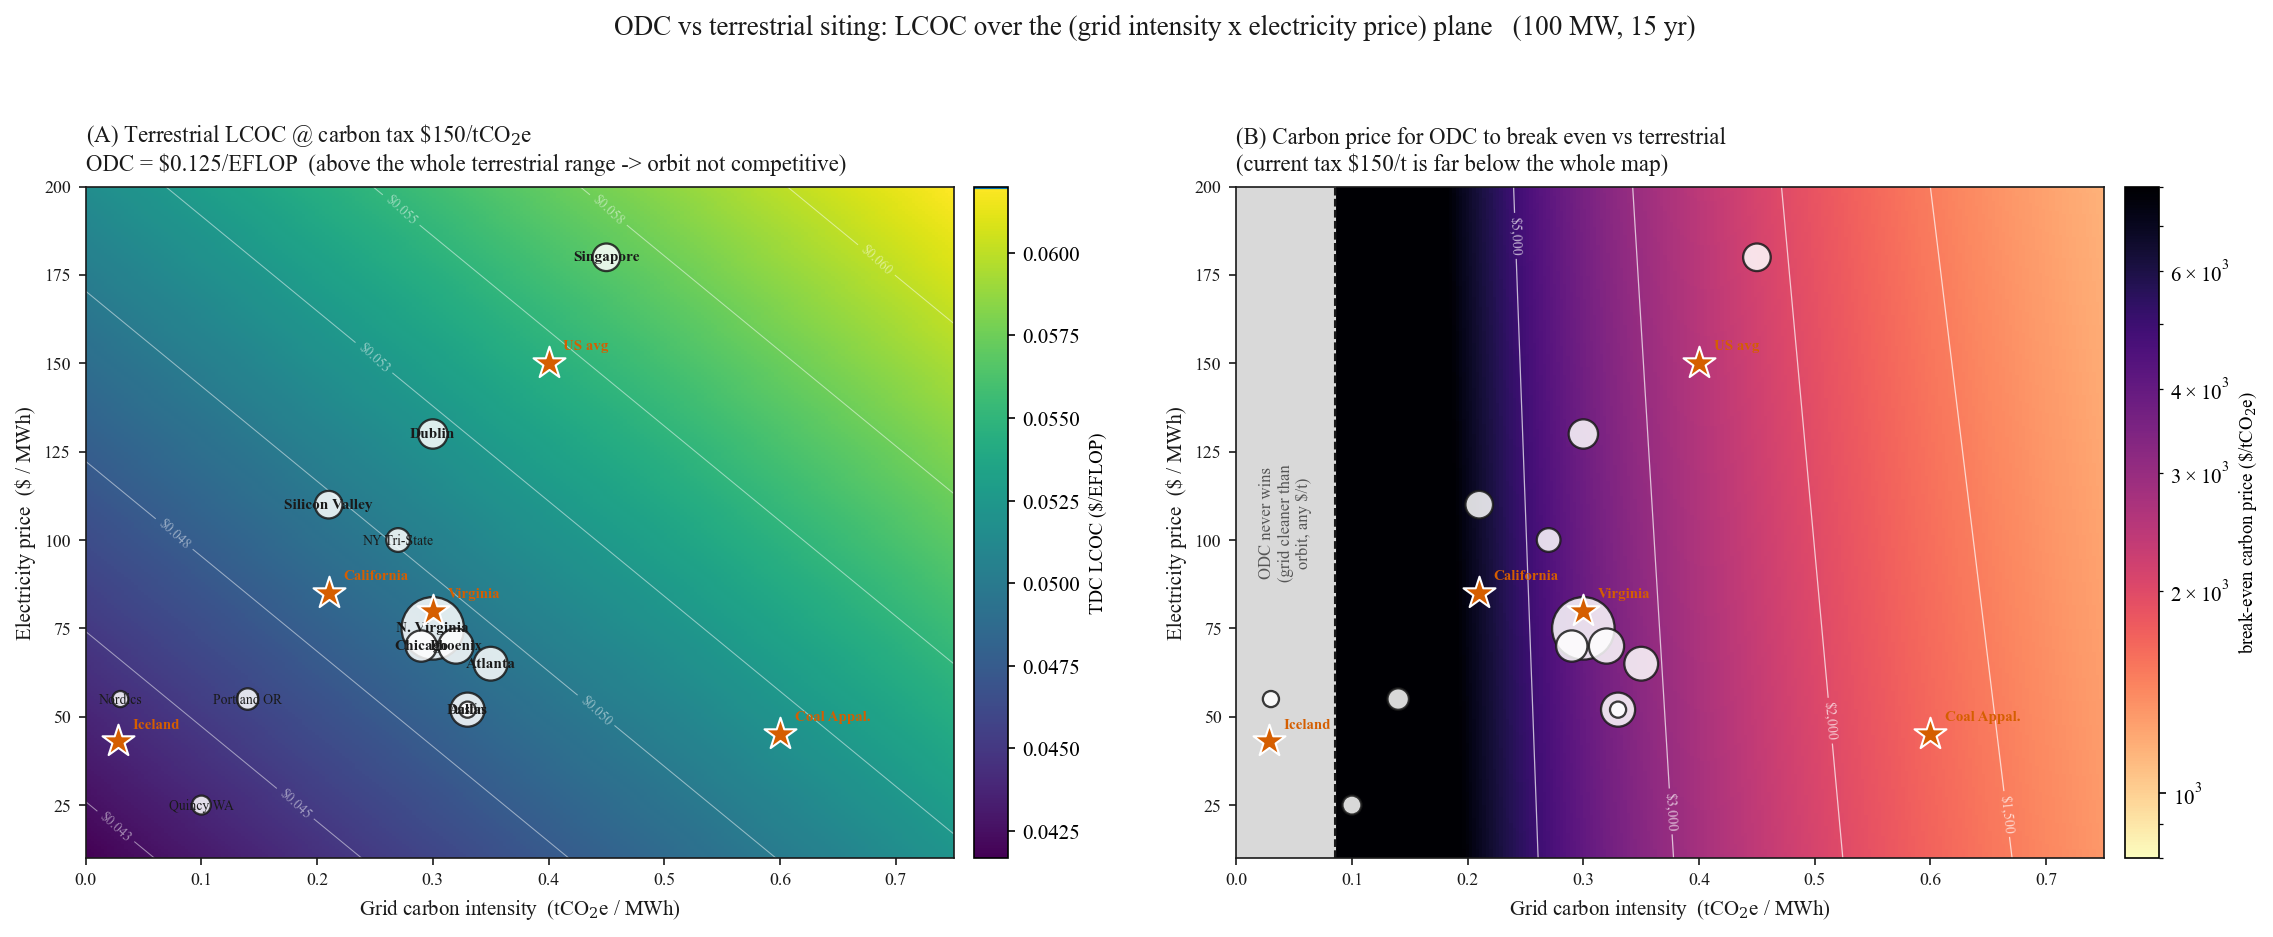

ODC LCOC @ $150/t = $0.1246/EFLOP
TDC LCOC range on map: $0.0417 - $0.0620  (all below ODC)
ODC-equivalent grid threshold: 0.085 tCO2e/MWh
Break-even carbon price at each archetype ($/t):
  Iceland      g=0.028 p=$43   -> ODC never wins
  California   g=0.210 p=$85   -> $6,707/t
  Virginia     g=0.300 p=$80   -> $3,907/t
  US avg       g=0.400 p=$150  -> $2,541/t
  Coal Appal.  g=0.600 p=$45   -> $1,668/t


In [55]:
# =============================================================================
# LCOC HEATMAP  (SELF-CONTAINED -- paste anywhere AFTER cells 14, 18, 32)
# Depends ONLY on base-notebook names (no dependency on the composition cell):
#   cells 3-14 : BASELINE, mass_budget, annual_eflop, CAPACITY_FACTOR, Q_COMPUTE,
#                LIFETIME_YR, HOURS_PER_YEAR, SECONDS_PER_YEAR, ANNUAL_LABOR_COST,
#                FACILITY_COST_PER_KW, FACILITY_OM_FRAC, IT_REFRESH_YEARS
#   cell 18    : BG, INK, FONT, ODC_COLOR, TDC_COLOR
#   cell 32    : carbon_scenario, tdc_carbon, odc_carbon_result
# All internals are prefixed _hm_ to avoid clobbering the composition cell.
#
# Two panels over the (grid intensity x electricity price) plane -- where a
# terrestrial DC is a fixed point; carbon price is held at CARBON_PRICE_FIXED.
#   (A) TDC LCOC @ the fixed carbon price (bubbles = real markets, sized by MW;
#       stars = sited archetypes). ODC is a single scalar, noted vs the scale.
#   (B) ODC break-even carbon price: $/tCO2e at which orbital LCOC = terrestrial
#       LCOC per site. Grey = grid so clean ODC never wins (launch carbon exceeds
#       the terrestrial lifetime total, at any carbon price).
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# ------------------------------------------------------------------ knobs -----
CARBON_PRICE_FIXED = 150.0        # $/tCO2e (matches the composition cell's tax)
_hm_PUE            = 1.12

# real DC markets: (name, capacity MW, grid tCO2e/MWh, power $/MWh)
# Capacity ~2025 inventory (CBRE/JLL). Grid = eGRID subregion / country location-
# based. Price = representative all-in industrial/PPA. Illustrative & editable.
DC_HUBS = [
    ('N. Virginia',    4040, 0.30,  75),
    ('Phoenix',        1380, 0.32,  70),
    ('Dallas',         1300, 0.33,  52),
    ('Atlanta',        1280, 0.35,  65),
    ('Chicago',        1120, 0.29,  70),
    ('Dublin',         1000, 0.30, 130),
    ('Silicon Valley',  900, 0.21, 110),
    ('Singapore',       900, 0.45, 180),
    ('NY Tri-State',    700, 0.27, 100),
    ('Portland OR',     600, 0.14,  55),
    ('Quincy WA',       500, 0.10,  25),
    ('Austin',          400, 0.33,  52),
    ('Nordics',         400, 0.03,  55),
]
# sited archetypes (label, grid tCO2e/MWh, price $/MWh) -- match composition cell
ARCH = [('Iceland', 0.028, 43), ('California', 0.21, 85), ('Virginia', 0.30, 80),
        ('US avg', 0.40, 150), ('Coal Appal.', 0.60, 45)]

# ===================== self-contained LCOC engine (scalars) ==================
_hm_disc = 1.0 / (1 + BASELINE.discount_rate) ** np.arange(LIFETIME_YR)
_hm_npc  = (annual_eflop(BASELINE, k_load=CAPACITY_FACTOR) * _hm_disc).sum()   # EFLOP, 100 MW
_hm_cap  = Q_COMPUTE / 1e6                                                     # 100 MW
def _hm_npv(stream): return (np.asarray(stream) * _hm_disc).sum()

# ODC cost total ($/EFLOP)
def _hm_odc_cost_total():
    mb   = mass_budget(BASELINE)
    cIT  = _hm_cap * BASELINE.it_cost_per_MW
    it   = np.zeros(LIFETIME_YR); it[0] = cIT
    for ry in (5, 10): it[ry] += cIT
    pv   = np.zeros(LIFETIME_YR); pv[0]  = mb['A_PV']  * BASELINE.pv_areal_cost
    rad  = np.zeros(LIFETIME_YR); rad[0] = mb['A_rad'] * BASELINE.rad_areal_cost
    lau  = np.zeros(LIFETIME_YR); lau[0] = mb['Total'] * BASELINE.launch_cost_per_kg
    for ry in (5, 10): lau[ry] += mb['IT'] * BASELINE.launch_cost_per_kg
    drop = BASELINE.data_fixed_cost + BASELINE.data_mass_per_drop * BASELINE.launch_cost_per_kg
    dat  = np.full(LIFETIME_YR, drop * BASELINE.data_drops_per_year)
    return (_hm_npv(it) + _hm_npv(pv) + _hm_npv(rad) + _hm_npv(lau) + _hm_npv(dat)) / _hm_npc

# TDC cost = fixed + costE * price  ($/EFLOP)
def _hm_tdc_cost_fixed_and_slope():
    it = np.zeros(LIFETIME_YR)
    for yr in range(0, LIFETIME_YR, IT_REFRESH_YEARS): it[yr] += BASELINE.it_cost_per_MW * _hm_cap
    fac = np.zeros(LIFETIME_YR); fac[0] = FACILITY_COST_PER_KW * _hm_cap * 1e3
    om  = np.full(LIFETIME_YR, FACILITY_OM_FRAC * FACILITY_COST_PER_KW * _hm_cap * 1e3)
    lab = np.full(LIFETIME_YR, ANNUAL_LABOR_COST)
    fixed = (_hm_npv(it) + _hm_npv(fac) + _hm_npv(om) + _hm_npv(lab)) / _hm_npc
    slope = (_hm_cap * _hm_PUE * HOURS_PER_YEAR * _hm_disc.sum()) / _hm_npc   # $/EFLOP per $/MWh
    return fixed, slope

_hm_odc_cost = _hm_odc_cost_total()
_hm_tdc_fixed, _hm_tdc_slope = _hm_tdc_cost_fixed_and_slope()

# carbon totals (tCO2e): embodied fixed (from model, once); operational linear in grid
_hm_odc_total_t = float(odc_carbon_result['total'])
_hm_tdc_emb_t   = float(tdc_carbon(carbon_scenario)['embodied_total'])
_hm_annual_mwh  = carbon_scenario.it_capacity_mw * carbon_scenario.pue * carbon_scenario.load_factor * 8760.0
_hm_Kop         = _hm_annual_mwh * carbon_scenario.mission_years

def hm_tdc_cost(p):    return _hm_tdc_fixed + _hm_tdc_slope * p
def hm_tdc_carbon(g):  return _hm_tdc_emb_t + _hm_Kop * g
def hm_tdc_lcoc(p, g, cp): return hm_tdc_cost(p) + hm_tdc_carbon(g) * cp / _hm_npc
def hm_odc_lcoc(cp):   return _hm_odc_cost + _hm_odc_total_t * cp / _hm_npc
def hm_breakeven_cp(p, g):
    denom = (hm_tdc_carbon(g) - _hm_odc_total_t) / _hm_npc
    good  = denom > 0
    return np.where(good, (_hm_odc_cost - hm_tdc_cost(p)) / np.where(good, denom, np.nan), np.nan)

# --------------------------------- grids -------------------------------------
_G = np.linspace(0.0, 0.75, 260)
_P = np.linspace(10.0, 200.0, 260)
GG, PP = np.meshgrid(_G, _P)
LCOC = hm_tdc_lcoc(PP, GG, CARBON_PRICE_FIXED)
ODC  = hm_odc_lcoc(CARBON_PRICE_FIXED)
BE   = hm_breakeven_cp(PP, GG)
_g_equiv = (_hm_odc_total_t - _hm_tdc_emb_t) / _hm_Kop     # grid below which ODC never wins

# ------------------------------- overlays ------------------------------------
_cap_arr = np.array([h[1] for h in DC_HUBS], float)
_sizes   = 60 + (_cap_arr - _cap_arr.min()) / (_cap_arr.max() - _cap_arr.min()) * (900 - 60)

def _overlay(ax, label_hubs=True):
    ax.scatter([h[2] for h in DC_HUBS], [h[3] for h in DC_HUBS], s=_sizes,
               facecolor='white', edgecolor=INK, linewidth=1.1, alpha=0.85, zorder=6)
    if label_hubs:
        for name, mw, g, p in DC_HUBS:
            big = mw >= 900
            ax.annotate(name, (g, p), fontsize=7.4 if big else 6.6,
                        fontweight='bold' if big else 'normal', color=INK, fontfamily=FONT,
                        ha='center', va='center', zorder=7)
    for name, g, p in ARCH:
        ax.scatter([g], [p], marker='*', s=260, facecolor=TDC_COLOR, edgecolor='white',
                   linewidth=1.0, zorder=8)
        ax.annotate(name, (g, p), fontsize=7.2, color=TDC_COLOR, fontweight='bold',
                    fontfamily=FONT, ha='left', va='bottom', xytext=(7, 5),
                    textcoords='offset points', zorder=8)

def _style(ax, title):
    ax.set_xlabel(r'Grid carbon intensity  (tCO$_2$e / MWh)', fontsize=10, color=INK, fontfamily=FONT)
    ax.set_ylabel(r'Electricity price  (\$ / MWh)', fontsize=10, color=INK, fontfamily=FONT)
    ax.set_title(title, fontsize=11, color=INK, fontfamily=FONT, loc='left', pad=8)
    ax.tick_params(colors=INK, labelsize=8.5); ax.set_xlim(0, 0.75); ax.set_ylim(10, 200)
    for s in ax.spines.values(): s.set_color(INK); s.set_linewidth(0.8)

# ================================ figure =====================================
fig, (axA, axB) = plt.subplots(1, 2, figsize=(15.5, 6.2)); fig.patch.set_facecolor(BG)

imA = axA.pcolormesh(GG, PP, LCOC, cmap='viridis', shading='auto')
csA = axA.contour(GG, PP, LCOC, levels=8, colors='white', linewidths=0.5, alpha=0.5)
axA.clabel(csA, fmt=lambda v: f'${v:.3f}', fontsize=6.5, inline=True)
_overlay(axA)
cbA = fig.colorbar(imA, ax=axA, pad=0.02); cbA.set_label(r'TDC LCOC (\$/EFLOP)', fontsize=9, fontfamily=FONT)
cbA.ax.axhline(min(ODC, LCOC.max()), color=ODC_COLOR, lw=2)
_style(axA, f'(A) Terrestrial LCOC @ carbon tax \\${CARBON_PRICE_FIXED:.0f}/tCO$_2$e\n'
            f'ODC = \\${ODC:.3f}/EFLOP  (above the whole terrestrial range -> orbit not competitive)')

BEm = np.ma.masked_invalid(BE)
imB = axB.pcolormesh(GG, PP, BEm, cmap='magma_r', norm=LogNorm(vmin=800, vmax=8000), shading='auto')
csB = axB.contour(GG, PP, BEm, levels=[1000, 1500, 2000, 3000, 5000], colors='white',
                  linewidths=0.6, alpha=0.7)
axB.clabel(csB, fmt=lambda v: f'${v:,.0f}', fontsize=6.8, inline=True)
axB.axvspan(0, _g_equiv, color='#D9D9D9', zorder=2)
axB.text(_g_equiv/2, 105, 'ODC never wins\n(grid cleaner than\norbit, any $/t)', ha='center',
         va='center', fontsize=8, color='#555', fontfamily=FONT, zorder=3, rotation=90)
axB.axvline(_g_equiv, color=INK, ls='--', lw=1.0, zorder=3)
_overlay(axB, label_hubs=False)
cbB = fig.colorbar(imB, ax=axB, pad=0.02)
cbB.set_label(r'break-even carbon price (\$/tCO$_2$e)', fontsize=9, fontfamily=FONT)
_style(axB, f'(B) Carbon price for ODC to break even vs terrestrial\n'
            f'(current tax \\${CARBON_PRICE_FIXED:.0f}/t is far below the whole map)')

fig.suptitle('ODC vs terrestrial siting: LCOC over the (grid intensity x electricity price) plane   '
             '(100 MW, 15 yr)', fontsize=13, color=INK, fontfamily=FONT, y=1.00)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig('lcoc_heatmap.pdf', bbox_inches='tight'); fig.savefig('lcoc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------------------------------- numbers ----------------------------------
print(f"ODC LCOC @ ${CARBON_PRICE_FIXED:.0f}/t = ${ODC:.4f}/EFLOP")
print(f"TDC LCOC range on map: ${LCOC.min():.4f} - ${LCOC.max():.4f}  (all below ODC)")
print(f"ODC-equivalent grid threshold: {_g_equiv:.3f} tCO2e/MWh")
print("Break-even carbon price at each archetype ($/t):")
for name, g, p in ARCH:
    be = hm_breakeven_cp(np.array(p, float), np.array(g, float))
    print(f"  {name:<12} g={g:.3f} p=${p:<4} -> " + ("ODC never wins" if np.isnan(be) else f"${float(be):,.0f}/t"))

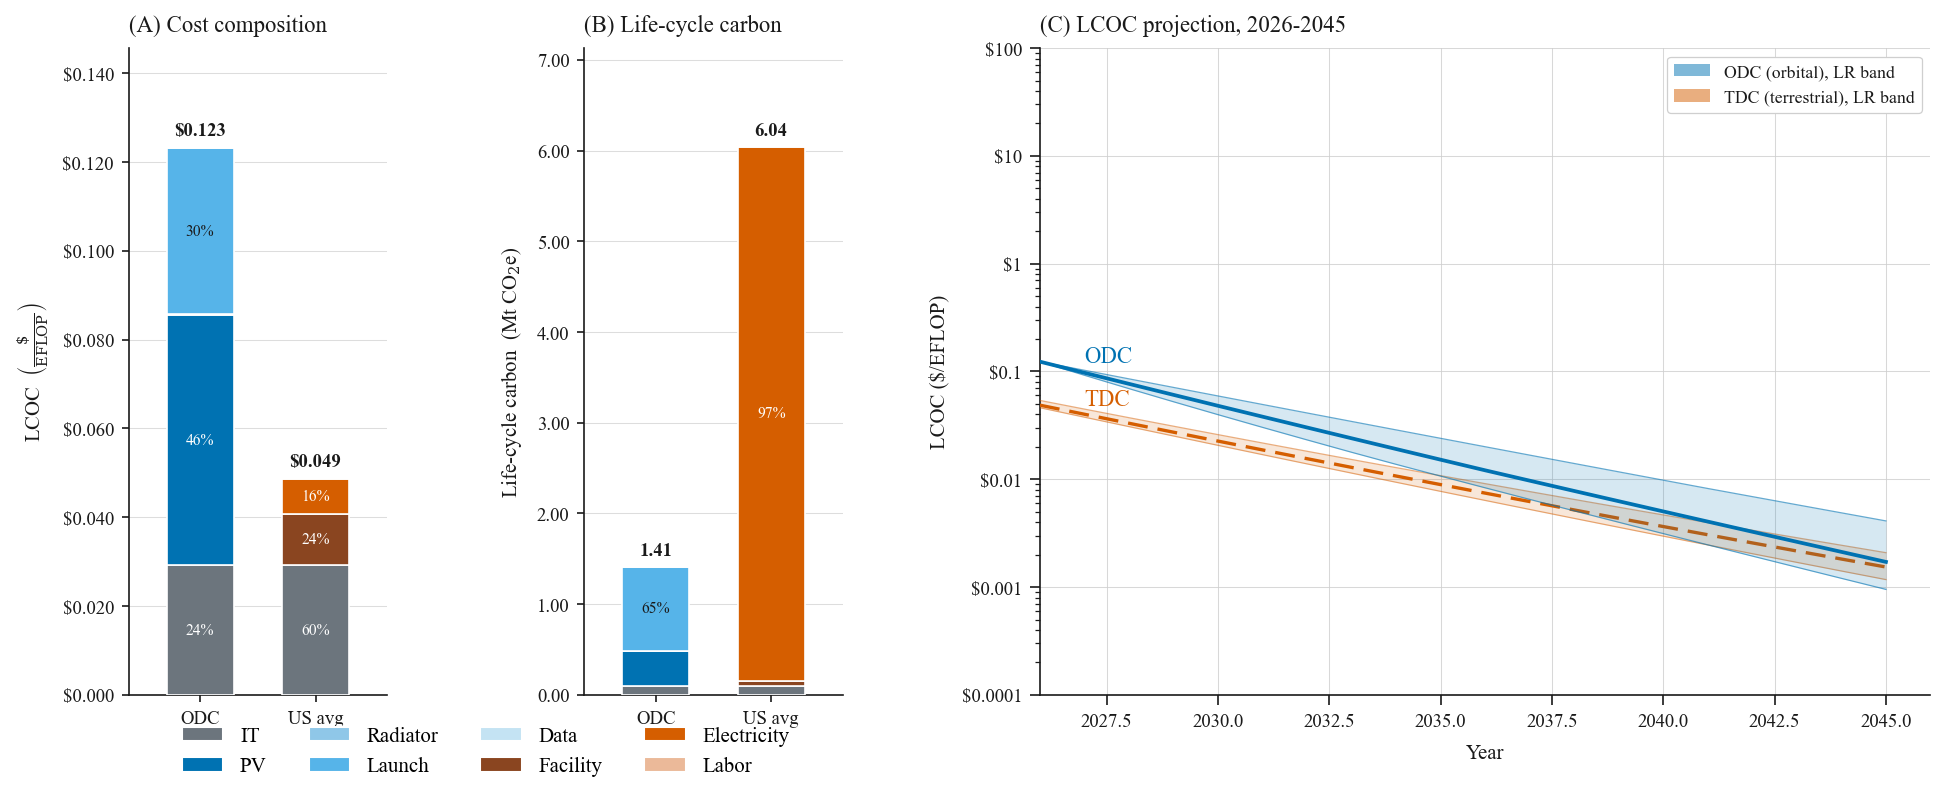

In [56]:
# =============================================================================
# COMBINED PAPER FIGURE  (paste AFTER the projection cell AND the standardized
# composition cell)
#   (A) Cost composition       ODC | US-avg TDC        $/EFLOP   [no siting]
#   (B) Life-cycle carbon      ODC | US-avg TDC        Mt CO2e   [no siting]
#   (C) LCOC projection 2026-2045, learning-rate bands
# Left block = capital + carbon breakdown (baseline US-avg TDC only, no carbon
# price). Right = the time trajectory. Component names reuse the standardized
# taxonomy (IT | PV | Radiator | Launch | Data | Facility | Electricity | Labor).
#
# Requires: odc_cost_breakdown / tdc_cost_breakdown / odc_carbon_breakdown /
#           tdc_carbon_breakdown / SEG_COLOR / _ink_on / _ACCENT / US_AVG   (composition cell)
#           years_calendar / odc_nom,odc_hi,odc_lo / tdc_nom,tdc_hi,tdc_lo    (projection cell)
#           BG / INK / GRID / FONT / ODC_COLOR / TDC_COLOR / style_axes        (styling cell)
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter

_dollar = lambda v: f'${v:.3f}' if v < 1 else f'${v:,.0f}'
_mt     = lambda v: f'{v:.2f}'

# ----- baseline entities: ODC and US-avg TDC only (US_AVG = (label, grid, PPA))
cost_ent = [('ODC',    list(odc_cost_breakdown().items())),
            ('US avg', list(tdc_cost_breakdown(US_AVG[2]).items()))]
carb_ent = [('ODC',    list(odc_carbon_breakdown().items())),
            ('US avg', list(tdc_carbon_breakdown(US_AVG[1])[0].items()))]

def _stack(ax, entities, ylabel, title, yfmt, label_thresh=0.055):
    totals = [sum(v for _, v in segs) for _, segs in entities]
    ymax   = max(totals) * 1.18
    xs     = np.arange(len(entities))
    seen   = {}
    for x, (name, segs) in zip(xs, entities):
        bottom, tot = 0.0, sum(v for _, v in segs)
        for seg, val in segs:
            col = SEG_COLOR[seg]
            ax.bar(x, val, bottom=bottom, width=0.58, color=col, edgecolor=BG,
                   linewidth=0.8, zorder=3)
            seen.setdefault(seg, col)
            if val > 0 and (val >= label_thresh * ymax or seg in _ACCENT):
                ax.text(x, bottom + val / 2, f'{val / tot * 100:.0f}%', ha='center',
                        va='center', fontsize=7.5, color=_ink_on(col), fontfamily=FONT, zorder=4)
            bottom += val
        ax.text(x, bottom + ymax * 0.012, yfmt(bottom), ha='center', va='bottom',
                fontsize=9, color=INK, fontfamily=FONT, fontweight='bold', zorder=5)
    ax.set_xticks(xs)
    ax.set_xticklabels([e[0] for e in entities], fontsize=9.5, fontfamily=FONT, color=INK)
    ax.set_xlim(-0.62, len(entities) - 0.38)
    ax.set_ylim(0, ymax)
    ax.set_ylabel(ylabel, fontsize=10, color=INK, fontfamily=FONT, labelpad=6)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: yfmt(v)))
    ax.set_facecolor(BG)
    for s in ('top', 'right'):  ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'): ax.spines[s].set_color(INK); ax.spines[s].set_linewidth(0.8)
    ax.grid(axis='y', color=GRID, alpha=0.7, linewidth=0.5); ax.set_axisbelow(True)
    ax.tick_params(colors=INK, labelsize=9, width=0.8)
    ax.set_title(title, fontsize=11, color=INK, fontfamily=FONT, loc='left', pad=8)
    return seen

# ============================================================ layout ==========
fig = plt.figure(figsize=(15.5, 5.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[0.9, 0.9, 3.1], wspace=0.42)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[0, 2])

sA = _stack(axA, cost_ent, r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
            '(A) Cost composition', _dollar)
sB = _stack(axB, carb_ent, r'Life-cycle carbon  (Mt CO$_2$e)',
            '(B) Life-cycle carbon', _mt)

# ---------------------------------------------------- (C) projection ----------
axC.fill_between(years_calendar, tdc_lo, tdc_hi, color=TDC_COLOR, alpha=0.15, zorder=2, linewidth=0)
axC.plot(years_calendar, tdc_hi, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
axC.plot(years_calendar, tdc_lo, color=TDC_COLOR, linewidth=0.6, alpha=0.5, zorder=3)
axC.plot(years_calendar, tdc_nom, color=TDC_COLOR, linewidth=1.6, linestyle=(0, (6, 3)), zorder=4)
axC.fill_between(years_calendar, odc_lo, odc_hi, color=ODC_COLOR, alpha=0.16, zorder=5, linewidth=0)
axC.plot(years_calendar, odc_hi, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
axC.plot(years_calendar, odc_lo, color=ODC_COLOR, linewidth=0.6, alpha=0.6, zorder=6)
axC.plot(years_calendar, odc_nom, color=ODC_COLOR, linewidth=1.8, zorder=7)
axC.text(2027, odc_nom[0] * 1.12, 'ODC', color=ODC_COLOR, fontfamily=FONT, fontsize=11, va='center')
axC.text(2027, tdc_nom[0] * 1.12, 'TDC', color=TDC_COLOR, fontfamily=FONT, fontsize=11, va='center')
proj_handles = [
    mpatches.Patch(facecolor=ODC_COLOR, alpha=0.5, label='ODC (orbital), LR band'),
    mpatches.Patch(facecolor=TDC_COLOR, alpha=0.5, label='TDC (terrestrial), LR band'),
]
legC = axC.legend(handles=proj_handles, loc='upper right', frameon=True, framealpha=1.0,
                  edgecolor=GRID, facecolor='white', fontsize=8.5, prop={'family': FONT, 'size': 8.5})
legC.get_frame().set_linewidth(0.6)
for t in legC.get_texts(): t.set_color(INK)
style_axes(axC, fig, title='(C) LCOC projection, 2026-2045',
           xlabel='Year', ylabel='LCOC ($/EFLOP)', xlim=(2026, 2046), ylim=(0.0001, 100))

# ------------------------------------------ shared component legend (left) ----
fig.tight_layout(rect=[0, 0.11, 1, 1])
posA = axA.get_position(); posB = axB.get_position()
cx = (posA.x0 + posB.x1) / 2
order = ['IT', 'PV', 'Radiator', 'Launch', 'Data', 'Facility', 'Electricity', 'Labor']
seen  = {**sA, **sB}
comp_handles = [mpatches.Patch(facecolor=seen[k], edgecolor='white', label=k)
                for k in order if k in seen]
fig.legend(handles=comp_handles, loc='upper center', bbox_to_anchor=(cx, 0.095),
           ncol=4, frameon=False, fontsize=8.5, prop={'family': FONT})

# fig.savefig('paper_fig_composition_projection.pdf', bbox_inches='tight')
# fig.savefig('paper_fig_composition_projection.png', dpi=200, bbox_inches='tight')
plt.show()

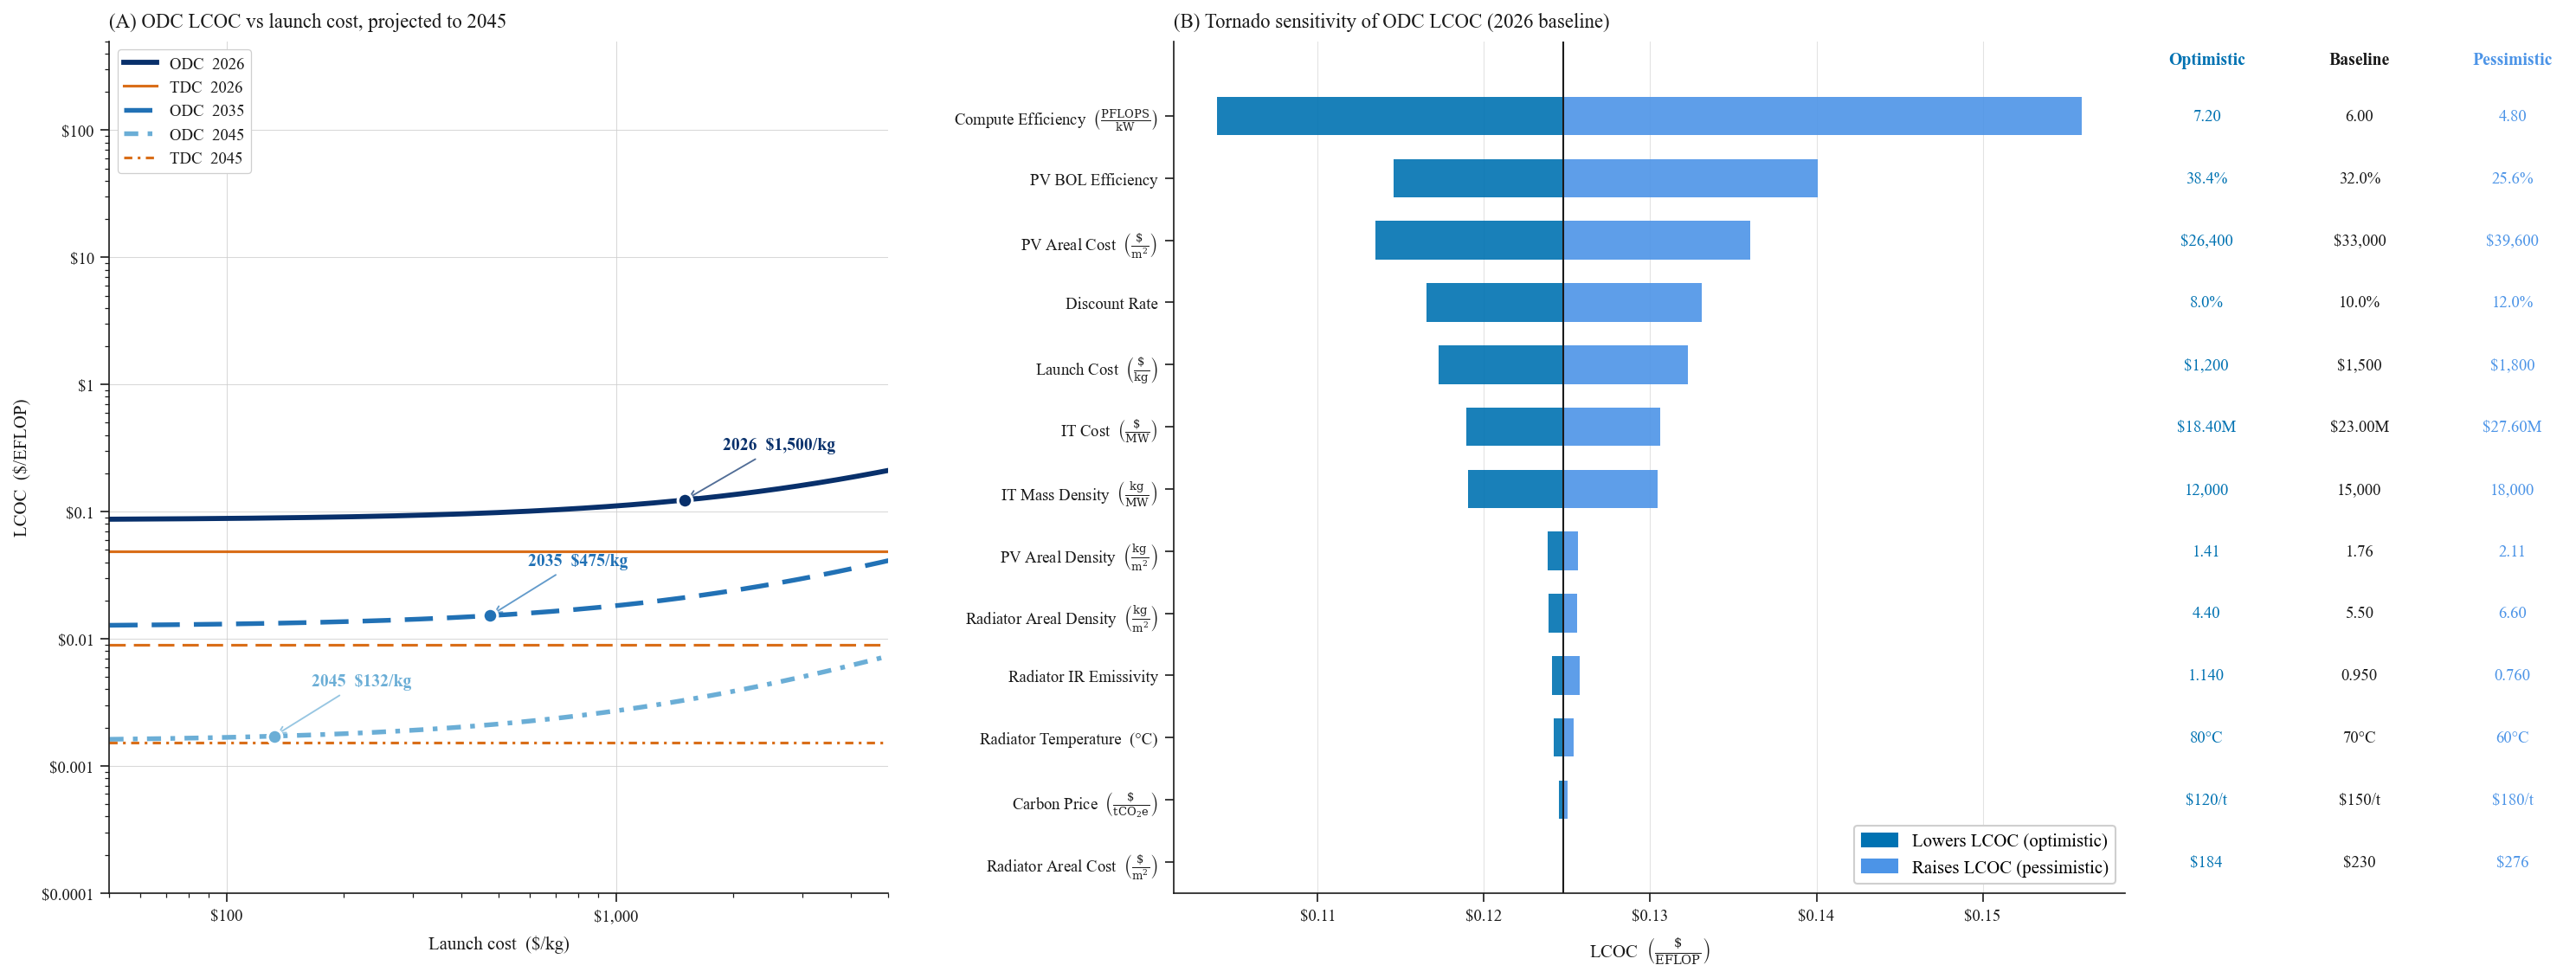

In [57]:
# =============================================================================
# COMBINED PAPER FIGURE 2  (paste AFTER the tornado cell and the projection cell)
#   (A) ODC LCOC vs launch cost, projected to 2045        [left]
#   (B) Tornado sensitivity of ODC LCOC (2026 baseline)   [right, + value table]
# Reuses `bars`, `base_lcoc`, `format_param_value` (tornado cell) and
# evolve_scenario / calculate_lcoc / terrestrial_evolved / LR_BASELINE (projection).
#
# COLOR NOTE: the tornado bars/table do NOT reuse the ODC blue / TDC orange.
# Those identity colors are reserved for the sweep panel; the tornado instead maps
# LCOC DIRECTION -> green (down/favorable) vs purple (up/unfavorable), colorblind-safe.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Tornado direction colors (Okabe-Ito; distinct from ODC blue and TDC vermillion)
LCOC_DOWN = "#0072B2"   # bluish green  : parameter shift LOWERS LCOC (optimistic)
LCOC_UP   = "#4C94E7"   # reddish purple: parameter shift RAISES LCOC (pessimistic)

fig = plt.figure(figsize=(20, 8.2))
fig.patch.set_facecolor(BG)
gsL = fig.add_gridspec(1, 1, left=0.045, right=0.345, top=0.90, bottom=0.10)
gsR = fig.add_gridspec(1, 2, left=0.455, right=0.990, top=0.90, bottom=0.10,
                       width_ratios=[2.35, 1.05], wspace=0.02)
axS    = fig.add_subplot(gsL[0, 0])   # launch-cost sweep
axT    = fig.add_subplot(gsR[0, 0])   # tornado bars
ax_tbl = fig.add_subplot(gsR[0, 1])   # value table

# ------------------------------------------------- (A) launch-cost sweep ------
launch_costs  = np.logspace(np.log10(50), np.log10(5000), 200)
years_to_show = {'2026': 0, '2035': 9, '2045': 19}
yr_colors = {'2026': '#08306b', '2035': '#2171b5', '2045': '#6baed6'}  # ODC blue ramp
yr_styles = {'2026': 'solid', '2035': (0, (6, 3)), '2045': (0, (3, 2, 1, 2))}
yr_lw     = {'2026': 2.8, '2035': 2.6, '2045': 2.6}

for yr_label, yo in years_to_show.items():
    ev_base = evolve_scenario(BASELINE, yo, LR_BASELINE)
    tdc_yr  = terrestrial_evolved(BASELINE.gamma_PFLOPS_per_kW, yo, LR_BASELINE)
    lcocs = np.array([calculate_lcoc(replace(ev_base, launch_cost_per_kg=lc))['lcoc']
                      for lc in launch_costs])
    col, ls, lw = yr_colors[yr_label], yr_styles[yr_label], yr_lw[yr_label]
    axS.plot(launch_costs, lcocs, color=col, linewidth=lw, linestyle=ls,
             label=f'ODC  {yr_label}')
    nom_lc   = BASELINE.launch_cost_per_kg * (1 - LR_BASELINE.launch)**yo
    nom_lcoc = calculate_lcoc(replace(ev_base, launch_cost_per_kg=nom_lc))['lcoc']
    axS.plot(nom_lc, nom_lcoc, 'o', color=col, markersize=8, zorder=10,
             markeredgecolor=BG, markeredgewidth=1.5)
    axS.annotate(f'{yr_label}  ${nom_lc:,.0f}/kg', xy=(nom_lc, nom_lcoc),
                 xytext=(nom_lc * 1.25, nom_lcoc * 2.5), fontsize=9.5, color=col,
                 fontfamily=FONT, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=col, alpha=0.7, lw=0.9))
    axS.axhline(tdc_yr, color=TDC_COLOR, linewidth=1.5, linestyle=ls, alpha=0.9,
                label=f'TDC  {yr_label}' if yr_label in ('2026', '2045') else None)

leg = axS.legend(loc='upper left', frameon=True, framealpha=1.0,
                 edgecolor=GRID, facecolor='white', prop={'family': FONT, 'size': 9})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)
style_axes(axS, fig, title='(A) ODC LCOC vs launch cost, projected to 2045',
           xlabel='Launch cost  ($/kg)', ylabel='LCOC  ($/EFLOP)',
           x_log=True, y_log=True, xlim=(50, 5000), ylim=(0.0001, 500),
           x_dollar=True, y_dollar=True)

# ------------------------------------------------------- (B) tornado ----------
bar_h = 0.62
for i, (label, attr, opt_l, base_l_, pes_l, swing, ov, bv, pv) in enumerate(bars):
    axT.barh(i, opt_l - base_lcoc, left=base_lcoc, height=bar_h, color=LCOC_DOWN, alpha=0.9, zorder=3)
    axT.barh(i, pes_l - base_lcoc, left=base_lcoc, height=bar_h, color=LCOC_UP,   alpha=0.9, zorder=3)
axT.axvline(base_lcoc, color=INK, linewidth=1.0, zorder=5)
style_axes(axT, fig, title='(B) Tornado sensitivity of ODC LCOC (2026 baseline)',
           xlabel=r'LCOC  $\left(\frac{\$}{\mathrm{EFLOP}}\right)$',
           y_log=False, y_dollar=False, x_dollar=True)
axT.set_yticks(range(len(bars)))
axT.set_yticklabels([b[0] for b in bars], fontfamily=FONT, color=INK, fontsize=9)
axT.tick_params(axis='y', pad=4)
axT.grid(axis='y', alpha=0)
axT.grid(axis='x', color=GRID, alpha=0.6, linewidth=0.5)
axT.set_ylim(len(bars) - 0.5, -1.2)
axT.legend(handles=[mpatches.Patch(color=LCOC_DOWN, label='Lowers LCOC (optimistic)'),
                    mpatches.Patch(color=LCOC_UP,   label='Raises LCOC (pessimistic)')],
           loc='lower right', frameon=True, framealpha=1.0, edgecolor=GRID,
           facecolor='white', fontsize=8.5, prop={'family': FONT})

# ------------------------------------------- value table (Opt / Base / Pes) ---
ax_tbl.set_xlim(0, 1)
ax_tbl.set_ylim(len(bars) - 0.5, -1.2)
ax_tbl.axis('off')
col_x = {'opt': 0.16, 'base': 0.52, 'pes': 0.88}
for x, header, ccol in [(col_x['opt'], 'Optimistic',  LCOC_DOWN),
                        (col_x['base'], 'Baseline',   INK),
                        (col_x['pes'], 'Pessimistic', LCOC_UP)]:
    ax_tbl.text(x, -0.9, header, ha='center', va='center', fontsize=9.5,
                color=ccol, fontfamily=FONT, fontweight='bold')
for i, (label, attr, opt_l, base_l_, pes_l, swing, opt_val, base_val, pes_val) in enumerate(bars):
    ax_tbl.text(col_x['opt'],  i, format_param_value(attr, opt_val),
                ha='center', va='center', fontsize=9, color=LCOC_DOWN, fontfamily=FONT)
    ax_tbl.text(col_x['base'], i, format_param_value(attr, base_val),
                ha='center', va='center', fontsize=9, color=INK, fontfamily=FONT)
    ax_tbl.text(col_x['pes'],  i, format_param_value(attr, pes_val),
                ha='center', va='center', fontsize=9, color=LCOC_UP, fontfamily=FONT)

plt.show()

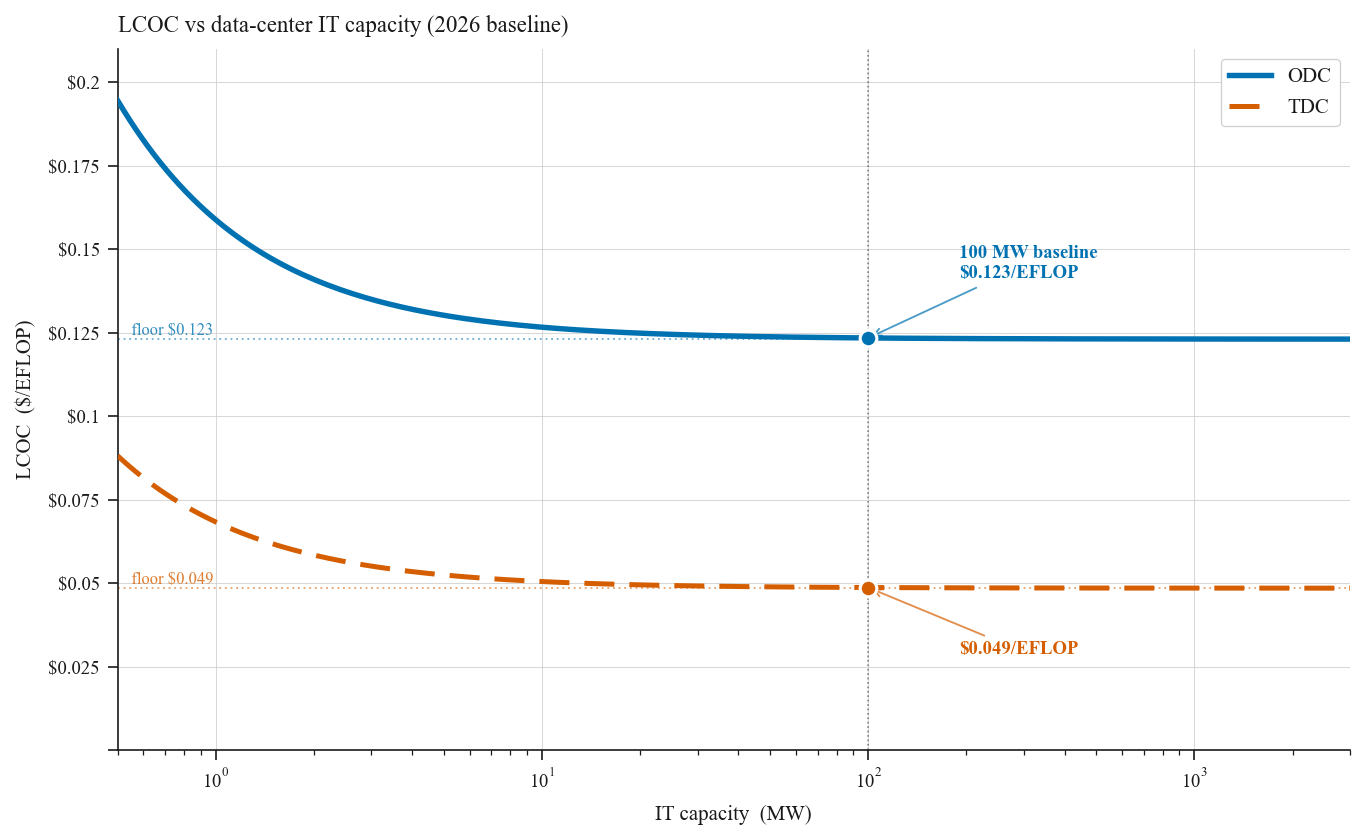

In [58]:
# =============================================================================
# IT-CAPACITY SWEEP  (paste AFTER the model cells 3-5 and the styling cell 7)
# LCOC vs data-center IT capacity at the 2026 baseline, ODC vs TDC.
#
# Mechanism: PV/radiator/IT mass, launch, IT cost and compute output all scale
# linearly with capacity (the ODC radiator geometry stays self-similar, so its
# area is linear too). The ONLY capacity-independent costs are the fixed ground-
# ops labor ($3.75M/yr, both) and the ODC fixed data downlink. LCOC therefore
# falls as those fixed costs spread over more compute, then flattens to a floor.
#
# Q_COMPUTE is a module global read by calculate_lcoc/mass_budget/annual_eflop,
# so we rebind it per capacity and RESTORE it afterwards (try/finally). The TDC
# per-kW model is size-invariant except for fixed labor, which we pass explicitly.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

caps_MW = np.logspace(np.log10(0.5), np.log10(3000), 200)
odc_lcoc, tdc_lcoc = [], []

_Q_COMPUTE_SAVED = Q_COMPUTE
try:
    for C in caps_MW:
        Q_COMPUTE = float(C * 1e6)                                   # rebind global (W)
        odc_lcoc.append(calculate_lcoc(BASELINE)['lcoc'])
        tdc_lcoc.append(terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW,
                                         labor_per_kW_yr=ANNUAL_LABOR_COST / (C * 1000)))
finally:
    Q_COMPUTE = _Q_COMPUTE_SAVED                                     # restore 100 MW
odc_lcoc = np.array(odc_lcoc)
tdc_lcoc = np.array(tdc_lcoc)

# baseline (100 MW) reference points
_Q_COMPUTE_SAVED = Q_COMPUTE
try:
    Q_COMPUTE = 100e6
    odc_100 = calculate_lcoc(BASELINE)['lcoc']
finally:
    Q_COMPUTE = _Q_COMPUTE_SAVED
tdc_100 = terrestrial_lcoc(BASELINE.gamma_PFLOPS_per_kW,
                           labor_per_kW_yr=ANNUAL_LABOR_COST / (100 * 1000))
odc_floor, tdc_floor = odc_lcoc[-1], tdc_lcoc[-1]

# ------------------------------------------------------------- plot -----------
fig, ax = plt.subplots(figsize=(9.2, 5.7))

# large-scale floors (asymptotes)
ax.axhline(odc_floor, color=ODC_COLOR, lw=0.9, ls=(0, (1, 2)), alpha=0.55, zorder=2)
ax.axhline(tdc_floor, color=TDC_COLOR, lw=0.9, ls=(0, (1, 2)), alpha=0.55, zorder=2)
ax.text(0.52, odc_floor, f'  floor ${odc_floor:.3f}', color=ODC_COLOR, fontfamily=FONT,
        fontsize=8, va='bottom', ha='left', alpha=0.8)
ax.text(0.52, tdc_floor, f'  floor ${tdc_floor:.3f}', color=TDC_COLOR, fontfamily=FONT,
        fontsize=8, va='bottom', ha='left', alpha=0.8)

# curves
ax.plot(caps_MW, odc_lcoc, color=ODC_COLOR, lw=2.6, zorder=5, label='ODC')
ax.plot(caps_MW, tdc_lcoc, color=TDC_COLOR, lw=2.4, ls=(0, (6, 3)), zorder=5, label='TDC')

# 100 MW baseline marker
ax.axvline(100, color=INK, lw=0.8, ls=':', alpha=0.5, zorder=1)
ax.plot(100, odc_100, 'o', color=ODC_COLOR, ms=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=7)
ax.plot(100, tdc_100, 'o', color=TDC_COLOR, ms=8, markeredgecolor=BG, markeredgewidth=1.5, zorder=7)
ax.annotate(f'100 MW baseline\n${odc_100:.3f}/EFLOP', xy=(100, odc_100),
            xytext=(190, odc_100 + 0.018), fontsize=9, color=ODC_COLOR, fontfamily=FONT,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color=ODC_COLOR, alpha=0.7, lw=0.9))
ax.annotate(f'${tdc_100:.3f}/EFLOP', xy=(100, tdc_100),
            xytext=(190, tdc_100 - 0.02), fontsize=9, color=TDC_COLOR, fontfamily=FONT,
            fontweight='bold', arrowprops=dict(arrowstyle='->', color=TDC_COLOR, alpha=0.7, lw=0.9))

leg = ax.legend(loc='upper right', frameon=True, framealpha=1.0, edgecolor=GRID,
                facecolor='white', prop={'family': FONT, 'size': 10})
leg.get_frame().set_linewidth(0.6)
for t in leg.get_texts(): t.set_color(INK)

style_axes(ax, fig,
    title='LCOC vs data-center IT capacity (2026 baseline)',
    # subtitle='Economies of scale: fixed ground-ops labor (both) + fixed data downlink (ODC) spread over more compute',
    xlabel='IT capacity  (MW)', ylabel='LCOC  ($/EFLOP)',
    x_log=True, y_log=False, x_dollar=False, y_dollar=True,
    xlim=(0.5, 3000), ylim=(0.0, 0.21))
plt.tight_layout()
plt.show()